## Import packages and setup functions

In [1]:
# Standard libraries
import os
# import asyncio
import pandas as pd
# import random
# import re
from pathlib import Path
from math import isfinite
from itertools import combinations
from collections import defaultdict
from typing import Optional, Sequence, Tuple, Union

# NumPy
import numpy as np
from numpy.linalg import inv, norm

# SciPy
# from scipy.optimize import minimize
# from scipy.optimize import curve_fit
from scipy.signal import find_peaks
# from scipy.fft import fftn, fftshift
from scipy.spatial import cKDTree, distance_matrix
from scipy.spatial.transform import Rotation as R

# Scikit-learn
# from sklearn.decomposition import PCA

# Matplotlib
import matplotlib
matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
# from matplotlib.animation import PillowWriter
# from matplotlib.animation import FuncAnimation
# from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection

# Plotly
import plotly.express as px

# Jupyter widgets and display
import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import Image
from IPython.display import display

# Backend
%matplotlib inline

In [2]:
def _auto_best_origin_id():
    if 'df_ranked' in globals() and isinstance(df_ranked, pd.DataFrame) and not df_ranked.empty and 'origin_id' in df_ranked:
        return int(df_ranked.iloc[0]['origin_id'])
    # fallback: best by RMSE, then by matched %
    cols_needed = {'rmse', 'matched_percent', 'origin_id'}
    missing = [c for c in cols_needed if c not in df_summary.columns]
    if missing:
        raise KeyError(f"df_summary missing columns required for auto-pick: {missing}")
    row = df_summary.sort_values(['rmse', 'matched_percent'], ascending=[True, False]).iloc[0]
    return int(row['origin_id'])


def _fcc_angle_score(vs, cos_target=0.5, sigma_cos=0.15):
    u = [v / (np.linalg.norm(v) + 1e-12) for v in vs]
    c01 = np.dot(u[0], u[1]); c02 = np.dot(u[0], u[2]); c12 = np.dot(u[1], u[2])
    def g(c):  # Gaussian around cos_target
        return np.exp(-0.5 * ((c - cos_target) / sigma_cos)**2)
    return g(c01) * g(c02) * g(c12)


def _is_neighbor_any(k, prev_shell_K, mode):
    """
    k: (3,) int ijk
    prev_shell_K: (m,3) int ijk from previous shell
    mode: 6 or 26
    Returns True if k has at least one neighbor in prev_shell_K according to mode.
    """
    if prev_shell_K.size == 0:
        return False
    diffs = np.abs(prev_shell_K - k)  # (m,3)
    if mode == 6:
        # Face-adjacent: exactly one axis differs by ±1, others equal
        return np.any(diffs.sum(axis=1) == 1)
    elif mode == 26:
        # Any of the 26 around (including diagonals): Chebyshev ≤ 1 and not identical
        return np.any((diffs.max(axis=1) <= 1) & (diffs.sum(axis=1) >= 1))
    else:
        raise ValueError("NEIGHBOR_MODE must be 6 or 26")


def _on_any(event):
    if event.inaxes is ax1:
        _sync_from_to(ax1, ax2)
    elif event.inaxes is ax2:
        _sync_from_to(ax2, ax1)


def _smooth(y, w=7):
    w = max(3, int(w) | 1)
    k = np.ones(w) / w
    return np.convolve(y, k, mode='same')


def _sync_from_to(src, dst):
    dst.view_init(elev=src.elev, azim=src.azim)
    try:
        dst.set_xlim3d(src.get_xlim3d())
        dst.set_ylim3d(src.get_ylim3d())
        dst.set_zlim3d(src.get_zlim3d())
    except Exception:
        pass
    dst.figure.canvas.draw_idle()


def _volume_score(vs, target_volume, sigma_vol):
    V = abs(np.linalg.det(np.vstack(vs)))
    return np.exp(-0.5 * ((V - target_volume) / max(sigma_vol, 1e-12))**2), V


def apply_bounds(ax, bounds):
    (xlim, ylim, zlim) = bounds
    ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_zlim(*zlim)

# takes an origin point + the lattice vectors, then creates an ideal grid of (i, j, k) coordinates, then assigns each point in real data to the nearest lattice point (within a tolerance), returning the assignments and stats
def assign_ijk_for_origin(r_data, origin, fcc_vectors, nn_len, tol_frac=0.25, padding=1, max_k_nn=16, match_len=None):
    """
    Return:
      ijk_assignments (list of dicts),
      df_matches (N rows, distances/sq_error per original point; unmatched rows are NaN),
      summary dict with stats.
    """
    ref_len = float(nn_len) if match_len is None else float(match_len)
    match_tol = tol_frac * ref_len
    B = np.asarray(fcc_vectors, float)   # rows
    BT = B.T
    if np.linalg.det(BT) < 0:
        BT[:,2] *= -1.0

    delta = r_data - origin
    try:
        invBT = np.linalg.inv(BT)
        frac  = delta @ invBT.T
    except np.linalg.LinAlgError:
        invBT = np.linalg.pinv(BT)
        frac  = delta @ invBT.T

    # loop bounds from extents (+ padding)
    i_min = int(np.floor(frac[:,0].min())); i_max = int(np.ceil(frac[:,0].max()))
    j_min = int(np.floor(frac[:,1].min())); j_max = int(np.ceil(frac[:,1].max()))
    k_min = int(np.floor(frac[:,2].min())); k_max = int(np.ceil(frac[:,2].max()))

    i_plus_max_p1  = max(0, i_max) + 1;  i_minus_max_p1 = max(0, -i_min) + 1
    j_plus_max_p1  = max(0, j_max) + 1;  j_minus_max_p1 = max(0, -j_min) + 1
    k_plus_max_p1  = max(0, k_max) + 1;  k_minus_max_p1 = max(0, -k_min) + 1

    i_lo = -(i_minus_max_p1 - 1) - padding;  i_hi = (i_plus_max_p1 - 1) + padding
    j_lo = -(j_minus_max_p1 - 1) - padding;  j_hi = (j_plus_max_p1 - 1) + padding
    k_lo = -(k_minus_max_p1 - 1) - padding;  k_hi = (k_plus_max_p1 - 1) + padding

    tree = cKDTree(r_data)
    def lattice_point(i,j,k):
        return origin + BT @ np.array([i,j,k], float)

    ijk_assignments = []
    unmatched_ijk = []
    used = set()

    # seed at 0,0,0
    p0 = lattice_point(0,0,0)
    d0, idx0 = tree.query(p0, k=1)
    ijk_assignments.append({"ijk": (0,0,0), "lattice_point": p0, "matched_point": r_data[int(idx0)].copy(), "distance": float(d0)})
    used.add(int(idx0))

    for i in range(i_lo, i_hi + 1):
        for j in range(j_lo, j_hi + 1):
            for k in range(k_lo, k_hi + 1):
                if (i,j,k) == (0,0,0): 
                    continue
                p = lattice_point(i,j,k)
                k_nn = min(max_k_nn, len(r_data))
                dists, idxs = tree.query(p, k=k_nn)
                dists = np.atleast_1d(dists); idxs = np.atleast_1d(idxs)

                found = False
                for d, idx in zip(dists, idxs):
                    idx = int(idx)
                    if idx in used: 
                        continue
                    if d <= match_tol:
                        ijk_assignments.append({
                            "ijk": (int(i), int(j), int(k)),
                            "lattice_point": p,
                            "matched_point": r_data[idx].copy(),
                            "distance": float(d),
                        })
                        used.add(idx)
                        found = True
                        break
                if not found:
                    unmatched_ijk.append((int(i), int(j), int(k)))

    # Build df_matches aligned to r_data order
    N = r_data.shape[0]
    ijk_i = np.full(N, np.nan); ijk_j = np.full(N, np.nan); ijk_k = np.full(N, np.nan)
    lat   = np.full((N,3), np.nan); dist = np.full(N, np.nan); sqerr = np.full(N, np.nan)
    DEC = 12
    r_round = np.round(r_data, DEC)
    coord_to_idxs = {}
    for idx, xyz in enumerate(r_round):
        coord_to_idxs.setdefault(tuple(xyz), []).append(idx)

    pairs_filled = 0
    for rec in ijk_assignments:
        mp = np.round(np.asarray(rec["matched_point"], float), DEC)
        key = tuple(mp)
        idx_list = coord_to_idxs.get(key, [])
        if not idx_list:
            continue
        row = idx_list.pop(0)
        lp = np.asarray(rec["lattice_point"], float)
        i,j,k = rec.get("ijk", (np.nan, np.nan, np.nan))
        try:
            ijk_i[row], ijk_j[row], ijk_k[row] = int(i), int(j), int(k)
        except Exception:
            pass
        lat[row] = lp
        d = float(np.linalg.norm(r_data[row] - lp))
        dist[row] = d
        sqerr[row] = d*d
        pairs_filled += 1

    df = pd.DataFrame({
        "r_x": r_data[:,0], "r_y": r_data[:,1], "r_z": r_data[:,2],
        "ijk_i": ijk_i, "ijk_j": ijk_j, "ijk_k": ijk_k,
        "lattice_x": lat[:,0], "lattice_y": lat[:,1], "lattice_z": lat[:,2],
        "distance": dist, "sq_error": sqerr,
    })
    for c in ["ijk_i","ijk_j","ijk_k"]:
        df[c] = pd.Series(df[c], dtype="Int64")

    m = np.isfinite(df["sq_error"].to_numpy())
    mse = float(np.mean(df.loc[m, "sq_error"])) if m.any() else np.nan
    rmse = float(np.sqrt(mse)) if isfinite(mse) else np.nan
    matched_particles = int(np.isfinite(df["distance"]).sum())
    total_particles = int(r_data.shape[0])
    matched_pct = 100.0 * matched_particles / total_particles if total_particles else 0.0
    dvalid = df.loc[np.isfinite(df["distance"]), "distance"].to_numpy()
    stats = {
        "matched_particles": matched_particles,
        "total_particles": total_particles,
        "matched_pct": matched_pct,
        "mse": mse,
        "rmse": rmse,
        "d_min": float(dvalid.min()) if dvalid.size else np.nan,
        "d_med": float(np.median(dvalid)) if dvalid.size else np.nan,
        "d_max": float(dvalid.max()) if dvalid.size else np.nan,
        "match_tol": float(match_tol),
        "i_bounds": (i_lo, i_hi),
        "j_bounds": (j_lo, j_hi),
        "k_bounds": (k_lo, k_hi),
        "pairs_filled": pairs_filled,
    }
    return ijk_assignments, df, stats


def compute_equal_bounds(pts, pad=0.05):
    """Return equal xyz bounds covering pts with optional padding fraction."""
    if pts.size == 0:
        return (-1, 1), (-1, 1), (-1, 1)
    mins = pts.min(axis=0); maxs = pts.max(axis=0)
    spans = np.maximum(maxs - mins, 1e-9)
    rng   = spans.max() * (1 + pad)
    center = (maxs + mins) / 2.0
    half = rng / 2.0
    xlim = (center[0] - half, center[0] + half)
    ylim = (center[1] - half, center[1] + half)
    zlim = (center[2] - half, center[2] + half)
    return xlim, ylim, zlim


def copy_view(src, dst):
    dst.view_init(elev=src.elev, azim=src.azim)
    try: dst._roll = src._roll
    except Exception: pass
    dst.set_xlim3d(src.get_xlim3d())
    dst.set_ylim3d(src.get_ylim3d())
    dst.set_zlim3d(src.get_zlim3d())


def extract_predicted_from_record(rec):
    for key in ('lattice_point','predicted_point'):
        if key in rec and rec[key] is not None:
            p = np.asarray(rec[key], float)
            if p.size == 3 and np.all(np.isfinite(p)):
                return p
    return None


def fit_fcc_vectors_for_origin(seed, r_data, nn_len, crystal_type):
    """
    Given a seed/origin point (3,), find FCC-like primitive vectors using nearby neighbors.
    Returns (3,3) matrix with rows=v1,v2,v3.
    """
    if crystal_type == 'CD':
        target_len = float(nn_len) * (4.0 / np.sqrt(6.0))   # second-nearest shell (12 neighbors)
    else:
        target_len = float(nn_len)

    a = target_len * np.sqrt(2.0)
    sigma_len  = 0.10 * target_len
    target_volume = (a**3) / 4.0
    sigma_vol = 0.20 * target_volume

    D = np.linalg.norm(r_data - seed, axis=1)

    if crystal_type == 'CD':
        keep = D > (0.75 * target_len)
    else:
        keep = np.ones_like(D, dtype=bool)

    w = gaussian_weights(D, target_len, sigma_len) * keep.astype(float)

    # candidate neighbors: within ~3 sigma; top M by weight
    M = 24
    cand_idx = np.where(w > np.exp(-0.5 * (3.0)**2))[0]
    if cand_idx.size == 0:
        # no neighbors close to NN length; fallback early
        U = gram_schmidt_orthonormalize([np.array([1,0,0.1]), np.array([0.1,1,0]), np.array([0,0.1,1])])
        return U * target_len

    order = np.argsort(-w[cand_idx])
    cand_idx = cand_idx[order][:M]
    vecs = r_data[cand_idx] - seed
    weights = w[cand_idx]
    norms = np.linalg.norm(vecs, axis=1)

    best_score = -np.inf
    best_triplet = None

    if len(cand_idx) >= 3:
        for i1, i2, i3 in combinations(range(len(cand_idx)), 3):
            v1, v2, v3 = vecs[i1], vecs[i2], vecs[i3]
            n1, n2, n3 = norms[i1], norms[i2], norms[i3]

            len_pen = (
                np.exp(-0.5 * ((n1 - target_len) / sigma_len) ** 2)
                * np.exp(-0.5 * ((n2 - target_len) / sigma_len) ** 2)
                * np.exp(-0.5 * ((n3 - target_len) / sigma_len) ** 2)
            )
            ang = _fcc_angle_score([v1, v2, v3], cos_target=0.5, sigma_cos=0.15)
            vol_sc, _ = _volume_score([v1, v2, v3], target_volume, sigma_vol)
            w_combo = weights[i1] * weights[i2] * weights[i3]
            score = w_combo * len_pen * ang * vol_sc

            if score > best_score:
                best_score = score
                best_triplet = (v1, v2, v3)

    if best_triplet is None:
        U = gram_schmidt_orthonormalize([np.array([1,0,0.1]), np.array([0.1,1,0]), np.array([0,0.1,1])])
        V = U * target_len
    else:
        V = np.vstack(best_triplet)
        if np.linalg.det(V) < 0:
            V[2] = -V[2]
        # softly rescale lengths to target_len
        for k in range(3):
            nk = np.linalg.norm(V[k]) + 1e-12
            V[k] *= (target_len / nk)
    return V


In [3]:
def gaussian_weights(d, target, sigma):
    w = np.exp(-0.5 * ((d - target) / max(sigma, 1e-12))**2)
    w[~np.isfinite(d)] = 0.0
    return w


def get_r_id_from_record(rec):
    for k in ('particle_id','r_id','r_index','r_idx','original_id','orig_idx','index','id'):
        if k in rec:
            try:
                v = int(rec[k])
                if v >= 0:
                    return v
            except Exception:
                pass
    return None


def gram_schmidt_orthonormalize(vs):
    U = []
    for v in vs:
        w = v.astype(float).copy()
        for u in U:
            w -= np.dot(w, u) * u
        n = np.linalg.norm(w)
        if n < 1e-10:
            continue
        U.append(w / n)
        if len(U) == 3:
            break
    I = np.eye(3)
    k = 0
    while len(U) < 3 and k < 3:
        cand = I[k]
        for u in U:
            cand = cand - np.dot(cand, u) * u
        n = np.linalg.norm(cand)
        if n > 1e-8:
            U.append(cand / n)
        k += 1
    return np.array(U[:3])


def on_draw(_e): copy_view(axL, axR)


def on_mouse(event):
    if event.inaxes is axL:
        copy_view(axL, axR); fig.canvas.draw_idle()
    elif event.inaxes is axR:
        copy_view(axR, axL); fig.canvas.draw_idle()


def recover_indices(coords, origin, lattice_vectors, lattice_spacing=1.0):
    """
    Given matched coordinates and lattice definition, recover integer Δi indices.
    """
    coords = np.asarray(coords, float)
    r0 = np.asarray(origin, float).reshape(1, 3)

    # Build scaled lattice matrix
    E = (lattice_spacing * np.asarray(lattice_vectors, float)).T  # (3,3)
    E_inv = np.linalg.inv(E)

    # Compute fractional indices
    frac = (coords - r0) @ E_inv.T   # shape (N,3)

    # Round to nearest integer indices (Δi)
    ijk = np.rint(frac).astype(int)

    return ijk, frac


def sample_origins(r_data, n=12, method="fps"):
    """
    Returns indices into r_data to use as origins.
    method: 'fps' (farthest-point), 'random', 'kmeanspp' (k-means++ seeding)
    """
    N = r_data.shape[0]
    if n >= N:
        return np.arange(N)

    if method == "random":
        return np.random.choice(N, size=n, replace=False)

    # start with centroid-nearest point
    centroid = r_data.mean(axis=0)
    first = int(np.argmin(np.linalg.norm(r_data - centroid, axis=1)))
    seeds = [first]

    if method == "fps":
        dmin = np.linalg.norm(r_data - r_data[first], axis=1)
        for _ in range(1, n):
            idx = int(np.argmax(dmin))
            seeds.append(idx)
            dmin = np.minimum(dmin, np.linalg.norm(r_data - r_data[idx], axis=1))
        return np.array(seeds, dtype=int)

    if method == "kmeanspp":
        # probability ∝ distance^2 from nearest chosen seed
        d2 = np.linalg.norm(r_data - r_data[first], axis=1)**2
        for _ in range(1, n):
            probs = d2 / (d2.sum() + 1e-12)
            idx = int(np.random.choice(N, p=probs))
            seeds.append(idx)
            d2 = np.minimum(d2, np.linalg.norm(r_data - r_data[idx], axis=1)**2)
        return np.array(seeds, dtype=int)

    raise ValueError("Unknown sampling method")


def set_axes_equal(ax, pts):
    if pts.size == 0: return
    x, y, z = pts[:,0], pts[:,1], pts[:,2]
    rng = np.array([x.max()-x.min(), y.max()-y.min(), z.max()-z.min()]).max()
    if rng == 0: rng = 1.0
    mid = np.array([(x.max()+x.min())/2, (y.max()+y.min())/2, (z.max()+z.min())/2])
    h = rng/2
    ax.set_xlim(mid[0]-h, mid[0]+h)
    ax.set_ylim(mid[1]-h, mid[1]+h)
    ax.set_zlim(mid[2]-h, mid[2]+h)


def analyze_cluster_continuity(
    assignments,
    origin=None,
    vectors=None,
    *,
    # If you want to import directly from the previous step:
    best=None,                   # dict from select_best_origin_by_score(_fast)
    origin_artifacts=None,       # dict from select_* (only needed if you want exact arrays)
    neighbor_mode=6,             # 6 or 26
    prefer_lattice=True,         # if True, use lattice coords when available
    nn_distance=None,            # for tolerance-based coverage metric (optional)
    tol_frac=None,               # e.g., 0.20 (optional)
    return_tables=True           # include df comparison/table in output
):
    """
    Analyze matched vs lattice points, compute displacement metrics, and apply
    radial shell continuity filtering from ijk=(0,0,0).

    Inputs
    ------
    assignments : list[dict]
        Per-point records with fields like 'matched_point', 'lattice_point', 'ijk', etc.
    origin, vectors : arrays
        3-vector origin and 3x3 primitive vectors. If not given, they are derived
        from `best` / `origin_artifacts` when provided.
    best : dict
        Output row from select_best_origin_by_score(_fast). If provided (and origin/vectors
        are None), origin/vectors are extracted from this dict or from origin_artifacts.
    origin_artifacts : dict or None
        If present, will use exact arrays for the chosen origin_id:
          origin_artifacts[best['origin_id']]['origin_point'], ['fcc_vectors'].
    neighbor_mode : int
        6 (face-adjacent) or 26 (face+edge+corner).
    prefer_lattice : bool
        If True, use lattice_point where finite; otherwise matched_point.
    nn_distance, tol_frac : floats
        If both provided, compute coverage percentage within tol_frac * nn_distance.
    return_tables : bool
        If True, include df_cmp and kept_table in the returned dict.

    Returns
    -------
    out : dict
        {
          'metrics': {...},                    # RMSE, MAE, etc.
          'df_cmp': pd.DataFrame or None,     # comparison table (optional)
          'ids_cont': np.ndarray,             # kept assignment indices (into `assignments`)
          'K_cont': np.ndarray (m,3),         # ijk for kept
          'matched_cont': np.ndarray (m,3),
          'lattice_cont': np.ndarray (m,3),
          'assignments_continuous': list[dict],
          'kept_table': list[tuple] or None,  # (shell, original_id, [i,j,k]) ordered
          'neighbor_mode': int
        }
    """
    # ---- Extract/confirm origin & vectors if not provided ----
    if origin is None or vectors is None:
        if best is None:
            raise ValueError("Provide (origin, vectors) or supply 'best' from the previous selection step.")
        # Prefer exact arrays from artifacts if available
        if origin_artifacts is not None and "origin_id" in best:
            bid = int(best["origin_id"])
            if bid in origin_artifacts:
                if origin is None:
                    origin = np.asarray(origin_artifacts[bid]["origin_point"], float).reshape(3)
                if vectors is None:
                    vectors = np.asarray(origin_artifacts[bid]["fcc_vectors"], float).reshape(3,3)
        # Otherwise extract from the 'best' dict fields
        if origin is None:
            origin = np.array([best["origin_x"], best["origin_y"], best["origin_z"]], float)
        if vectors is None:
            vectors = np.array([
                [best["v11"], best["v12"], best["v13"]],
                [best["v21"], best["v22"], best["v23"]],
                [best["v31"], best["v32"], best["v33"]],
            ], float)

    O = np.asarray(origin, float).reshape(3)
    V = np.asarray(vectors, float).reshape(3,3)
    Vinv = np.linalg.inv(V)

    # ---- Collect arrays from assignments ----
    matched_pts, lattice_pts, ids = [], [], []
    for idx, rec in enumerate(assignments):
        mp = rec.get('matched_point', rec.get('r_point', None))
        lp = rec.get('lattice_point', rec.get('predicted_point', None))
        if mp is None or lp is None:
            continue
        matched_pts.append(np.asarray(mp, float))
        lattice_pts.append(np.asarray(lp, float))
        ids.append(idx)

    if len(ids) == 0:
        raise ValueError("No usable records in assignments (missing matched/lattice points).")

    matched_pts = np.asarray(matched_pts, float)
    lattice_pts = np.asarray(lattice_pts, float)
    ids = np.asarray(ids, int)

    # ---- Displacement metrics between matched and lattice ----
    P = matched_pts
    Q = lattice_pts
    N = min(len(P), len(Q))
    if len(P) != len(Q):
        # align lengths if mismatch
        P = P[:N]; Q = Q[:N]
    D = Q - P
    d = np.linalg.norm(D, axis=1)
    bias = D.mean(axis=0) if N else np.array([np.nan, np.nan, np.nan])
    std  = D.std(axis=0)  if N else np.array([np.nan, np.nan, np.nan])

    rmse = float(np.sqrt(np.mean(d**2))) if N else np.nan
    mae  = float(np.mean(np.abs(d)))      if N else np.nan
    med  = float(np.median(d))            if N else np.nan
    dmin = float(np.min(d))               if N else np.nan
    dmax = float(np.max(d))               if N else np.nan

    pct_within = None
    if (nn_distance is not None) and (tol_frac is not None):
        tol = float(tol_frac) * float(nn_distance)
        pct_within = float((d <= tol).mean() * 100.0)

    df_cmp = None
    if return_tables:
        df_cmp = pd.DataFrame({
            "m_x": P[:,0], "m_y": P[:,1], "m_z": P[:,2],
            "lat_x": Q[:,0], "lat_y": Q[:,1], "lat_z": Q[:,2],
            "dx": D[:,0], "dy": D[:,1], "dz": D[:,2],
            "|d|": d
        })

    # ---- Continuity filter (Part A, radial shells from (0,0,0)) ----
    # choose candidate coordinates (prefer lattice if finite)
    use_lp = np.isfinite(lattice_pts).all(axis=1)
    cand = np.where((use_lp & prefer_lattice)[:,None], lattice_pts, matched_pts)

    K_float = (Vinv @ (cand - O).T).T
    K_ijk = np.rint(K_float).astype(int)

    # helper: neighbor test
    def _is_neighbor_any(k, prev_shell_K, mode):
        if prev_shell_K.size == 0:
            return False
        diffs = np.abs(prev_shell_K - k)
        if mode == 6:
            return np.any(diffs.sum(axis=1) == 1)  # face-adjacent
        elif mode == 26:
            return np.any((diffs <= 1).all(axis=1) & (diffs.sum(axis=1) > 0))
        else:
            raise ValueError("neighbor_mode must be 6 or 26")

    # shells by L1 norm
    L1 = np.sum(np.abs(K_ijk), axis=1)
    max_shell = int(np.max(L1)) if len(L1) else 0

    mask0 = np.all(K_ijk == 0, axis=1)
    if not np.any(mask0):
        # No seed at (0,0,0)
        ids_cont = np.array([], int)
        K_cont = np.empty((0,3), int)
        matched_cont = np.empty((0,3), float)
        lattice_cont = np.empty((0,3), float)
        assignments_continuous = []
    else:
        kept_ids = []
        kept_ijk = []
        kept_matched = []
        kept_lattice = []

        # shell 0
        current_shell_ids = ids[mask0]
        current_shell_ijk = K_ijk[mask0]
        current_shell_matched = matched_pts[mask0]
        current_shell_lattice = lattice_pts[mask0]

        kept_ids.extend(current_shell_ids.tolist())
        kept_ijk.extend(current_shell_ijk.tolist())
        kept_matched.extend(current_shell_matched.tolist())
        kept_lattice.extend(current_shell_lattice.tolist())

        # outward shells
        for shell in range(1, max_shell+1):
            ms = (L1 == shell)
            if not np.any(ms):
                break
            shell_ids = ids[ms]
            shell_ijk = K_ijk[ms]
            shell_matched = matched_pts[ms]
            shell_lattice = lattice_pts[ms]

            K_prev = np.array(current_shell_ijk, int)
            keep_mask = np.array([_is_neighbor_any(k, K_prev, neighbor_mode) for k in shell_ijk], dtype=bool)

            if not np.any(keep_mask):
                break

            kept_ids.extend(shell_ids[keep_mask].tolist())
            kept_ijk.extend(shell_ijk[keep_mask].tolist())
            kept_matched.extend(shell_matched[keep_mask].tolist())
            kept_lattice.extend(shell_lattice[keep_mask].tolist())

            current_shell_ids = shell_ids[keep_mask]
            current_shell_ijk = shell_ijk[keep_mask]
            current_shell_matched = shell_matched[keep_mask]
            current_shell_lattice = shell_lattice[keep_mask]

        ids_cont = np.array(kept_ids, int)
        K_cont = np.array(kept_ijk, int)
        matched_cont = np.array(kept_matched, float)
        lattice_cont = np.array(kept_lattice, float)
        assignments_continuous = [assignments[i] for i in ids_cont]

    # ---- Shell-wise continuity report (Part B) ----
    # rebuild K for full set (separate on purpose to mirror  structure)
    use_lp_full = np.isfinite(lattice_pts).all(axis=1)
    cand_full = np.where((use_lp_full & prefer_lattice)[:,None], lattice_pts, matched_pts)
    K_full = np.rint((Vinv @ (cand_full - O).T).T).astype(int)

    L1_full = np.abs(K_full).sum(axis=1)
    seed_mask = (K_full[:,0]==0) & (K_full[:,1]==0) & (K_full[:,2]==0)

    kept_table = None
    if np.any(seed_mask):
        shell_to_indices = defaultdict(list)
        for i, s in enumerate(L1_full):
            shell_to_indices[int(s)].append(i)

        kept_by_shell = {}
        kept_ids_all = []

        kept0 = [i for i in shell_to_indices.get(0, []) if seed_mask[i]]
        kept_by_shell[0] = kept0
        kept_ids_all.extend([(0, ids[i]) for i in kept0])

        s = 1
        while True:
            if s not in shell_to_indices:
                break
            prev = kept_by_shell.get(s-1, [])
            curr = shell_to_indices[s]
            kept_s = []
            if len(prev) > 0:
                K_prev = K_full[prev]
                for i in curr:
                    if _is_neighbor_any(K_full[i], K_prev, neighbor_mode):
                        kept_s.append(i)
            if len(kept_s) == 0:
                break
            kept_by_shell[s] = kept_s
            kept_ids_all.extend([(s, ids[i]) for i in kept_s])
            s += 1

        kept_particle_ids = [pid for (_, pid) in kept_ids_all]
        kept_set = set(kept_particle_ids)
        assignments_shell_continuous = [rec for j, rec in enumerate(assignments) if j in kept_set]

        # ordered table (by shell then original id)
        if return_tables:
            kept_table = [(s, pid, K_full[np.where(ids==pid)[0][0]].tolist()) for (s,pid) in kept_ids_all]
            kept_table.sort(key=lambda x: (x[0], x[1]))
    else:
        assignments_shell_continuous = []

    # ---- Pack outputs ----
    metrics = {
        "pairs_compared": int(N),
        "rmse": rmse, "mae": mae, "median": med,
        "min": dmin, "max": dmax,
        "bias_dx": float(bias[0]), "bias_dy": float(bias[1]), "bias_dz": float(bias[2]),
        "std_dx": float(std[0]),  "std_dy": float(std[1]),  "std_dz": float(std[2]),
        "pct_within_tol": pct_within if pct_within is not None else None,
        "neighbor_mode": int(neighbor_mode),
    }

    out = {
        "metrics": metrics,
        "df_cmp": df_cmp if return_tables else None,
        "ids_cont": ids_cont,
        "K_cont": K_cont,
        "matched_cont": matched_cont,
        "lattice_cont": lattice_cont,
        "assignments_continuous": assignments_continuous,
        "kept_table": kept_table if return_tables else None,
        "neighbor_mode": int(neighbor_mode),
    }
    return out


def first_nn_peak_from_pdf(points,
                           bin_size=1.0,
                           smooth_w=7,
                           prominence_frac=0.05,
                           distance_bins=3,
                           ignore_eps='auto',
                           plot=False,
                           ax=None,
                           label='Global PDF'):
    """
    Estimate the nearest-neighbor distance from a point cloud via the first peak
    of the pairwise-distance PDF, with optional plotting.

    Parameters
    ----------
    points : (N,3) array-like
        Coordinates.
    bin_size : float, default 1.0
        Histogram bin size for distances.
    smooth_w : int, default 7
        Width of the moving-average kernel for smoothing (forced odd >=3).
    prominence_frac : float, default 0.05
        Peak prominence as a fraction of max(pdf_smooth) over the valid range.
    distance_bins : int, default 3
        Minimum distance between peaks in number of bins for find_peaks.
    ignore_eps : {'auto', float}, default 'auto'
        Distances <= eps are ignored when finding the first peak.
        If 'auto', eps = max(1e-9, centers[1]) when available, else 1e-9.
    plot : bool, default False
        If True, draws the PDF, vertical line to the peak height, and annotation.
    ax : matplotlib Axes, optional
        Axes to plot into. If None and plot=True, a new figure/axes are created.
    label : str, default 'Global PDF'
        Legend label for the PDF curve.

    Returns
    -------
    first_nn_peak : float or np.nan
        Estimated nearest-neighbor distance.
    info : dict
        Extra outputs:
        - 'centers', 'pdf', 'pdf_smooth', 'peak_idx', 'peak_height',
          'bins', 'edges'
    """
    P = np.asarray(points, float)
    if P.ndim != 2 or P.shape[1] != 3 or len(P) < 2:
        return np.nan, {'centers': np.array([]), 'pdf': np.array([]), 'pdf_smooth': np.array([])}

    # Pairwise distances
    D = distance_matrix(P, P)
    tri = np.triu_indices(D.shape[0], k=1)
    dists = D[tri]
    dists = dists[dists > 0]
    if dists.size == 0:
        return np.nan, {'centers': np.array([]), 'pdf': np.array([]), 'pdf_smooth': np.array([])}

    # Histogram → PDF
    bins = np.arange(0, dists.max() + bin_size, bin_size)
    pdf, edges = np.histogram(dists, bins=bins, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])

    # Smoothing (moving average)
    w = max(3, int(smooth_w) | 1)
    k = np.ones(w) / w
    pdf_smooth = np.convolve(pdf, k, mode='same')

    # Ignore near-zero distances
    if ignore_eps == 'auto':
        eps = 1e-9
        if centers.size > 1:
            eps = max(1e-9, centers[1])
    else:
        eps = float(ignore_eps)

    valid_mask = centers > eps
    if not np.any(valid_mask):
        return np.nan, {'centers': centers, 'pdf': pdf, 'pdf_smooth': pdf_smooth}

    # Peak picking
    peak_prom = prominence_frac * np.nanmax(pdf_smooth[valid_mask]) if np.any(valid_mask) else 0.0
    cand_rel, _ = find_peaks(pdf_smooth[valid_mask], prominence=peak_prom, distance=distance_bins)

    if cand_rel.size > 0:
        valid_idx = np.nonzero(valid_mask)[0]
        peak_idx = valid_idx[cand_rel[0]]
    else:
        # Fallback: take the max of the smoothed curve over valid range
        valid_idx = np.nonzero(valid_mask)[0]
        peak_idx = valid_idx[np.argmax(pdf_smooth[valid_mask])]

    first_nn_peak = float(centers[peak_idx])
    peak_height = float(pdf[peak_idx])

    # Optional plotting
    if plot:
        if ax is None:
            plt.figure(figsize=(12, 8))
            ax = plt.gca()
        ax.plot(edges[:-1], pdf, label=label)
        ax.vlines(first_nn_peak, 0, peak_height, linestyle='--', alpha=0.7, colors='k')
        ax.text(first_nn_peak, peak_height * 1.05, f'{first_nn_peak:.3f}',
                ha='center', va='bottom', fontsize=10)
        ax.set_xlabel('Distance')
        ax.set_ylabel('PDF')
        ax.set_title('Pairwise Distribution Function with Nearest-Neighbor Peak')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right')

    info = {
        'centers': centers,
        'pdf': pdf,
        'pdf_smooth': pdf_smooth,
        'peak_idx': int(peak_idx),
        'peak_height': peak_height,
        'bins': bins,
        'edges': edges
    }
    return first_nn_peak, info


def select_best_origin_by_score(
    points,
    nn_distance,
    n_origins=12,
    sampling='fps',
    tol_frac=0.20,
    padding=1,
    max_k_nn=16,
    weights=(0.7, 0.3),
    coverage_floor=50.0,
    random_seed=42,
    plot_summary=False,
    ax=None,
    crystal_type='CD',
    fit_len=None,
    match_len=None,
    # cluster-aware storage (assignments)
    store_best_assignments=True,
    best_assignments_var='CLUSTER_ASSIGNMENTS',
    cluster_id=None,
    # NEW: cluster-aware storage (origin/vectors)
    store_best_origin=True,
    best_origin_var='CLUSTER_ORIGINS'
):
    """
    Runs the multi-origin sweep and ranks by combined score.
    Assumes these helpers exist in  notebook:
      - sample_origins(points, n, method)
      - fit_fcc_vectors_for_origin(origin, points, nn_len)
      - assign_ijk_for_origin(points, origin, fcc_vectors, nn_len, tol_frac, padding, max_k_nn)

    Also (optionally) stores:
      - Best assignments → globals()[best_assignments_var][cluster_id] = [ ... ]
      - Best origin/vectors → globals()[best_origin_var][cluster_id] = {
            'origin', 'vectors', 'origin_id', 'matched_percent', 'rmse'
        }
    """
    rng = np.random.default_rng(random_seed)
    P = np.asarray(points, float)
    assert P.ndim == 2 and P.shape[1] == 3, "'points' must be (N,3)."

    origin_idxs = np.asarray(sample_origins(P, n=n_origins, method=sampling), int).reshape(-1)

    fit_len = float(nn_distance) if fit_len is None else float(fit_len)
    if match_len is None:
        if crystal_type == 'CD':
            match_len = fit_len * (4.0 / np.sqrt(6.0))
        else:
            match_len = fit_len
    match_len = float(match_len)

    results = []
    origin_artifacts = {}

    for rank, idx in enumerate(origin_idxs):
        origin = P[idx].copy()
        fcc_vectors = fit_fcc_vectors_for_origin(origin, P, nn_len=fit_len, crystal_type=crystal_type)

        assignments, df_matches, stats = assign_ijk_for_origin(
            P, origin, fcc_vectors,
            nn_len=fit_len,
            match_len=match_len,
            tol_frac=tol_frac,
            padding=padding,
            max_k_nn=max_k_nn
        )

        # normalize minimal expected stats
        mp = stats.get("matched_particles", stats.get("matched_count"))
        tp = stats.get("total_particles",   stats.get("total_count", len(P)))
        if mp is None:
            if isinstance(df_matches, pd.DataFrame) and 'kept' in df_matches.columns:
                mp = int(np.count_nonzero(df_matches['kept'].to_numpy()))
            else:
                mp = 0
        tp = int(tp) if tp is not None else len(P)
        matched_percent = stats.get("matched_percent", 100.0 * mp / max(1, tp))

        rmse = stats.get("rmse"); mse = stats.get("mse")
        if (rmse is None or mse is None) and isinstance(df_matches, pd.DataFrame) and 'distance' in df_matches.columns:
            d = df_matches['distance'].to_numpy()
            if 'kept' in df_matches.columns:
                d = d[df_matches['kept'].to_numpy().astype(bool)]
            if d.size > 0:
                mse  = float(np.mean(d**2))
                rmse = float(np.sqrt(mse))
        if rmse is None: rmse = np.inf
        if mse  is None: mse  = np.inf

        results.append(dict(
            origin_id=rank,
            origin_idx=int(idx),
            origin_x=float(origin[0]), origin_y=float(origin[1]), origin_z=float(origin[2]),
            v11=float(fcc_vectors[0,0]), v12=float(fcc_vectors[0,1]), v13=float(fcc_vectors[0,2]),
            v21=float(fcc_vectors[1,0]), v22=float(fcc_vectors[1,1]), v23=float(fcc_vectors[1,2]),
            v31=float(fcc_vectors[2,0]), v32=float(fcc_vectors[2,1]), v33=float(fcc_vectors[2,2]),
            matched_particles=int(mp), total_particles=int(tp),
            matched_percent=float(matched_percent),
            rmse=float(rmse), mse=float(mse),
            d_min=float(stats.get("d_min", np.nan)) if np.isfinite(stats.get("d_min", np.nan)) else np.nan,
            d_med=float(stats.get("d_med", np.nan)) if np.isfinite(stats.get("d_med", np.nan)) else np.nan,
            d_max=float(stats.get("d_max", np.nan)) if np.isfinite(stats.get("d_max", np.nan)) else np.nan,
        ))

        origin_artifacts[rank] = {
            "fcc_vectors": np.asarray(fcc_vectors, float),
            "df_matches": df_matches,
            "assignments": assignments,
            "origin_point": origin,
        }

    # --- summaries & ranking ---
    df_summary = pd.DataFrame(results).sort_values(
        ["rmse", "matched_percent"], ascending=[True, False]
    ).reset_index(drop=True)

    w_rmse, w_match = float(weights[0]), float(weights[1])
    rmse = df_summary["rmse"].to_numpy()
    mp   = df_summary["matched_percent"].to_numpy()

    rmse_min, rmse_max = np.nanmin(rmse), np.nanmax(rmse)
    mp_min,   mp_max   = np.nanmin(mp),   np.nanmax(mp)

    rmse_den = (rmse_max - rmse_min) if (rmse_max > rmse_min) else 1.0
    mp_den   = (mp_max   - mp_min)   if (mp_max   > mp_min)   else 1.0

    rmse_norm  = (rmse - rmse_min) / rmse_den
    match_norm = (mp   - mp_min)   / mp_den
    score = w_rmse * (1.0 - rmse_norm) + w_match * match_norm

    df_ranked = df_summary.copy()
    df_ranked["rmse_norm"]  = rmse_norm
    df_ranked["match_norm"] = match_norm
    df_ranked["score"]      = score

    penalty = np.where(df_ranked["matched_percent"] < float(coverage_floor), 0.8, 1.0)
    df_ranked["score"] *= penalty

    df_ranked = df_ranked.sort_values(
        ["score", "matched_percent"], ascending=[False, False]
    ).reset_index(drop=True)

    best_row = df_ranked.iloc[0].to_dict()
    best_id = int(best_row["origin_id"])

    # --- optional plot ---
    if plot_summary:
        if ax is None:
            plt.figure(figsize=(12, 5)); ax = plt.gca()
        x = np.arange(len(df_summary))
        ax.bar(x - 0.2, df_summary["rmse"], width=0.4, label="RMSE")
        ax2 = ax.twinx()
        ax2.bar(x + 0.2, df_summary["matched_percent"], width=0.4, alpha=0.6, label="Matched %")
        ax.set_ylabel("RMSE"); ax2.set_ylabel("Matched %")
        ax.set_xlabel("Origin rank (sorted by RMSE)")
        ax.set_title("Per-origin RMSE and Matched %")
        ax.grid(True, axis='y', alpha=0.3)
        ax.set_xticks(x); ax.set_xticklabels(df_summary["origin_id"].tolist())
        h1,l1 = ax.get_legend_handles_labels()
        h2,l2 = ax2.get_legend_handles_labels()
        ax.legend(h1+h2, l1+l2, loc='upper right')
        plt.show()

    # --- cluster-aware storage: assignments ---
    if store_best_assignments:
        if cluster_id is None:
            raise ValueError("Please provide 'cluster_id' when store_best_assignments=True.")
        if best_assignments_var not in globals() or not isinstance(globals()[best_assignments_var], dict):
            globals()[best_assignments_var] = {}
        _assign = globals()[best_assignments_var]
        if cluster_id not in _assign or not isinstance(_assign[cluster_id], list):
            _assign[cluster_id] = []
        best_assignments = origin_artifacts[best_id]["assignments"]
        tagged = []
        for rec in best_assignments:
            r = dict(rec); r['origin_id'] = best_id; r['cluster_id'] = cluster_id
            tagged.append(r)
        _assign[cluster_id].extend(tagged)

    # --- cluster-aware storage: origin + vectors (NEW) ---
    if store_best_origin:
        if cluster_id is None:
            raise ValueError("Please provide 'cluster_id' when store_best_origin=True.")
        if best_origin_var not in globals() or not isinstance(globals()[best_origin_var], dict):
            globals()[best_origin_var] = {}
        _orig = globals()[best_origin_var]
        # prefer exact arrays from artifacts
        origin_coord = origin_artifacts[best_id]["origin_point"]
        fcc_vectors  = origin_artifacts[best_id]["fcc_vectors"]
        _orig[cluster_id] = {
            'origin_id': best_id,
            'origin': np.asarray(origin_coord, float),
            'vectors': np.asarray(fcc_vectors, float),
            'matched_percent': float(best_row['matched_percent']),
            'rmse': float(best_row['rmse']),
        }

    return best_row, df_summary, df_ranked, origin_artifacts



def _build_global_index_mapper(points, dec=12, use_kdtree=True, kdtree_tol=1e-8):
    """
    Returns:
      - a function f(query_points)->np.ndarray of global indices (shape (m,))
      - metadata dict (may contain KDTree or hash map)
    """
    P = np.asarray(points, float)
    n = len(P)
    meta = {}
    if use_kdtree and _HAS_SCIPY and n > 0:
        tree = cKDTree(P)
        meta['tree'] = tree
        def f(Q):
            Q = np.asarray(Q, float)
            # query nearest and accept if within tolerance
            d, idx = tree.query(Q, k=1, workers=-1)
            idx = np.asarray(idx, int)
            d = np.asarray(d, float)
            bad = ~(np.isfinite(idx) & np.isfinite(d) & (d <= kdtree_tol))
            if np.any(bad):
                # Fallback on those few using rounded-hash
                idx_round = _fallback_hash_lookup(P, Q[bad], dec=dec)
                out = idx.copy()
                out[bad] = idx_round
                return out
            return idx
        return f, meta
    else:
        # Pure rounded-hash approach
        def f(Q):
            return _fallback_hash_lookup(P, np.asarray(Q, float), dec=dec)
        return f, meta


In [4]:

def assign_ijk_two_sublattices(r_data, origin, fcc_vectors, nn_len, tol_frac=0.25, padding=1, max_k_nn=16, match_len=None):
    """
    Two-sublattice FCC assignment routine.
    
    Runs assignment twice: once for FCC A (at origin), once for FCC B (at origin + quarter-shift).
    Merges nearest valid matches and includes both sublattices directly in matched sets.
    
    Parameters
    ----------
    r_data : (N,3) ndarray
        Real data points
    origin : (3,) array-like
        Origin point for FCC A
    fcc_vectors : (3,3) ndarray
        FCC primitive vectors (rows)
    nn_len : float
        Nearest-neighbor distance
    tol_frac : float
        Tolerance as fraction of nn_len
    padding : int
        Padding for lattice generation
    max_k_nn : int
        Max nearest neighbors to query
    match_len : float, optional
        Override matching length
        
    Returns
    -------
    ijk_assignments : list of dicts
        Combined assignments with 'sublattice' field (0 for A, 1 for B)
    df : DataFrame
        Matches aligned to r_data with sublattice info
    stats : dict
        Combined statistics
    """
    
    # Get assignments for FCC A (sublattice 0)
    assign_A, df_A, stats_A = assign_ijk_for_origin(
        r_data, origin, fcc_vectors, nn_len, tol_frac, padding, max_k_nn, match_len
    )
    
    # Compute FCC B origin (the A -> B diamond offset).
    # NOTE: the geometric quarter-shift 0.25*(v1+v2+v3) is the correct body-diagonal
    # offset ONLY when fcc_vectors is the canonical primitive set. For an arbitrary
    # (but still valid) FCC triplet it can point off-diagonal and land FCC B on empty
    # space, so B matches ~0 points and coverage halves. Anchor B to a real nearest-
    # neighbor A-B bond (length ~ nn_len) when one exists; otherwise fall back to the
    # quarter-shift.
    B = np.asarray(fcc_vectors, float)
    quarter_shift = 0.25 * (B[0] + B[1] + B[2])
    origin_arr = np.asarray(origin, float)
    _nn_tree = cKDTree(r_data)
    _k_probe = min(2, len(r_data))
    _nn_d, _nn_i = _nn_tree.query(origin_arr, k=_k_probe)
    _nn_cand = int(np.atleast_1d(_nn_i)[-1])
    _nn_offset = np.asarray(r_data[_nn_cand], float) - origin_arr
    if abs(np.linalg.norm(_nn_offset) - float(nn_len)) <= 0.35 * float(nn_len):
        origin_B = origin_arr + _nn_offset
    else:
        origin_B = origin_arr + quarter_shift
    
    # Get assignments for FCC B (sublattice 1)
    assign_B, df_B, stats_B = assign_ijk_for_origin(
        r_data, origin_B, fcc_vectors, nn_len, tol_frac, padding, max_k_nn, match_len
    )
    
    # Track which r_data indices were matched in each sublattice
    matched_A = set()
    matched_B = set()
    
    # Build coordinate-to-index mapping for precise matching
    DEC = 12
    r_round = np.round(r_data, DEC)
    coord_to_idx_map = {}
    for idx, xyz in enumerate(r_round):
        coord_to_idx_map.setdefault(tuple(xyz), []).append(idx)
    
    # Track which r_data indices have been filled (not popping to allow both sublattices to find matches)
    used_indices = set()
    
    # Merge assignments with sublattice labels
    combined_assignments = []
    
    # Add all FCC A assignments with sublattice=0
    for rec in assign_A:
        r = dict(rec)
        r['sublattice'] = 0
        combined_assignments.append(r)
    
    # Add all FCC B assignments with sublattice=1
    for rec in assign_B:
        r = dict(rec)
        r['sublattice'] = 1
        combined_assignments.append(r)
    
    # Build combined dataframe aligned to r_data
    N = r_data.shape[0]
    
    # Initialize arrays for each r_data point
    ijk_i = np.full(N, np.nan, dtype=float)
    ijk_j = np.full(N, np.nan, dtype=float)
    ijk_k = np.full(N, np.nan, dtype=float)
    sublat = np.full(N, np.nan, dtype=float)
    lat = np.full((N, 3), np.nan, dtype=float)
    dist = np.full(N, np.nan, dtype=float)
    sqerr = np.full(N, np.nan, dtype=float)
    
    # Fill in from FCC A
    for rec in assign_A:
        mp = np.round(np.asarray(rec["matched_point"], float), DEC)
        key = tuple(mp)
        if key not in coord_to_idx_map or not coord_to_idx_map[key]:
            continue
        row = coord_to_idx_map[key][0]  # Don't pop - just reference
        if row in used_indices:  # Skip if already used
            continue
        lp = np.asarray(rec["lattice_point"], float)
        i, j, k = rec.get("ijk", (np.nan, np.nan, np.nan))
        ijk_i[row], ijk_j[row], ijk_k[row] = int(i), int(j), int(k)
        sublat[row] = 0
        lat[row] = lp
        d = float(np.linalg.norm(r_data[row] - lp))
        dist[row] = d
        sqerr[row] = d * d
        used_indices.add(row)
    
    # Fill in from FCC B (only if not already matched in A)
    for rec in assign_B:
        mp = np.round(np.asarray(rec["matched_point"], float), DEC)
        key = tuple(mp)
        if key not in coord_to_idx_map or not coord_to_idx_map[key]:
            continue
        row = coord_to_idx_map[key][0]  # Don't pop - just reference
        
        # Check if already filled from FCC A
        if row in used_indices:
            continue
            
        lp = np.asarray(rec["lattice_point"], float)
        i, j, k = rec.get("ijk", (np.nan, np.nan, np.nan))
        ijk_i[row], ijk_j[row], ijk_k[row] = int(i), int(j), int(k)
        sublat[row] = 1
        lat[row] = lp
        d = float(np.linalg.norm(r_data[row] - lp))
        dist[row] = d
        sqerr[row] = d * d
        used_indices.add(row)
    
    # Build combined dataframe
    df = pd.DataFrame({
        "r_x": r_data[:, 0], "r_y": r_data[:, 1], "r_z": r_data[:, 2],
        "ijk_i": ijk_i, "ijk_j": ijk_j, "ijk_k": ijk_k,
        "sublattice": sublat,
        "lattice_x": lat[:, 0], "lattice_y": lat[:, 1], "lattice_z": lat[:, 2],
        "distance": dist, "sq_error": sqerr,
    })
    for c in ["ijk_i", "ijk_j", "ijk_k"]:
        df[c] = pd.Series(df[c], dtype="Int64")
    df["sublattice"] = pd.Series(df["sublattice"], dtype="Int64")
    
    # Calculate statistics
    m = np.isfinite(df["sq_error"].to_numpy())
    mse = float(np.mean(df.loc[m, "sq_error"])) if m.any() else np.nan
    rmse = float(np.sqrt(mse)) if isfinite(mse) else np.nan
    matched_particles = int(np.isfinite(df["distance"]).sum())
    total_particles = int(r_data.shape[0])
    matched_pct = 100.0 * matched_particles / total_particles if total_particles else 0.0
    
    # Count sublattice-specific matches
    matched_sublat_A = int(np.isfinite(df.loc[df["sublattice"] == 0, "distance"]).sum())
    matched_sublat_B = int(np.isfinite(df.loc[df["sublattice"] == 1, "distance"]).sum())
    
    dvalid = df.loc[np.isfinite(df["distance"]), "distance"].to_numpy()
    
    # Calculate bounds for each sublattice
    ref_len = float(nn_len) if match_len is None else float(match_len)
    match_tol = tol_frac * ref_len
    
    stats = {
        "matched_particles": matched_particles,
        "matched_sublat_A": matched_sublat_A,
        "matched_sublat_B": matched_sublat_B,
        "total_particles": total_particles,
        "matched_pct": matched_pct,
        "mse": mse,
        "rmse": rmse,
        "d_min": float(dvalid.min()) if dvalid.size else np.nan,
        "d_med": float(np.median(dvalid)) if dvalid.size else np.nan,
        "d_max": float(dvalid.max()) if dvalid.size else np.nan,
        "match_tol": float(match_tol),
        "sublat_A_stats": stats_A,
        "sublat_B_stats": stats_B,
        "quarter_shift": quarter_shift.tolist(),
        "origin_A": origin.tolist() if hasattr(origin, 'tolist') else list(origin),
        "origin_B": origin_B.tolist() if hasattr(origin_B, 'tolist') else list(origin_B),
    }
    
    return combined_assignments, df, stats


In [5]:
def add_cluster_metadata(cluster_id, origin, vectors, nn_distance, n_particles=None):
    """
    Records the essential lattice parameters for one local cluster.
    Automatically appends to CLUSTER_METADATA (list of dicts).
    """
    entry = {
        'cluster_id': cluster_id,
        'origin': np.asarray(origin, float).tolist(),
        'vectors': np.asarray(vectors, float).tolist(),
        'nn_distance': float(nn_distance) if np.isfinite(nn_distance) else None,
        'n_particles': int(n_particles) if n_particles is not None else None
    }
    CLUSTER_METADATA.append(entry)
    print(f"Added cluster #{cluster_id} metadata.")
    return entry


def add_origin_cluster(cluster_id, origin_vecs_meta, coords_local, ijk_local, assignment_ids=None):
    """
    Register one origin cluster.

    Parameters
    ----------
    cluster_id : hashable (e.g., int or str)
        Unique id for this origin cluster. For the first cluster, use 0 or 'global_origin'.
    origin_vecs_meta : dict
        {'origin': (3,), 'vectors': (3,3)} for reference (stored in LOCAL_CLUSTERS).
    coords_local : (m,3) float
        The particle coordinates for this cluster ( 'matched' or 'lattice' coords for the kept set).
    ijk_local : (m,3) int
        The ijk indices for the same set, aligned with coords_local.
    assignment_ids : (m,) int or None
        Optional: original indices into assignments_best for these rows.

    Returns
    -------
    local_df : pd.DataFrame with columns:
        ['cluster_id','local_id','global_id','x','y','z','i','j','k','assignment_id']
    """
    coords_local = np.asarray(coords_local, float).reshape(-1, 3)
    ijk_local = np.asarray(ijk_local, int).reshape(-1, 3)
    m = len(coords_local)
    if m != len(ijk_local):
        raise ValueError("coords_local and ijk_local must have same length.")
    if assignment_ids is None:
        assignment_ids = np.full(m, -1, dtype=int)
    else:
        assignment_ids = np.asarray(assignment_ids, int).reshape(-1)
        if len(assignment_ids) != m:
            raise ValueError("assignment_ids must match number of local rows.")

    # Map each local coord to its global index in filtered_dataset
    global_ids = GLOBAL_INDEX_LOOKUP(coords_local)
    if np.any(global_ids < 0):
        bad_n = int(np.sum(global_ids < 0))
        print(f"Warning: {bad_n} / {m} local coords could not be matched to filtered_dataset; global_id = -1 for those.")

    # Build the local dataframe for this cluster
    local_ids = np.arange(m, dtype=int)  # local numbering within this cluster
    local_df = pd.DataFrame({
        'cluster_id': [cluster_id]*m,
        'local_id': local_ids,
        'global_id': global_ids,
        'x': coords_local[:,0], 'y': coords_local[:,1], 'z': coords_local[:,2],
        'i': ijk_local[:,0], 'j': ijk_local[:,1], 'k': ijk_local[:,2],
        'assignment_id': assignment_ids
    })

    # Store/overwrite this cluster’s table + metadata
    LOCAL_CLUSTERS[cluster_id] = {
        'origin': np.asarray(origin_vecs_meta.get('origin', np.zeros(3)), float).reshape(3),
        'vectors': np.asarray(origin_vecs_meta.get('vectors', np.eye(3)), float).reshape(3,3),
        'local_indices': local_df
    }

    # Update the global registry so each particle can collect multiple local tags
    for _, row in local_df.iterrows():
        gid = int(row['global_id'])
        if gid >= 0:
            GLOBAL_INDEX_REGISTRY[gid].append({
                'cluster_id': cluster_id,
                'local_id': int(row['local_id']),
                'ijk': (int(row['i']), int(row['j']), int(row['k']))
            })

    return local_df


def cluster_metadata_as_dataframe():
    """Convenience view as a tidy dataframe."""
    rows = []
    for ent in CLUSTER_METADATA:
        row = {
            'cluster_id': ent['cluster_id'],
            'nn_distance': ent['nn_distance'],
            'n_particles': ent.get('n_particles', None)
        }
        # flatten origin/vectors for quick preview
        o = np.asarray(ent['origin'], float)
        V = np.asarray(ent['vectors'], float)
        row.update({f'o{i}': o[i] for i in range(3)})
        for j in range(3):
            for k in range(3):
                row[f'v{j}{k}'] = V[j, k]
        rows.append(row)
    return pd.DataFrame(rows)


def global_registry_as_dataframe():
    """Exploded view of GLOBAL_INDEX_REGISTRY for inspection/joins."""
    rows = []
    for gid, entries in GLOBAL_INDEX_REGISTRY.items():
        for ent in entries:
            rows.append({
                'global_id': gid,
                'cluster_id': ent['cluster_id'],
                'local_id': ent['local_id'],
                'i': ent['ijk'][0],
                'j': ent['ijk'][1],
                'k': ent['ijk'][2],
            })
    return pd.DataFrame(rows, columns=['global_id','cluster_id','local_id','i','j','k'])

In [6]:

def select_best_origin_by_score_two_sublattices(
    points,
    nn_distance,
    n_origins=12,
    sampling='fps',
    tol_frac=0.20,
    padding=1,
    max_k_nn=16,
    weights=(0.7, 0.3),
    coverage_floor=50.0,
    random_seed=42,
    plot_summary=False,
    ax=None,
    crystal_type='CD',
    fit_len=None,
    match_len=None,
    # cluster-aware storage (assignments)
    store_best_assignments=True,
    best_assignments_var='CLUSTER_ASSIGNMENTS',
    cluster_id=None,
    # cluster-aware storage (origin/vectors)
    store_best_origin=True,
    best_origin_var='CLUSTER_ORIGINS'
):
    """
    Two-sublattice variant of select_best_origin_by_score.
    Uses assign_ijk_two_sublattices for each origin candidate.
    Ranks by combined score (RMSE, matched %).
    Stores best assignments and origin/vectors.
    """
    rng = np.random.default_rng(random_seed)
    P = np.asarray(points, float)
    assert P.ndim == 2 and P.shape[1] == 3, "'points' must be (N,3)."

    origin_idxs = np.asarray(sample_origins(P, n=n_origins, method=sampling), int).reshape(-1)

    fit_len = float(nn_distance) if fit_len is None else float(fit_len)
    if match_len is None:
        if crystal_type == 'CD':
            match_len = fit_len * (4.0 / np.sqrt(6.0))
        else:
            match_len = fit_len
    match_len = float(match_len)

    results = []
    origin_artifacts = {}

    for rank, idx in enumerate(origin_idxs):
        origin = P[idx].copy()
        fcc_vectors = fit_fcc_vectors_for_origin(origin, P, nn_len=fit_len, crystal_type=crystal_type)

        # Use two-sublattice assignment
        assignments, df_matches, stats = assign_ijk_two_sublattices(
            P, origin, fcc_vectors,
            nn_len=fit_len,
            match_len=match_len,
            tol_frac=tol_frac,
            padding=padding,
            max_k_nn=max_k_nn
        )

        # Extract statistics
        mp = stats.get("matched_particles", stats.get("matched_count"))
        tp = stats.get("total_particles", stats.get("total_count", len(P)))
        if mp is None:
            if isinstance(df_matches, pd.DataFrame) and 'kept' in df_matches.columns:
                mp = int(np.count_nonzero(df_matches['kept'].to_numpy()))
            else:
                mp = 0
        tp = int(tp) if tp is not None else len(P)
        matched_percent = stats.get("matched_percent", 100.0 * mp / max(1, tp))

        rmse = stats.get("rmse")
        mse = stats.get("mse")
        if (rmse is None or mse is None) and isinstance(df_matches, pd.DataFrame) and 'distance' in df_matches.columns:
            d = df_matches['distance'].to_numpy()
            if 'kept' in df_matches.columns:
                d = d[df_matches['kept'].to_numpy().astype(bool)]
            if d.size > 0:
                mse = float(np.mean(d**2))
                rmse = float(np.sqrt(mse))
        if rmse is None: rmse = np.inf
        if mse is None: mse = np.inf

        # Extract sublattice-specific info
        matched_sublat_A = stats.get("matched_sublat_A", 0)
        matched_sublat_B = stats.get("matched_sublat_B", 0)

        results.append(dict(
            origin_id=rank,
            origin_idx=int(idx),
            origin_x=float(origin[0]), origin_y=float(origin[1]), origin_z=float(origin[2]),
            v11=float(fcc_vectors[0, 0]), v12=float(fcc_vectors[0, 1]), v13=float(fcc_vectors[0, 2]),
            v21=float(fcc_vectors[1, 0]), v22=float(fcc_vectors[1, 1]), v23=float(fcc_vectors[1, 2]),
            v31=float(fcc_vectors[2, 0]), v32=float(fcc_vectors[2, 1]), v33=float(fcc_vectors[2, 2]),
            matched_particles=int(mp),
            matched_sublat_A=int(matched_sublat_A),
            matched_sublat_B=int(matched_sublat_B),
            total_particles=int(tp),
            matched_percent=float(matched_percent),
            rmse=float(rmse), mse=float(mse),
            d_min=float(stats.get("d_min", np.nan)) if np.isfinite(stats.get("d_min", np.nan)) else np.nan,
            d_med=float(stats.get("d_med", np.nan)) if np.isfinite(stats.get("d_med", np.nan)) else np.nan,
            d_max=float(stats.get("d_max", np.nan)) if np.isfinite(stats.get("d_max", np.nan)) else np.nan,
        ))

        origin_artifacts[rank] = {
            "fcc_vectors": np.asarray(fcc_vectors, float),
            "df_matches": df_matches,
            "assignments": assignments,
            "origin_point": origin,
        }

    # --- summaries & ranking ---
    df_summary = pd.DataFrame(results).sort_values(
        ["rmse", "matched_percent"], ascending=[True, False]
    ).reset_index(drop=True)

    w_rmse, w_match = float(weights[0]), float(weights[1])
    rmse = df_summary["rmse"].to_numpy()
    mp = df_summary["matched_percent"].to_numpy()

    rmse_min, rmse_max = np.nanmin(rmse), np.nanmax(rmse)
    mp_min, mp_max = np.nanmin(mp), np.nanmax(mp)

    rmse_den = (rmse_max - rmse_min) if (rmse_max > rmse_min) else 1.0
    mp_den = (mp_max - mp_min) if (mp_max > mp_min) else 1.0

    rmse_norm = (rmse - rmse_min) / rmse_den
    match_norm = (mp - mp_min) / mp_den
    score = w_rmse * (1.0 - rmse_norm) + w_match * match_norm

    df_ranked = df_summary.copy()
    df_ranked["rmse_norm"] = rmse_norm
    df_ranked["match_norm"] = match_norm
    df_ranked["score"] = score

    penalty = np.where(df_ranked["matched_percent"] < float(coverage_floor), 0.8, 1.0)
    df_ranked["score"] *= penalty

    df_ranked = df_ranked.sort_values(
        ["score", "matched_percent"], ascending=[False, False]
    ).reset_index(drop=True)

    best_row = df_ranked.iloc[0].to_dict()
    best_id = int(best_row["origin_id"])

    # --- optional plot ---
    if plot_summary:
        if ax is None:
            plt.figure(figsize=(12, 5))
            ax = plt.gca()
        x = np.arange(len(df_summary))
        ax.bar(x - 0.2, df_summary["rmse"], width=0.4, label="RMSE")
        ax2 = ax.twinx()
        ax2.bar(x + 0.2, df_summary["matched_percent"], width=0.4, alpha=0.6, label="Matched %")
        ax.set_ylabel("RMSE")
        ax2.set_ylabel("Matched %")
        ax.set_xlabel("Origin rank (sorted by RMSE)")
        ax.set_title("Per-origin RMSE and Matched % (Two-Sublattice)")
        ax.grid(True, axis='y', alpha=0.3)
        ax.set_xticks(x)
        ax.set_xticklabels(df_summary["origin_id"].tolist())
        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, loc='upper right')
        plt.show()

    # --- cluster-aware storage: assignments ---
    if store_best_assignments:
        if cluster_id is None:
            raise ValueError("Please provide 'cluster_id' when store_best_assignments=True.")
        if best_assignments_var not in globals() or not isinstance(globals()[best_assignments_var], dict):
            globals()[best_assignments_var] = {}
        _assign = globals()[best_assignments_var]
        if cluster_id not in _assign or not isinstance(_assign[cluster_id], list):
            _assign[cluster_id] = []
        best_assignments = origin_artifacts[best_id]["assignments"]
        tagged = []
        for rec in best_assignments:
            r = dict(rec)
            r['origin_id'] = best_id
            r['cluster_id'] = cluster_id
            tagged.append(r)
        _assign[cluster_id].extend(tagged)

    # --- cluster-aware storage: origin + vectors ---
    if store_best_origin:
        if cluster_id is None:
            raise ValueError("Please provide 'cluster_id' when store_best_origin=True.")
        if best_origin_var not in globals() or not isinstance(globals()[best_origin_var], dict):
            globals()[best_origin_var] = {}
        _orig = globals()[best_origin_var]
        # prefer exact arrays from artifacts
        origin_coord = origin_artifacts[best_id]["origin_point"]
        fcc_vectors = origin_artifacts[best_id]["fcc_vectors"]
        _orig[cluster_id] = {
            'origin_id': best_id,
            'origin': np.asarray(origin_coord, float),
            'vectors': np.asarray(fcc_vectors, float),
            'matched_percent': float(best_row['matched_percent']),
            'matched_sublat_A': int(best_row.get('matched_sublat_A', 0)),
            'matched_sublat_B': int(best_row.get('matched_sublat_B', 0)),
            'rmse': float(best_row['rmse']),
        }

    return best_row, df_summary, df_ranked, origin_artifacts


# Load datasets

In [7]:
# Read the CSV file
# raw_dataset = pd.read_csv('Eric/seg_mask.csv')
# raw_dataset = pd.read_csv('Eric/watershed.csv')
# raw_dataset = pd.read_csv('Eric/seg_mask_picked.csv')

# raw_dataset = pd.read_csv('Aaron/all_dfm_90_60_rad.csv')
# raw_dataset = pd.read_csv('Controls/455 spacing/Static/CD_20cells_45.5spacing_perfect.csv')
# raw_dataset = pd.read_csv('Aaron/bottomgrain1.csv')
# raw_dataset = pd.read_csv('Aaron/topgrain2.csv')
# print(raw_dataset)

raw_dataset = pd.read_csv('Controls/455 spacing/Static/CD_20cells_45.5spacing_noise-0.5.csv')

# Extract the x, y, and z coordinates through the column names
x = raw_dataset['PosX']
y = raw_dataset['PosY']
z = raw_dataset['PosZ']

# Create the scatter plot
fig = px.scatter_3d(raw_dataset, x='PosX', y='PosY', z='PosZ', size=np.repeat(1, len(raw_dataset)), size_max=10)

# fig.show()


# # Create a 3D plot
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# ax.scatter(x, y, z)

# # Set labels and title
# ax.set_xlabel('X')
# ax.set_ylabel('Y')
# ax.set_zlabel('Z')
# ax.set_title('Coordinates from CSV')

# # Show the plot
# plt.show()

In [8]:
# Filter the dataset for get closer to single grain

# filtered_dataset = raw_dataset[(raw_dataset['PosX'] >= x_lower_slider.value) & (raw_dataset['PosX'] <= x_upper_slider.value) & 
#                                 (raw_dataset['PosY'] >= y_lower_slider.value) & (raw_dataset['PosY'] <= y_upper_slider.value) &
#                                 (raw_dataset['PosZ'] >= z_lower_slider.value) & (raw_dataset['PosZ'] <= z_upper_slider.value)]

# filtered_dataset = raw_dataset[(raw_dataset['PosX'] >= 800) & (raw_dataset['PosX'] <= 1000) & 
#                                (raw_dataset['PosY'] >= 400) & (raw_dataset['PosY'] <= 600) &
#                                (raw_dataset['PosZ'] >= 800) & (raw_dataset['PosZ'] <= 1000)]

filtered_dataset = raw_dataset[(raw_dataset['PosX'] >= 400) & (raw_dataset['PosX'] <= 800) & 
                               (raw_dataset['PosY'] >= 400) & (raw_dataset['PosY'] <= 800) &
                               (raw_dataset['PosZ'] >= 400) & (raw_dataset['PosZ'] <= 800)]

filtered_dataset = filtered_dataset.sort_values(by=['PosX', 'PosY', 'PosZ'])

# Create the scatter plot
fig = px.scatter_3d(filtered_dataset, x='PosX', y='PosY', z='PosZ', size=np.repeat(1, len(filtered_dataset)), size_max=10)

# fig.show()

In [9]:
display(filtered_dataset.sort_values(by=['PosX', 'PosY', 'PosZ']))

,PosX,PosY,PosZ
25745,419.307178,788.411304,578.350010
1707,419.336622,525.559141,734.922849
25705,419.509614,577.566303,578.090479
1727,419.567202,631.514447,734.593933
25704,419.645142,577.908002,472.867439
...,...,...,...
18884,788.899680,420.380918,472.747511
10947,788.973651,786.942140,735.460625
10904,789.048398,579.384619,420.161767
18887,789.131458,420.442215,788.274159


# Bin particles by assigning ijk indices

## Find NN distance

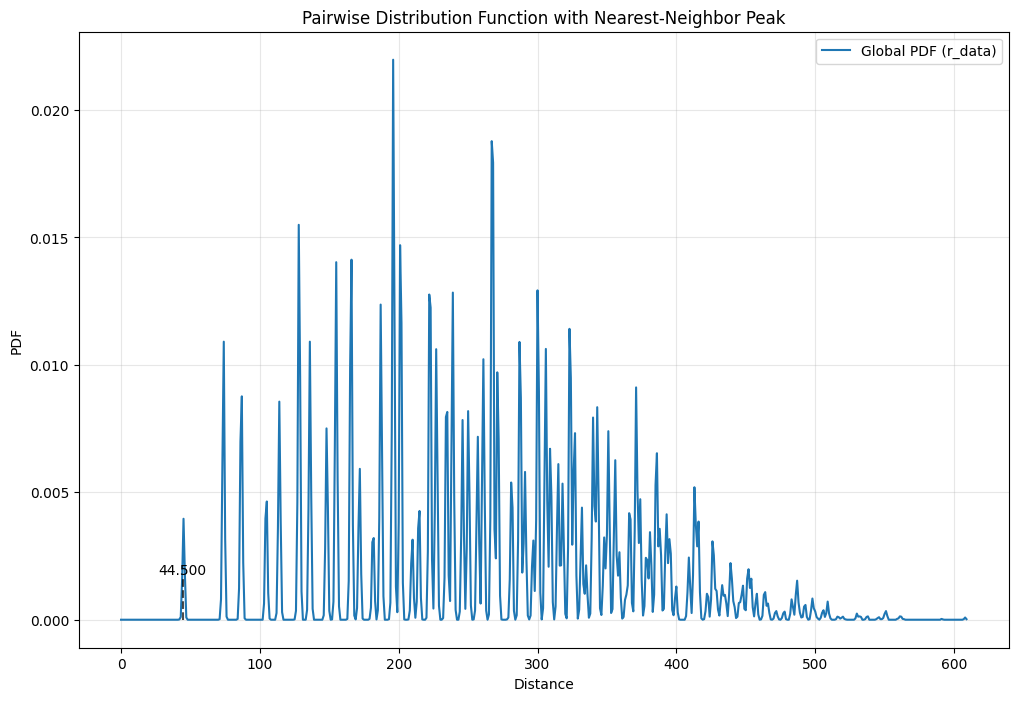

Nearest-neighbor peak (distance): 44.500000


In [10]:
# Nearest-neighbor peak from PDF: filtered_dataset

bin_size = 1  # adjust resolution if needed

# Pairwise distances
D_data = distance_matrix(filtered_dataset, filtered_dataset)
tri_data = np.triu_indices(D_data.shape[0], k=1)
distances_data = D_data[tri_data]
distances_data = distances_data[distances_data > 0]

# Histogram → PDF
bins_data = np.arange(0, distances_data.max() + bin_size, bin_size)
pdf_data, edges_data = np.histogram(distances_data, bins=bins_data, density=True)
centers = 0.5 * (edges_data[:-1] + edges_data[1:])

# Smooth PDF to help peak finding
pdf_smooth = _smooth(pdf_data, w=7)

# Find first peak (ignoring near-zero)
eps = max(1e-9, centers[1])
valid = centers > eps
prom = 0.05 * np.nanmax(pdf_smooth[valid])
candidate_rel, _ = find_peaks(pdf_smooth[valid], prominence=prom, distance=3)

if candidate_rel.size > 0:
    valid_idx = np.nonzero(valid)[0]
    peak_idx = valid_idx[candidate_rel[0]]
else:
    peak_idx = np.nonzero(valid)[0][np.argmax(pdf_smooth[valid])]

# Save nearest-neighbor peak as variable
first_nn_peak = float(centers[peak_idx])
first_nn_peak_height = float(pdf_data[peak_idx])

# --- Plot with annotation (edited) ---
plt.figure(figsize=(12, 8))
plt.plot(edges_data[:-1], pdf_data, label='Global PDF (r_data)')

# Vertical dotted line that stops at the curve height
plt.vlines(first_nn_peak, 0, first_nn_peak_height,
           linestyle='--', alpha=0.7, colors='k')

# Mark the peak point
# plt.scatter([first_nn_peak], [first_nn_peak_height], zorder=5, color='red')

# Label placed slightly above the peak
plt.text(first_nn_peak,
         first_nn_peak_height * 1.05,  # 5% higher
         f'{first_nn_peak:.3f}',
         ha='center', va='bottom',
         fontsize=10)

plt.xlabel('Distance')
plt.ylabel('PDF')
plt.title('Pairwise Distribution Function with Nearest-Neighbor Peak')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.show()

print(f"Nearest-neighbor peak (distance): {first_nn_peak:.6f}")


## Trim data: discard edge points

In [11]:
# Define r_data by trimming edge points
margin = first_nn_peak * 0.3  # cutoff distance

# Get dataset bounds
mins = np.min(filtered_dataset, axis=0)
maxs = np.max(filtered_dataset, axis=0)

# Keep only points that are >= margin away from all faces of the box
mask = np.all(
    (filtered_dataset >= (mins + margin)) &
    (filtered_dataset <= (maxs - margin)),
    axis=1
)

r_data = filtered_dataset[mask]

print(f"Original filtered_dataset size: {len(filtered_dataset)}")
print(f"Trimmed r_data size: {len(r_data)}")
print(f"Margin used: {margin:.3f}")


Original filtered_dataset size: 428
Trimmed r_data size: 280
Margin used: 13.350


## Recalculate NN distance

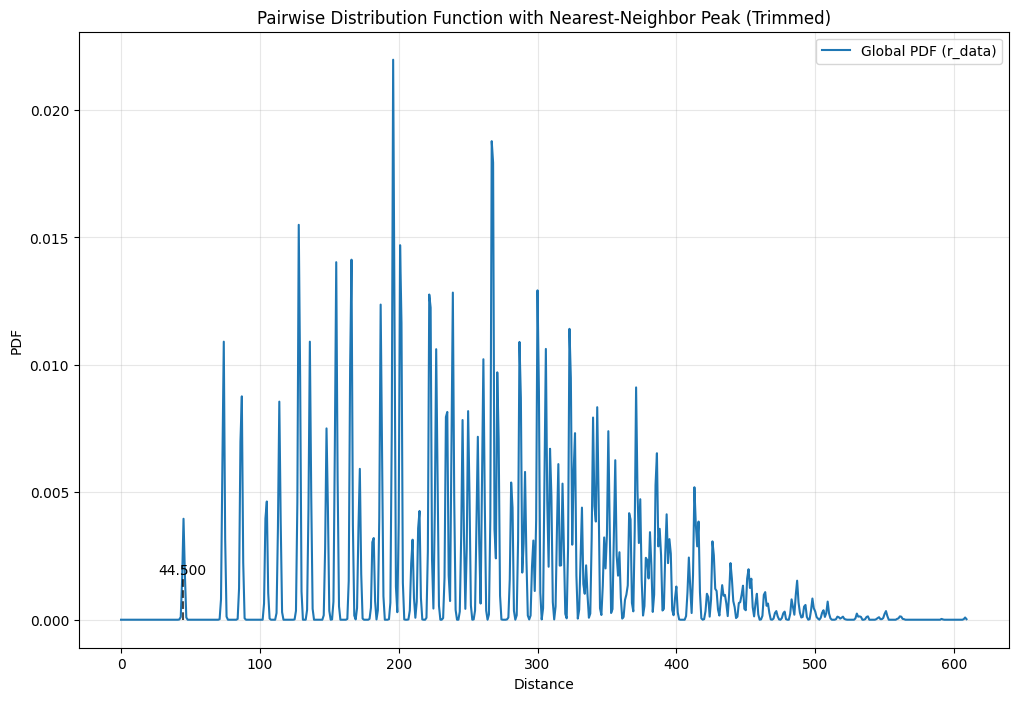

Nearest-neighbor peak (distance): 44.500000


In [12]:
# Nearest-neighbor peak from PDF: r_data
# Recalculating in case outliers skew the NN distance

bin_size = 1  # adjust resolution if needed

# Pairwise distances
D_data = distance_matrix(filtered_dataset, filtered_dataset)
tri_data = np.triu_indices(D_data.shape[0], k=1)
distances_data = D_data[tri_data]
distances_data = distances_data[distances_data > 0]

# Histogram → PDF
bins_data = np.arange(0, distances_data.max() + bin_size, bin_size)
pdf_data, edges_data = np.histogram(distances_data, bins=bins_data, density=True)
centers = 0.5 * (edges_data[:-1] + edges_data[1:])

# Smooth PDF to help peak finding
pdf_smooth = _smooth(pdf_data, w=7)

# Find first peak (ignoring near-zero)
eps = max(1e-9, centers[1])
valid = centers > eps
prom = 0.05 * np.nanmax(pdf_smooth[valid])
candidate_rel, _ = find_peaks(pdf_smooth[valid], prominence=prom, distance=3)

if candidate_rel.size > 0:
    valid_idx = np.nonzero(valid)[0]
    peak_idx = valid_idx[candidate_rel[0]]
else:
    peak_idx = np.nonzero(valid)[0][np.argmax(pdf_smooth[valid])]

# Save nearest-neighbor peak as variable
first_nn_peak_trim = float(centers[peak_idx])
first_nn_peak_trim_height = float(pdf_data[peak_idx])

# --- Plot with annotation (edited) ---
plt.figure(figsize=(12, 8))
plt.plot(edges_data[:-1], pdf_data, label='Global PDF (r_data)')

# Vertical dotted line that stops at the curve height
plt.vlines(first_nn_peak_trim, 0, first_nn_peak_trim_height, linestyle='--', alpha=0.7, colors='k')

# Mark the peak point
# plt.scatter([first_nn_peak_trim], [first_nn_peak_trim_height], zorder=5, color='red')

# Label placed slightly above the peak
plt.text(first_nn_peak_trim,
         first_nn_peak_trim_height * 1.05,  # 5% higher
         f'{first_nn_peak_trim:.3f}',
         ha='center', va='bottom',
         fontsize=10)

plt.xlabel('Distance')
plt.ylabel('PDF')
plt.title('Pairwise Distribution Function with Nearest-Neighbor Peak (Trimmed)')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.show()

print(f"Nearest-neighbor peak (distance): {first_nn_peak_trim:.6f}")


## Select best origin from cluster and pick FCC vectors

In [13]:
# --- Knobs ---
N_ORIGINS      = 12          # how many origins to test (increase for broader sweep)
SAMPLING       = "fps"       # 'fps' (farthest-point), 'random', or 'kmeanspp'
TOL_FRAC       = 0.20        # match tolerance as fraction of reference shell distance
PADDING        = 1           # expand ijk bounds beyond convex hull (integer cells)
MAX_K_NN       = 16          # candidates when skipping already-used points
TOP_K_ECDF     = 5           # how many best origins to overlay in the ECDF plot
RANDOM_SEED    = 42
crystal_type   = 'CD'        # use 'CD' for cubic diamond (two-FCC decomposition)

# Pull first-shell NN distance from whichever name you have
if 'first_nn_peak' in globals():
    _NN = float(first_nn_peak)
elif 'first_nn_peak_trim' in globals():
    _NN = float(first_nn_peak_trim)
else:
    raise NameError("Need first_nn_peak or first_nn_peak_trim defined.")

# For CD: fit function expects first-shell NN as input and internally targets second shell.
# Match tolerance is scaled by shell distance used for assignment.
if crystal_type == 'CD':
    FIT_LEN = _NN
    MATCH_LEN = _NN * (4.0 / np.sqrt(6.0))
else:
    FIT_LEN = _NN
    MATCH_LEN = _NN

# --- Imports ---
# import numpy as np
# import pandas as pd
# from itertools import combinations
# from scipy.spatial import cKDTree
# import matplotlib.pyplot as plt
# from math import isfinite
np.random.seed(RANDOM_SEED)

r_data = np.asarray(r_data, dtype=float)
assert r_data.ndim == 2 and r_data.shape[1] == 3, "r_data should be (N,3)"


# fps = farthest-point sampling: start with point closest to centroid, then pick the point farthest from the already chosen ones
# random = uniformly select random points from r_data
# kmeanspp = start with point closest to centroid,then each point after is chosen with a probability proportional to the squared distance from the closest already-chosen point

In [14]:
# --- CD/FCC shell sanity check ---
print("=== Lattice Shell Sanity Check ===")
print(f"crystal_type: {crystal_type}")
print(f"first-shell NN (_NN): {_NN:.6f}")
print(f"FIT_LEN: {FIT_LEN:.6f}")
print(f"MATCH_LEN: {MATCH_LEN:.6f}")
print(f"FIT_LEN / _NN: {FIT_LEN / _NN:.6f}")
print(f"MATCH_LEN / _NN: {MATCH_LEN / _NN:.6f}")

if crystal_type == 'CD':
    expected = 4.0 / np.sqrt(6.0)
    print(f"expected CD second-shell ratio (4/sqrt(6)): {expected:.6f}")
    print(f"match ratio error: {abs((MATCH_LEN / _NN) - expected):.3e}")

# Optional: vector norm check if these are already available from a prior run
if 'fcc_vectors_best' in globals():
    norms = np.linalg.norm(np.asarray(fcc_vectors_best, float), axis=1)
    print("fitted vector norms (fcc_vectors_best):", np.round(norms, 6))
    print("mean fitted norm:", float(np.mean(norms)))
    print("target fit length:", float(FIT_LEN))
else:
    print("fcc_vectors_best not defined yet (run origin sweep first).")

=== Lattice Shell Sanity Check ===
crystal_type: CD
first-shell NN (_NN): 44.500000
FIT_LEN: 44.500000
MATCH_LEN: 72.668196
FIT_LEN / _NN: 1.000000
MATCH_LEN / _NN: 1.632993
expected CD second-shell ratio (4/sqrt(6)): 1.632993
match ratio error: 0.000e+00
fcc_vectors_best not defined yet (run origin sweep first).


In [15]:
# --- CD sublattice coloring helper (two overlaid FCC sets) ---
def classify_cd_two_fcc(points, origin, vectors):
    """
    Classify each point into one of the two FCC sublattices of cubic diamond.
    Returns labels array of shape (N,), values {0, 1}.

    Uses fractional coordinates f = (r-origin) @ inv(V)^T and compares distance to:
      - FCC A lattice: integer grid               (f ~ Z^3)
      - FCC B lattice: shifted grid by (1/4,1/4,1/4)  (f-0.25 ~ Z^3)
    """
    P = np.asarray(points, float)
    o = np.asarray(origin, float).reshape(3,)
    V = np.asarray(vectors, float).reshape(3, 3)
    Vinv = np.linalg.inv(V)

    frac = (P - o) @ Vinv.T

    # Distance to nearest integer-lattice point (A)
    res_a = frac - np.rint(frac)
    da = np.linalg.norm(res_a, axis=1)

    # Distance to nearest shifted lattice point (B)
    frac_b = frac - 0.25
    res_b = frac_b - np.rint(frac_b)
    db = np.linalg.norm(res_b, axis=1)

    labels = (db < da).astype(int)
    return labels



def plot_cd_two_fcc(points, origin, vectors, ax=None, s=10, alpha=0.85,
                    color_a='tab:orange', color_b='tab:purple'):
    """Scatter plot with FCC-A/FCC-B color coding."""
    P = np.asarray(points, float)
    labels = classify_cd_two_fcc(P, origin, vectors)

    if ax is None:
        fig = plt.figure(figsize=(7, 6))
        ax = fig.add_subplot(111, projection='3d')

    m0 = labels == 0
    m1 = ~m0
    ax.scatter(P[m0, 0], P[m0, 1], P[m0, 2], s=s, c=color_a, alpha=alpha, label='FCC A')
    ax.scatter(P[m1, 0], P[m1, 1], P[m1, 2], s=s, c=color_b, alpha=alpha, label='FCC B')
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
    ax.legend(loc='best')
    return ax, labels

# Example (after origin/vectors are available):
# ax, sublat_labels = plot_cd_two_fcc(r_data, origin_best, fcc_vectors_best)
# plt.title('CD points colored by two FCC sublattices')
# plt.show()

In [16]:
# Create a mapping from r_data local index -> global particle_id (Row Index in filtered_dataset)

if 'mask' in globals():
    # np.where returns a tuple, [0] gets the array of indices where mask is True
    r_data_global_ids = np.where(mask)[0]
else:
    # Fallback: if mask is missing, assume indices are 1-to-1
    r_data_global_ids = np.arange(len(r_data))

origin_idxs = sample_origins(r_data, n=N_ORIGINS, method=SAMPLING)

results = []               # list of per-origin summary dicts
origin_artifacts = {}      # origin_id -> dict(fcc_vectors, df_matches, assignments, origin_point)

for rank, idx in enumerate(origin_idxs):
    # Bounds check: if idx is out of range, skip it
    if idx < 0 or idx >= len(r_data):
        print(f"Warning: origin index {idx} out of bounds for r_data size {len(r_data)}, skipping")
        continue
    
    origin = r_data[idx].copy()
    
    # --- FIX: Retrieve the Global Row Index to match Cell 60/64 ---
    pid = r_data_global_ids[idx] if idx < len(r_data_global_ids) else idx
    
    fcc_vectors = fit_fcc_vectors_for_origin(origin, r_data, nn_len=FIT_LEN, crystal_type=crystal_type)
    # Use two-sublattice assignment (FCC A + FCC B shift)
    assignments, df_matches, stats = assign_ijk_two_sublattices(
        r_data, origin, fcc_vectors, nn_len=FIT_LEN, match_len=MATCH_LEN,
        tol_frac=TOL_FRAC, padding=PADDING, max_k_nn=MAX_K_NN
    )

    rec = dict(
        origin_id=rank,
        particle_id=int(pid),         # <--- Now matches Cell 64 (Global Row Index, e.g., 65)
        origin_idx=int(idx),          # <--- Local r_data index (e.g., 27) - kept for reference
        origin_x=float(origin[0]), origin_y=float(origin[1]), origin_z=float(origin[2]),
        v11=float(fcc_vectors[0,0]), v12=float(fcc_vectors[0,1]), v13=float(fcc_vectors[0,2]),
        v21=float(fcc_vectors[1,0]), v22=float(fcc_vectors[1,1]), v23=float(fcc_vectors[1,2]),
        v31=float(fcc_vectors[2,0]), v32=float(fcc_vectors[2,1]), v33=float(fcc_vectors[2,2]),
        # --- keep counts explicitly ---
        matched_particles=stats["matched_particles"],
        total_particles=stats["total_particles"],
        matched_fraction=f"{stats['matched_particles']} / {stats['total_particles']}",
        matched_percent=stats["matched_particles"] / stats["total_particles"] * 100.0
    )
    # add other metrics (rmse, mse, d_min/med/max, pairs_filled, etc.)
    for k, v in stats.items():
        if k not in ["matched_pct"]:  # skip the old percent
            rec[k] = v

    results.append(rec)

    origin_artifacts[rank] = {
        "fcc_vectors": fcc_vectors,
        "df_matches": df_matches,
        "assignments": assignments,
        "origin_point": origin,
        "origin_particle_id": int(pid)
    }

In [17]:
pd.set_option('display.max_columns', None)

df_summary = pd.DataFrame(results).sort_values(
    ["rmse", "matched_percent"], ascending=[True, False]
).reset_index(drop=True)

# Reorder columns to show particle_id upfront
cols = ['origin_id', 'particle_id', 'origin_idx'] + [c for c in df_summary.columns if c not in ['origin_id', 'particle_id', 'origin_idx']]
df_summary = df_summary[cols]

# --- Enrich df_summary with cluster origins, vectors, and matched/predicted points ---
# We check if particle_registry_dict exists because in a linear run (Cell 1->21), 
# Cell 60 hasn't run yet, so the registry might be missing.
# This part is for manual looping
if 'particle_registry_dict' in globals():
    df_summary_enriched = enrich_summary_with_registry(df_summary, particle_registry_dict)
else:
    # If not yet available, we just use the summary as is (it still has the correct particle_id now)
    df_summary_enriched = df_summary

# display(df_summary_enriched)

best_origin_ids = df_summary["origin_id"].head(TOP_K_ECDF).to_list()
print("Top origins by RMSE:", best_origin_ids)

Top origins by RMSE: [0, 10, 11, 9, 1]


In [18]:
# Requires: df_summary from D2
w_rmse, w_match = 0.7, 0.3

rmse = df_summary["rmse"].to_numpy()
mp   = df_summary["matched_percent"].to_numpy()

# Robust min-max (avoid divide-by-zero)
rmse_min, rmse_max = np.nanmin(rmse), np.nanmax(rmse)
mp_min, mp_max     = np.nanmin(mp),   np.nanmax(mp)

rmse_den = (rmse_max - rmse_min) if (rmse_max > rmse_min) else 1.0
mp_den   = (mp_max   - mp_min)   if (mp_max   > mp_min)   else 1.0

rmse_norm  = (rmse - rmse_min) / rmse_den        # lower is better
match_norm = (mp   - mp_min)   / mp_den          # higher is better

score = w_rmse * (1.0 - rmse_norm) + w_match * match_norm

df_ranked = df_summary.copy()
df_ranked["rmse_norm"]   = rmse_norm
df_ranked["match_norm"]  = match_norm
df_ranked["score"]       = score

# Optional: penalize very low coverage (e.g., < 50% matched) by scaling the score
COVERAGE_FLOOR = 50.0  # percent
penalty = np.where(df_ranked["matched_percent"] < COVERAGE_FLOOR, 0.8, 1.0)
df_ranked["score"] *= penalty

df_ranked = df_ranked.sort_values(["score", "matched_percent"], ascending=[False, False]).reset_index(drop=True)

with pd.option_context('display.max_columns', None):
    display(df_ranked.loc[:, ["origin_id", "particle_id", "rmse", "matched_particles", "total_particles",
                              "matched_percent", "score"]])
print("Best origin by combined score:", int(df_ranked.loc[0, "origin_id"]))


,origin_id,particle_id,rmse,matched_particles,total_particles,matched_percent,score
0,0,227,4.339099,280,280,100.000000,1.000000
1,10,38,4.943358,280,280,100.000000,0.904081
2,11,215,5.475393,280,280,100.000000,0.819627
3,9,223,6.258984,280,280,100.000000,0.695242
4,2,380,7.149304,280,280,100.000000,0.553914
5,3,46,7.362437,280,280,100.000000,0.520082
6,8,378,7.374302,280,280,100.000000,0.518198
7,4,45,8.748885,276,280,98.571429,0.288889
8,1,53,6.964328,172,280,61.428571,0.283277
9,5,392,7.804899,172,280,61.428571,0.149846


Best origin by combined score: 0


In [19]:
# Set this to an integer origin id to override the auto-selection, or None to auto-pick:
CUSTOM_ORIGIN_ID = None  # e.g., 3 or 'None'

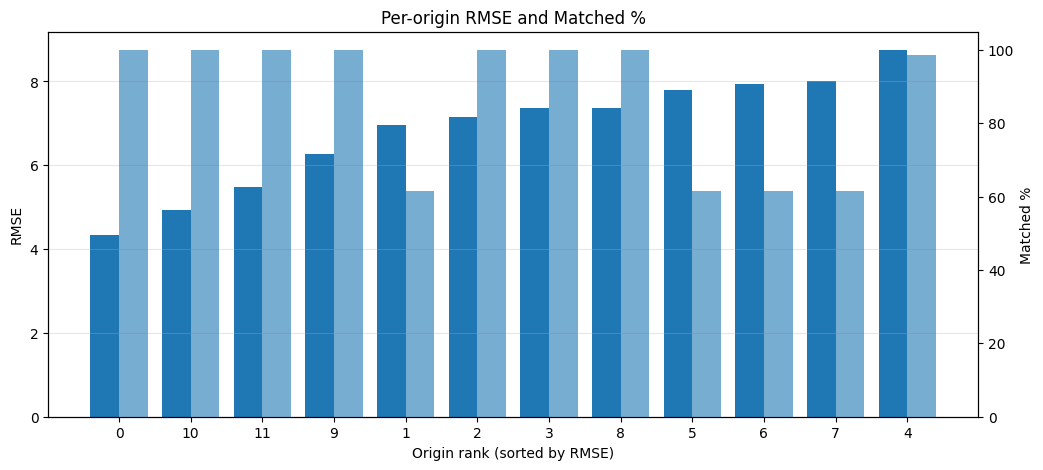

In [20]:
# Requires: df_summary

fig, ax1 = plt.subplots(figsize=(12, 5))

x = np.arange(len(df_summary))
rmse_vals = df_summary["rmse"].to_numpy()
match_vals = df_summary["matched_percent"].to_numpy()
labels = df_summary["origin_id"].astype(int).to_list()

b1 = ax1.bar(x - 0.2, rmse_vals, width=0.4)
ax1.set_ylabel("RMSE")
ax1.set_xlabel("Origin rank (sorted by RMSE)")
ax1.set_title("Per-origin RMSE and Matched %")
ax1.grid(True, axis='y', alpha=0.3)

ax2 = ax1.twinx()
b2 = ax2.bar(x + 0.2, match_vals, width=0.4, alpha=0.6)
ax2.set_ylabel("Matched %")

ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=0)
plt.show()


### Plot

In [21]:

# Validate prerequisites
if 'origin_artifacts' not in globals() or not origin_artifacts:
    raise NameError("origin_artifacts is missing or empty. Run D1 first.")
if 'df_summary' not in globals() or df_summary.empty:
    raise NameError("df_summary is missing or empty. Run D2 first.")

# Helper: pick best automatically

# Choose BEST_ORIGIN_ID (custom or auto)
if CUSTOM_ORIGIN_ID is not None:
    if int(CUSTOM_ORIGIN_ID) in origin_artifacts:
        BEST_ORIGIN_ID = int(CUSTOM_ORIGIN_ID)
        reason = "custom"
    else:
        avail = sorted(int(k) for k in origin_artifacts.keys())
        print(f"Warning: CUSTOM_ORIGIN_ID={CUSTOM_ORIGIN_ID} not found in available origins {avail}. Falling back to auto best.")
        BEST_ORIGIN_ID = _auto_best_origin_id()
        reason = "auto"
else:
    BEST_ORIGIN_ID = _auto_best_origin_id()
    reason = "auto"

# Unpack artifacts for plotting (P1/P2 expect these exact names)
best = origin_artifacts[BEST_ORIGIN_ID]
fcc_vectors_best = best["fcc_vectors"]
assignments_best = best["assignments"]
origin_best      = best["origin_point"]
df_matches_best  = best["df_matches"]

# Optional: print a tiny summary for the chosen origin
_row = df_summary.loc[df_summary['origin_id'] == BEST_ORIGIN_ID]
if not _row.empty:
    rmse_val = float(_row.iloc[0].get('rmse', float('nan')))
    mpct_val = float(_row.iloc[0].get('matched_percent', float('nan')))
    print(f"Using BEST_ORIGIN_ID = {BEST_ORIGIN_ID} ({reason}); RMSE={rmse_val:.4f}, matched%={mpct_val:.2f}")
else:
    print(f"Using BEST_ORIGIN_ID = {BEST_ORIGIN_ID} ({reason})")


Using BEST_ORIGIN_ID = 0 (auto); RMSE=4.3391, matched%=100.00


## Test different origins

Top 4 Origins by Score: [ 0 10 11  9]
Consistency 0 vs 10: Common=280, Mean Diff=4.4557, Max Diff=8.2420
Consistency 0 vs 11: Common=280, Mean Diff=4.5663, Max Diff=8.3016
Consistency 0 vs 9: Common=280, Mean Diff=5.6748, Max Diff=12.2790


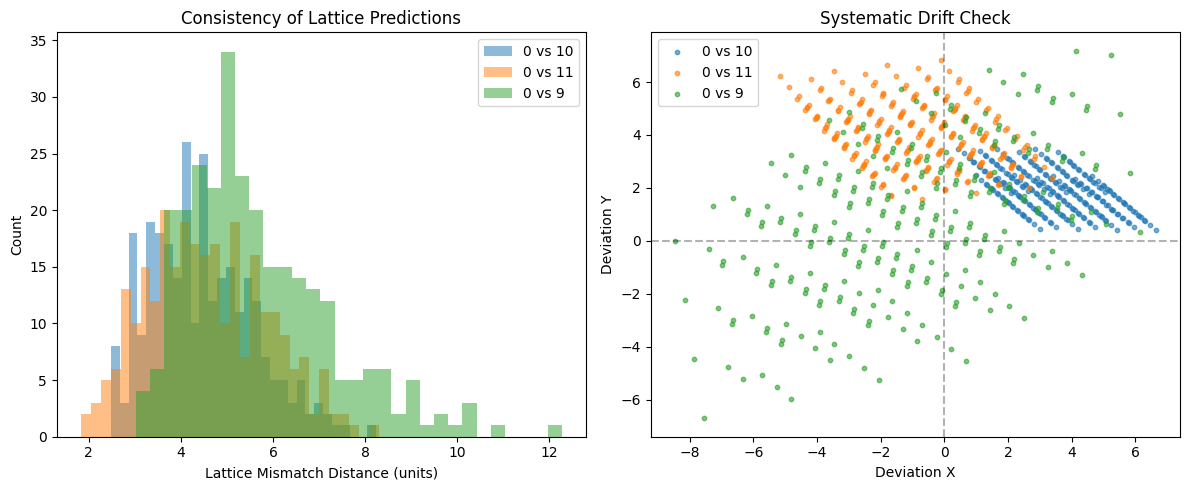

In [22]:
def analyze_field_consistency(results, origin_artifacts, top_k=3):
    """
    Checks if the top-ranked origins produce consistent displacement fields.
    
    1. Identifies top_k origins based on RMSE and Match %.
    2. Compares the predicted lattice positions (r_lattice) for particles matched in both.
    3. If r_lattice_A approx r_lattice_B, then the field is frame-independent.
    """
    # 1. Rank the origins
    df_res = pd.DataFrame(results)
    # Simple score: normalize RMSE (lower better) and Match% (higher better)
    # You can swap this for your preferred ranking logic
    rmse = df_res['rmse'].replace([np.inf, -np.inf], np.nan).fillna(df_res['rmse'].max())
    score = (1 - (rmse - rmse.min()) / (rmse.max() - rmse.min() + 1e-9)) + \
            (df_res['matched_percent'] / 100.0)
    
    df_res['score'] = score
    df_res = df_res.sort_values('score', ascending=False)
    
    top_ids = df_res['origin_id'].head(top_k).values
    print(f"Top {top_k} Origins by Score: {top_ids}")
    
    best_id = top_ids[0]
    best_df = origin_artifacts[best_id]['df_matches']
    
    # We will verify the others against the "Best" one
    comparisons = []
    
    for other_id in top_ids[1:]:
        other_df = origin_artifacts[other_id]['df_matches']
        
        # Intersect: Find particles matched in BOTH the best and the comparison run
        # We rely on the dataframe index being the particle ID (0 to N)
        # We assume rows with non-NaN 'distance' are matched
        
        mask_best = np.isfinite(best_df['distance'])
        mask_other = np.isfinite(other_df['distance'])
        common_mask = mask_best & mask_other
        
        if common_mask.sum() == 0:
            print(f"Origin {best_id} vs {other_id}: No common particles matched!")
            continue
            
        # Extract predicted lattice points for the common set
        # r_lattice = (lattice_x, lattice_y, lattice_z)
        r_lat_best = best_df.loc[common_mask, ['lattice_x', 'lattice_y', 'lattice_z']].values
        r_lat_other = other_df.loc[common_mask, ['lattice_x', 'lattice_y', 'lattice_z']].values
        
        # Deviation: How far is the lattice point predicted by A from the one predicted by B?
        # Ideally, this should be 0.0
        diffs = r_lat_best - r_lat_other
        deviations = np.linalg.norm(diffs, axis=1)
        
        mean_dev = np.mean(deviations)
        max_dev = np.max(deviations)
        
        comparisons.append({
            'compare': f"{best_id} vs {other_id}",
            'common_count': common_mask.sum(),
            'mean_deviation': mean_dev,
            'max_deviation': max_dev,
            'deviations': deviations,
            'diff_vectors': diffs,
            'common_indices': best_df.index[common_mask].values
        })
        
        print(f"Consistency {best_id} vs {other_id}: "
              f"Common={common_mask.sum()}, Mean Diff={mean_dev:.4f}, Max Diff={max_dev:.4f}")

    return comparisons

# --- Run the analysis ---
consistency_data = analyze_field_consistency(results, origin_artifacts, top_k=4)

# --- Visualization (Optional) ---
if consistency_data:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # 1. Histogram of deviations
    ax = axes[0]
    for comp in consistency_data:
        ax.hist(comp['deviations'], bins=30, alpha=0.5, label=comp['compare'])
    ax.set_xlabel("Lattice Mismatch Distance (units)")
    ax.set_ylabel("Count")
    ax.set_title("Consistency of Lattice Predictions")
    ax.legend()
    
    # 2. Vector Drift (Are the differences systematic?)
    # We plot the X component of the difference vs the Y component
    ax = axes[1]
    for comp in consistency_data:
        vecs = comp['diff_vectors']
        ax.scatter(vecs[:,0], vecs[:,1], s=10, alpha=0.6, label=comp['compare'])
    
    ax.axhline(0, color='k', linestyle='--', alpha=0.3)
    ax.axvline(0, color='k', linestyle='--', alpha=0.3)
    ax.set_xlabel("Deviation X")
    ax.set_ylabel("Deviation Y")
    ax.set_title("Systematic Drift Check")
    ax.legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient data to compare.")

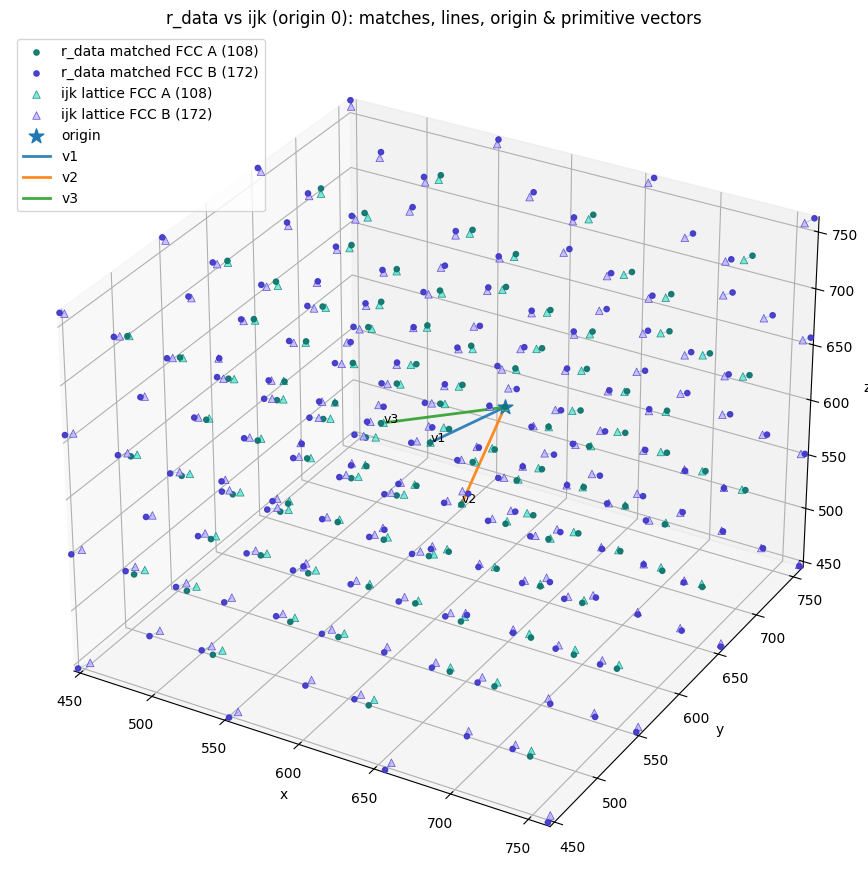

In [23]:
# Plot matching

# Expect: r_data, assignments_best, origin_best, fcc_vectors_best
if not assignments_best:
    raise ValueError("assignments_best is empty — nothing to plot.")

r_data = np.asarray(r_data, dtype=float)
matched_points  = np.array([rec["matched_point"] for rec in assignments_best], dtype=float)
lattice_points  = np.array([rec["lattice_point"] for rec in assignments_best], dtype=float)

# Figure out unmatched r_data points via coordinate set match (robust to duplicates)
DEC = 12
mp_set = set(map(tuple, np.round(matched_points, DEC)))
matched_mask = np.array([tuple(np.round(p, DEC)) in mp_set for p in r_data], dtype=bool)
unmatched_points = r_data[~matched_mask]

# Basis + origin (needed early for sublattice labels)
B = np.asarray(fcc_vectors_best, dtype=float)   # rows = v1, v2, v3
origin = np.asarray(origin_best, dtype=float)

# Extract sublattice directly from assignments_best instead of reclassifying
_labels = np.array([rec.get('sublattice', np.nan) for rec in assignments_best], dtype=float)
# For matched points, filter to only those with finite sublattice values
has_sublat = np.isfinite(_labels)
m0 = has_sublat & (_labels == 0)
m1 = has_sublat & (_labels == 1)

# Don't separate unmatched points by sublattice
_u_labels = np.zeros(len(unmatched_points), dtype=int)
u0 = _u_labels == 0  # All True

# Optional: limit connecting lines for readability
max_lines = None  # e.g., 300
if max_lines is not None and len(matched_points) > max_lines:
    sel = np.linspace(0, len(matched_points)-1, max_lines, dtype=int)
    matched_points_lines = matched_points[sel]
    lattice_points_lines = lattice_points[sel]
else:
    matched_points_lines = matched_points
    lattice_points_lines = lattice_points

# Build line segments for matches
segments = np.stack([lattice_points_lines, matched_points_lines], axis=1)  # (M,2,3)

fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection='3d')

# Unmatched r_data (no sublattice separation)
if len(unmatched_points):
    ax.scatter(unmatched_points[:,0], unmatched_points[:,1], unmatched_points[:,2],
               s=8, alpha=0.28, c='#888888', label=f"r_data unmatched ({len(unmatched_points)})")

# Matched r_data + mapped points, color-coded by CD sublattice when available

ax.scatter(matched_points[m0,0], matched_points[m0,1], matched_points[m0,2],
           s=14, alpha=0.95, c='#0F766E', label=f"r_data matched FCC A ({np.count_nonzero(m0)})")
ax.scatter(matched_points[m1,0], matched_points[m1,1], matched_points[m1,2],
           s=14, alpha=0.95, c='#4338CA', label=f"r_data matched FCC B ({np.count_nonzero(m1)})")

ax.scatter(lattice_points[m0,0], lattice_points[m0,1], lattice_points[m0,2],
           s=30, alpha=0.85, marker="^", c='#5EEAD4', edgecolors='#0F766E', linewidths=0.5,
           label=f"ijk lattice FCC A ({np.count_nonzero(m0)})")
ax.scatter(lattice_points[m1,0], lattice_points[m1,1], lattice_points[m1,2],
           s=30, alpha=0.85, marker="^", c='#C4B5FD', edgecolors='#4338CA', linewidths=0.5,
           label=f"ijk lattice FCC B ({np.count_nonzero(m1)})")

# Connecting lines
try:
    lc = Line3DCollection(segments, linewidths=0.6, alpha=0.35)
    ax.add_collection3d(lc)
except Exception:
    for a, b in segments:
        ax.plot([a[0], b[0]], [a[1], b[1]], [a[2], b[2]], linewidth=0.6, alpha=0.35)

# Origin + primitive vectors
ax.scatter(origin[0], origin[1], origin[2], s=120, marker='*', zorder=6, label="origin")
for i, name in enumerate(["v1","v2","v3"]):
    p_end = origin + B[i]
    ax.plot([origin[0], p_end[0]], [origin[1], p_end[1]], [origin[2], p_end[2]],
            linewidth=2.0, alpha=0.9, label=name)
    ax.text(p_end[0], p_end[1], p_end[2], name, fontsize=9)

# Cosmetics
all_pts = np.vstack([r_data, lattice_points])
set_axes_equal(ax, all_pts)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title(f"r_data vs ijk (origin {BEST_ORIGIN_ID}): matches, lines, origin & primitive vectors")

# De-duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), loc="upper left", bbox_to_anchor=(0,1))

# %matplotlib widget

plt.tight_layout()
plt.show()

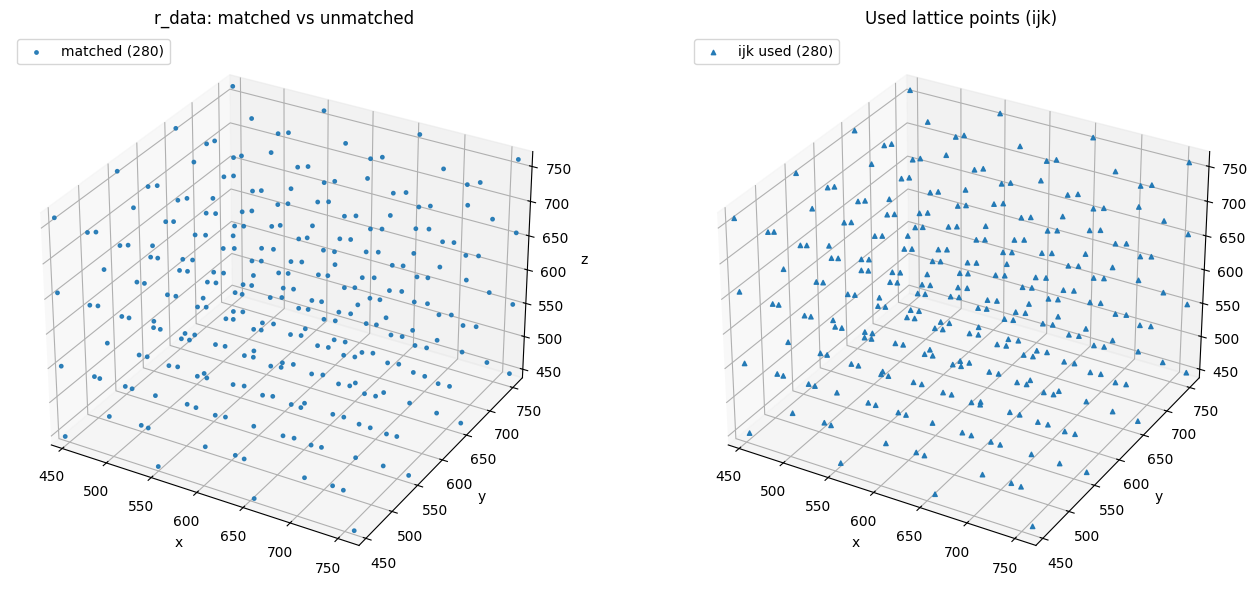

Matched = 280 / 280 (100.0%)
Used ijk points plotted = 280


In [24]:
# Side-by-side

# Expect: r_data, assignments_best
r_data = np.asarray(r_data, dtype=float)

matched_points = np.array([rec["matched_point"] for rec in assignments_best], dtype=float)
lattice_used   = np.array([rec["lattice_point"] for rec in assignments_best], dtype=float)

# Build matched/unmatched mask by coordinate set
DEC = 12
mp_set = set(map(tuple, np.round(matched_points, DEC)))
matched_mask = np.array([tuple(np.round(p, DEC)) in mp_set for p in r_data], dtype=bool)
unmatched_points = r_data[~matched_mask]
matched_points_exact = r_data[matched_mask]  # exact rows from r_data


# Global equal bounds across both clouds so scales match
all_pts = np.vstack([r_data, lattice_used]) if lattice_used.size else r_data
global_bounds = compute_equal_bounds(all_pts, pad=0.05)

# --- Figure with 1x2 subplots (LEFT: r_data; RIGHT: ijk used) ---
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')  # LEFT
ax2 = fig.add_subplot(1, 2, 2, projection='3d')  # RIGHT

# LEFT: r_data matched vs unmatched
ax1.set_title("r_data: matched vs unmatched")
if len(unmatched_points):
    ax1.scatter(unmatched_points[:,0], unmatched_points[:,1], unmatched_points[:,2],
                s=6, alpha=0.25, label=f"unmatched ({len(unmatched_points)})")
if len(matched_points_exact):
    ax1.scatter(matched_points_exact[:,0], matched_points_exact[:,1], matched_points_exact[:,2],
                s=6, alpha=0.9, marker="o", label=f"matched ({matched_mask.sum()})")
apply_bounds(ax1, global_bounds)
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("z")
ax1.legend(loc="upper left", bbox_to_anchor=(0,1))

# RIGHT: ONLY the used ijk lattice points
ax2.set_title("Used lattice points (ijk)")
if lattice_used.size:
    ax2.scatter(lattice_used[:,0], lattice_used[:,1], lattice_used[:,2],
                s=10, alpha=0.95, marker="^", label=f"ijk used ({len(lattice_used)})")
apply_bounds(ax2, global_bounds)
ax2.set_xlabel("x"); ax2.set_ylabel("y"); ax2.set_zlabel("z")
ax2.legend(loc="upper left", bbox_to_anchor=(0,1))

# --- Sync the two 3D views (rotate/zoom/pan) ---


for ev in ('motion_notify_event', 'button_release_event', 'scroll_event'):
    fig.canvas.mpl_connect(ev, _on_any)

plt.tight_layout()
plt.show()

# Summary
total = len(r_data)
matched_n = matched_mask.sum()
print(f"Matched = {matched_n} / {total} ({(matched_n/total*100.0 if total else 0.0):.1f}%)")
print(f"Used ijk points plotted = {len(lattice_used)}")


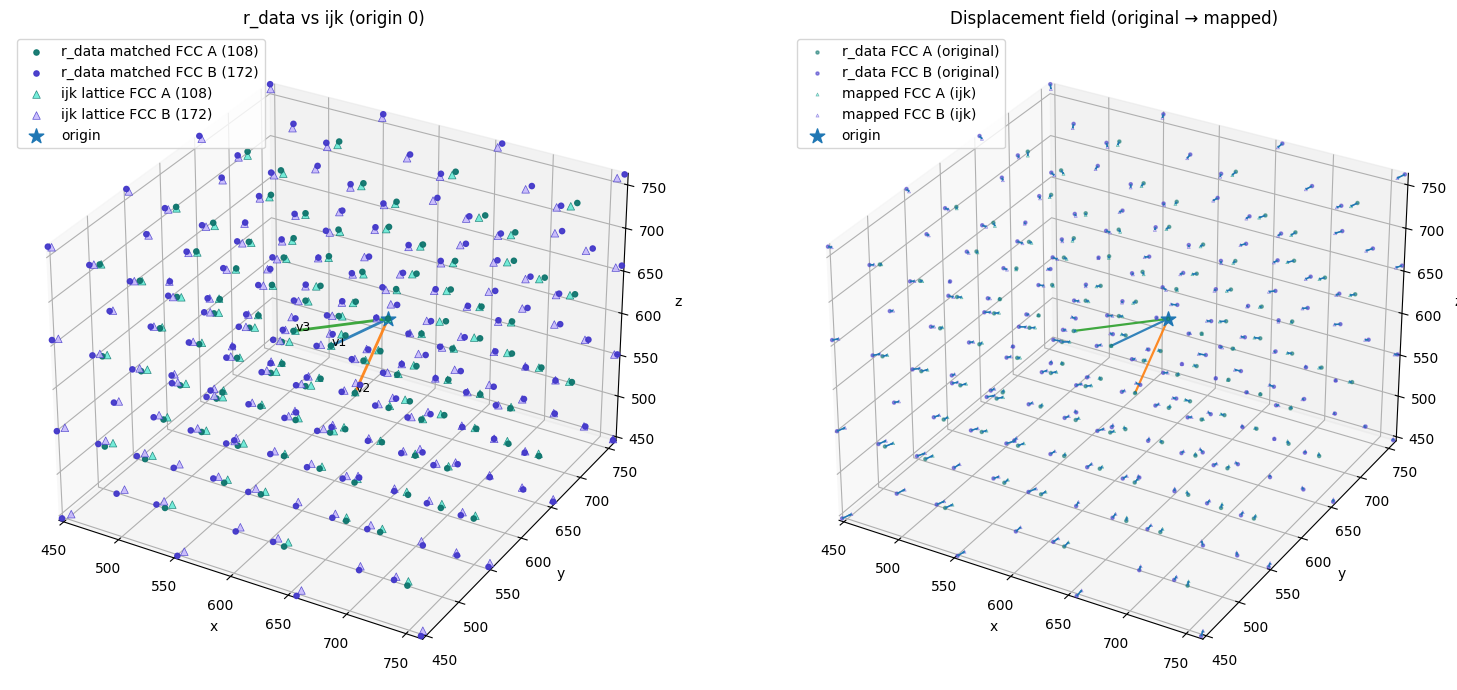

Matched particles: 280 / 280 (100.0%)
Plotted 280 displacement connections.
Displacement | mean: 4.0773, median: 4.1009, max: 8.2169
Matched FCC A/B: 108 / 172


In [25]:
# --- Side-by-side with SYNCHRONIZED camera + vector-field displacements (original → mapped) ---

# Expect: r_data, assignments_best, origin_best, fcc_vectors_best, BEST_ORIGIN_ID
if not assignments_best:
    raise ValueError("assignments_best is empty — nothing to plot.")

# import numpy as np
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d.art3d import Line3DCollection

r_data = np.asarray(r_data, dtype=float)
matched_points  = np.array([rec["matched_point"]  for rec in assignments_best], dtype=float)  # original data points used
lattice_points  = np.array([rec["lattice_point"]  for rec in assignments_best], dtype=float)  # mapped (predicted) points

# Identify unmatched originals for context
DEC = 12
mp_set = set(map(tuple, np.round(matched_points, DEC)))
matched_mask = np.array([tuple(np.round(p, DEC)) in mp_set for p in r_data], dtype=bool)
unmatched_points = r_data[~matched_mask]

# Optional: subsample lines if very dense
max_lines = None  # e.g., 500
if max_lines is not None and len(matched_points) > max_lines:
    sel = np.linspace(0, len(matched_points)-1, max_lines, dtype=int)
    matched_points_lines = matched_points[sel]
    lattice_points_lines = lattice_points[sel]
else:
    matched_points_lines = matched_points
    lattice_points_lines = lattice_points

# Displacement vectors (original → mapped)
disp_vecs = lattice_points_lines - matched_points_lines
disp_mag  = np.linalg.norm(disp_vecs, axis=1)

# Equal-aspect helper

# Build line segments (original → mapped) for right panel fallback/overlay
segments = np.stack([matched_points_lines, lattice_points_lines], axis=1)  # (M,2,3)

# Basis + origin
B = np.asarray(fcc_vectors_best, dtype=float)   # rows = v1, v2, v3
origin = np.asarray(origin_best, dtype=float)

# Extract sublattice from assignments_best (0=FCC A, 1=FCC B, NaN=unmatched)
_labels = np.full(len(assignments_best), np.nan, dtype=float)
for i, rec in enumerate(assignments_best):
    sublat = rec.get('sublattice', np.nan)
    _labels[i] = sublat

# For matched points: filter to only those with finite sublattice values
matched_mask_with_sublat = np.isfinite(_labels)
_labels_matched = _labels[matched_mask_with_sublat].astype(int)
m0 = (_labels_matched == 0)
m1 = (_labels_matched == 1)

# Unmatched points have no sublattice separation
_u_labels = np.zeros(len(unmatched_points), dtype=int)  # All one group
u0 = np.ones(len(unmatched_points), dtype=bool)  # All in first (only) group
u1 = np.zeros(len(unmatched_points), dtype=bool)  # None in second group

# ----- Figure & Axes -----
fig = plt.figure(figsize=(16, 7))
axL = fig.add_subplot(1, 2, 1, projection='3d')
axR = fig.add_subplot(1, 2, 2, projection='3d')

# ----- LEFT: context (no lines) -----
if len(unmatched_points):
    axL.scatter(unmatched_points[u0,0], unmatched_points[u0,1], unmatched_points[u0,2],
                s=8, alpha=0.28, c='#0F766E', label=f"r_data unmatched FCC A ({np.count_nonzero(u0)})")
    axL.scatter(unmatched_points[u1,0], unmatched_points[u1,1], unmatched_points[u1,2],
                s=8, alpha=0.28, c='#4338CA', label=f"r_data unmatched FCC B ({np.count_nonzero(u1)})")

axL.scatter(matched_points[m0,0], matched_points[m0,1], matched_points[m0,2],
            s=14, alpha=0.95, c='#0F766E', label=f"r_data matched FCC A ({np.count_nonzero(m0)})")
axL.scatter(matched_points[m1,0], matched_points[m1,1], matched_points[m1,2],
            s=14, alpha=0.95, c='#4338CA', label=f"r_data matched FCC B ({np.count_nonzero(m1)})")
axL.scatter(lattice_points[m0,0], lattice_points[m0,1], lattice_points[m0,2],
            s=30, alpha=0.85, marker="^", c='#5EEAD4', edgecolors='#0F766E', linewidths=0.5,
            label=f"ijk lattice FCC A ({np.count_nonzero(m0)})")
axL.scatter(lattice_points[m1,0], lattice_points[m1,1], lattice_points[m1,2],
            s=30, alpha=0.85, marker="^", c='#C4B5FD', edgecolors='#4338CA', linewidths=0.5,
            label=f"ijk lattice FCC B ({np.count_nonzero(m1)})")

axL.scatter(*origin, s=120, marker='*', zorder=6, label="origin")
for i, name in enumerate(["v1","v2","v3"]):
    p_end = origin + B[i]
    axL.plot([origin[0], p_end[0]], [origin[1], p_end[1]], [origin[2], p_end[2]], linewidth=2.0, alpha=0.9)
    axL.text(*p_end, name, fontsize=9)

# ----- RIGHT: vector field (original → mapped) -----
# Scatter endpoints for context (same two-FCC colors)
axR.scatter(matched_points[m0,0], matched_points[m0,1], matched_points[m0,2],
            s=5, alpha=0.55, c='#0F766E', label="r_data FCC A (original)")
axR.scatter(matched_points[m1,0], matched_points[m1,1], matched_points[m1,2],
            s=5, alpha=0.55, c='#4338CA', label="r_data FCC B (original)")
axR.scatter(lattice_points[m0,0], lattice_points[m0,1], lattice_points[m0,2],
            s=5, alpha=0.55, marker="^", c='#5EEAD4', edgecolors='#0F766E', linewidths=0.4,
            label="mapped FCC A (ijk)")
axR.scatter(lattice_points[m1,0], lattice_points[m1,1], lattice_points[m1,2],
            s=5, alpha=0.55, marker="^", c='#C4B5FD', edgecolors='#4338CA', linewidths=0.4,
            label="mapped FCC B (ijk)")

# Quiver arrows from original to mapped (comment out if you prefer only lines)
try:
    axR.quiver(matched_points_lines[:,0], matched_points_lines[:,1], matched_points_lines[:,2],
               disp_vecs[:,0],            disp_vecs[:,1],            disp_vecs[:,2],
               length=1.0, normalize=False, linewidth=1, alpha=0.7)
except Exception:
    pass  # Some Matplotlib builds are picky; we'll still plot segments below.

# Also draw thin connecting lines for clarity / fallback
try:
    lc = Line3DCollection(segments, linewidths=1, alpha=1)
    axR.add_collection3d(lc)
except Exception:
    for a, b in segments:
        axR.plot([a[0], b[0]], [a[1], b[1]], [a[2], b[2]], linewidth=0.6, alpha=0.35)

# Origin + basis (reference only)
axR.scatter(*origin, s=120, marker='*', zorder=6, label="origin")
for i in range(3):
    p_end = origin + B[i]
    axR.plot([origin[0], p_end[0]], [origin[1], p_end[1]], [origin[2], p_end[2]], linewidth=1.6, alpha=0.9)

# ----- Shared cosmetics & initial equal aspect -----
all_pts = np.vstack([r_data, lattice_points])
set_axes_equal(axL, all_pts)
set_axes_equal(axR, all_pts)

for ax, title in [(axL, f"r_data vs ijk (origin {BEST_ORIGIN_ID})"),
                  (axR, "Displacement field (original → mapped)")]:
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
    ax.set_title(title)
    # de-dup legend
    h, l = ax.get_legend_handles_labels()
    uniq = dict(zip(l, h))
    ax.legend(uniq.values(), uniq.keys(), loc="upper left", bbox_to_anchor=(0,1))

# ----- VIEW SYNCHRONIZATION -----

# initialize with identical views/limits
copy_view(axL, axR)


cid1 = fig.canvas.mpl_connect('motion_notify_event', on_mouse)
cid2 = fig.canvas.mpl_connect('button_release_event', on_mouse)
cid3 = fig.canvas.mpl_connect('draw_event', on_draw)

plt.tight_layout()
plt.show()

# --- Summary ---
total = len(r_data)
matched_n = matched_mask.sum()
mean_d = float(np.mean(disp_mag)) if disp_mag.size else 0.0
median_d = float(np.median(disp_mag)) if disp_mag.size else 0.0
max_d = float(np.max(disp_mag)) if disp_mag.size else 0.0

print(f"Matched particles: {matched_n} / {total} ({(matched_n/total*100):.1f}%)")
print(f"Plotted {len(segments)} displacement connections.")
print(f"Displacement | mean: {mean_d:.4f}, median: {median_d:.4f}, max: {max_d:.4f}")
print(f"Matched FCC A/B: {np.count_nonzero(m0)} / {np.count_nonzero(m1)}")
if len(unmatched_points):
    print(f"Unmatched FCC A/B: {np.count_nonzero(u0)} / {np.count_nonzero(u1)}")


### Trim data: select for continuous/adjacent particles

In [26]:
print("origin:", np.asarray(origin_best))
print("lattice_vectors:", np.asarray(fcc_vectors_best))
print("matched_points:", len(matched_points))
print("lattice_points:", len(lattice_points))

origin: [629.85943552 630.03454134 630.19309473]
lattice_vectors: [[-50.81973899   1.06948322 -51.93146447]
 [  0.67903731 -51.35445189 -51.40939453]
 [-52.0814988  -50.67543213  -0.42979984]]
matched_points: 280
lattice_points: 280


In [27]:
# Check origin_artifacts AFTER re-running the sweep loop
print("Checking origin_artifacts after sweep re-execution...")
if origin_artifacts:
    first_oid = list(origin_artifacts.keys())[0]
    first_rec = origin_artifacts[first_oid]['assignments']
    print(f"\nFirst origin ({first_oid}) first 3 assignments:")
    for i in range(min(3, len(first_rec))):
        rec = first_rec[i]
        print(f"  [{i}] keys: {list(rec.keys())}")
        if 'sublattice' in rec:
            print(f"      sublattice: {rec['sublattice']}")
        else:
            print(f"      sublattice: NOT PRESENT")
            
    # Count sublattices in first origin
    has_sublat = sum(1 for rec in first_rec if 'sublattice' in rec)
    all_sublat = [rec.get('sublattice') for rec in first_rec]
    print(f"\nTotal with sublattice field in first origin: {has_sublat} / {len(first_rec)}")
    print(f"Sublattice values: {set(all_sublat)}")
    
    # Count across all origins
    total_with_sublat = 0
    total_assignments = 0
    for oid, artifacts in origin_artifacts.items():
        for rec in artifacts['assignments']:
            total_assignments += 1
            if 'sublattice' in rec:
                total_with_sublat += 1
    print(f"\nTotal across ALL origins: {total_with_sublat} / {total_assignments} have sublattice field")
else:
    print("origin_artifacts is empty!")

print("\n---\n")

# Now check what's in assignments_best (which comes from best origin)
if 'assignments_best' in globals():
    print(f"assignments_best (from BEST_ORIGIN_ID={BEST_ORIGIN_ID}):")
    print(f"Sample fields from first 3 assignments_best:")
    for i in range(min(3, len(assignments_best))):
        rec = assignments_best[i]
        print(f"  [{i}] keys: {list(rec.keys())}")
        if 'sublattice' in rec:
            print(f"      sublattice: {rec['sublattice']}")
        else:
            print(f"      sublattice: NOT PRESENT")
else:
    print("assignments_best not yet loaded (need to run cell that selects best origin)")


Checking origin_artifacts after sweep re-execution...

First origin (0) first 3 assignments:
  [0] keys: ['ijk', 'lattice_point', 'matched_point', 'distance', 'sublattice']
      sublattice: 0
  [1] keys: ['ijk', 'lattice_point', 'matched_point', 'distance', 'sublattice']
      sublattice: 0
  [2] keys: ['ijk', 'lattice_point', 'matched_point', 'distance', 'sublattice']
      sublattice: 0

Total with sublattice field in first origin: 280 / 280
Sublattice values: {0, 1}

Total across ALL origins: 2928 / 2928 have sublattice field

---

assignments_best (from BEST_ORIGIN_ID=0):
Sample fields from first 3 assignments_best:
  [0] keys: ['ijk', 'lattice_point', 'matched_point', 'distance', 'sublattice']
      sublattice: 0
  [1] keys: ['ijk', 'lattice_point', 'matched_point', 'distance', 'sublattice']
      sublattice: 0
  [2] keys: ['ijk', 'lattice_point', 'matched_point', 'distance', 'sublattice']
      sublattice: 0


In [28]:
# Compare matched_points and lattice_points

# Preconditions
if 'matched_points' not in globals() or 'lattice_points' not in globals():
    raise NameError("Need 'matched_points' and 'lattice_points' in scope.")

P = np.asarray(matched_points, dtype=float)
Q = np.asarray(lattice_points, dtype=float)

if P.ndim != 2 or Q.ndim != 2 or P.shape[1] != 3 or Q.shape[1] != 3:
    raise ValueError(f"Expected (N,3) arrays, got {P.shape} and {Q.shape}")

# Align lengths if needed
N = min(len(P), len(Q))
if len(P) != len(Q):
    print(f"Warning: length mismatch P={len(P)} vs Q={len(Q)}. Comparing first {N} pairs.")
P = P[:N]
Q = Q[:N]

# Displacements and norms
D = Q - P
d = np.linalg.norm(D, axis=1)

# Axis-wise bias and spread
bias = D.mean(axis=0)
std = D.std(axis=0)

# Metrics
rmse = float(np.sqrt(np.mean(d**2))) if N else np.nan
mae  = float(np.mean(np.abs(d))) if N else np.nan
med  = float(np.median(d)) if N else np.nan
dmin = float(d.min()) if N else np.nan
dmax = float(d.max()) if N else np.nan

# Tolerance-based coverage if available
tol = None
pct_within = None
if '_NN' in globals() and 'TOL_FRAC' in globals():
    tol = float(TOL_FRAC * _NN)
    pct_within = float((d <= tol).mean() * 100.0)

# Summary printout
# print(f"Pairs compared: {N}")
# print(f"RMSE: {rmse:.6f}, MAE: {mae:.6f}, median: {med:.6f}, min: {dmin:.6f}, max: {dmax:.6f}")
# print(f"Axis bias (Q-P): dx={bias[0]:.6f}, dy={bias[1]:.6f}, dz={bias[2]:.6f}")
# print(f"Axis std (Q-P):  sx={std[0]:.6f}, sy={std[1]:.6f}, sz={std[2]:.6f}")
# if tol is not None:
#     print(f"Within tolerance ({tol:.6f}) : {pct_within:.2f}%")

# Small table preview
df_cmp = pd.DataFrame({
    "m_x": P[:,0], "m_y": P[:,1], "m_z": P[:,2],
    "lat_x": Q[:,0], "lat_y": Q[:,1], "lat_z": Q[:,2],
    "dx": D[:,0], "dy": D[:,1], "dz": D[:,2],
    "|d|": d
})
display(df_cmp.head(10))

# # Optional: histogram + ECDF of distances
# fig, ax = plt.subplots(1, 2, figsize=(12, 4))
# ax[0].hist(d, bins=20, alpha=0.8)
# ax[0].set_title("Displacement magnitude histogram")
# ax[0].set_xlabel("|Q - P|"); ax[0].set_ylabel("count")
# if tol is not None:
#     ax[0].axvline(tol, ls="--", c="r", label=f"tol={tol:.3f}")
#     ax[0].legend()

# d_sorted = np.sort(d)
# y = np.arange(1, N+1) / N
# ax[1].plot(d_sorted, y)
# ax[1].set_title("ECDF of |Q - P|")
# ax[1].set_xlabel("|Q - P|"); ax[1].set_ylabel("ECDF")
# if tol is not None:
#     ax[1].axvline(tol, ls="--", c="r")

# plt.tight_layout()
# plt.show()

,m_x,m_y,m_z,lat_x,lat_y,lat_z,dx,dy,dz,|d|
0,629.859436,630.034541,630.193095,629.859436,630.034541,630.193095,0.000000,0.000000,0.000000,0.000000
1,735.805418,525.205506,736.014484,730.916191,524.796208,734.148294,-4.889227,-0.409298,-1.866190,5.249260
2,683.409905,471.967425,735.593759,678.834692,474.120776,733.718494,-4.575213,2.153350,-1.875265,5.393154
3,735.654308,472.998264,682.919918,731.595228,473.441756,682.738899,-4.059080,0.443492,-0.181018,4.087246
4,735.851591,630.227529,735.760490,731.498913,627.895575,734.056024,-4.352677,-2.331954,-1.704466,5.223889
5,682.477984,578.098556,734.744794,679.417415,577.220143,733.626224,-3.060570,-0.878413,-1.118570,3.374892
6,631.019266,526.342559,735.228001,627.335916,526.544711,733.196424,-3.683350,0.202152,-2.031577,4.211323
7,577.809822,472.696236,735.205694,575.254417,475.869279,732.766624,-2.555405,3.173043,-2.439070,4.748406
8,736.412302,577.727389,682.634743,732.177951,576.541123,682.646629,-4.234352,-1.186266,0.011887,4.397397
9,682.145774,525.122987,682.466009,680.096452,525.865691,682.216829,-2.049322,0.742704,-0.249180,2.193951


<!-- ### Trim matched points for minimization
- Set a box size for the particles picked, or identify sufficient discontinuity from index skipping to cut the matched dataset off at a certain value
- Think about shape of the box: is continnuity of grain or cube shape more important? -->

In [29]:
NEIGHBOR_MODE = 6   # choose 6 or 26

In [30]:
# --- Radial/shell continuity filter with selectable neighborhood (6 or 26) ---
# Options: set to 6 for face-adjacent only, or 26 for face+edge+corner adjacency


# ------------- Part A: Radial shell continuity filter starting at ijk=(0,0,0) -------------
# Collect matched/lattice points and indices
matched_pts, lattice_pts, ids = [], [], []
for idx, rec in enumerate(assignments_best):
    mp = rec.get('matched_point', rec.get('r_point', None))
    lp = rec.get('lattice_point', rec.get('predicted_point', None))
    if mp is None or lp is None:
        continue
    matched_pts.append(np.asarray(mp, float))
    lattice_pts.append(np.asarray(lp, float))
    ids.append(idx)

if len(ids) == 0:
    raise ValueError("No usable records in assignments_best (missing matched/lattice points).")

matched_pts = np.asarray(matched_pts, float)
lattice_pts = np.asarray(lattice_pts, float)
ids = np.asarray(ids, int)

V0 = np.asarray(fcc_vectors_best, float).reshape(3,3)
o0 = np.asarray(origin_best, float).reshape(3,)
V0_inv = np.linalg.inv(V0)

# Prefer lattice points when possible
use_lp = np.isfinite(lattice_pts).all(axis=1)
cand = np.where(use_lp[:,None], lattice_pts, matched_pts)

K_float = (V0_inv @ (cand - o0).T).T
K_ijk = np.rint(K_float).astype(int)

# --- Build shells radially by L1 norm (Manhattan distance) ---
L1 = np.sum(np.abs(K_ijk), axis=1)
max_shell = int(np.max(L1))

# Start with origin shell (0,0,0); if none, abort this filter
mask0 = np.all(K_ijk == 0, axis=1)
if not np.any(mask0):
    print("Radial continuity (Part A): No ijk == (0,0,0) seed found. Skipping Part A.")
    ids_cont = np.array([], int)
    K_cont = np.empty((0,3), int)
    matched_cont = np.empty((0,3), float)
    lattice_cont = np.empty((0,3), float)
    assignments_continuous = []
else:
    kept_ids = []
    kept_ijk = []
    kept_matched = []
    kept_lattice = []

    # Initialize with shell 0
    current_shell_ids = ids[mask0]
    current_shell_ijk = K_ijk[mask0]
    current_shell_matched = matched_pts[mask0]
    current_shell_lattice = lattice_pts[mask0]

    kept_ids.extend(current_shell_ids.tolist())
    kept_ijk.extend(current_shell_ijk.tolist())
    kept_matched.extend(current_shell_matched.tolist())
    kept_lattice.extend(current_shell_lattice.tolist())

    # Iterate outward shells
    for shell in range(1, max_shell+1):
        mask = (L1 == shell)
        if not np.any(mask):
            break
        shell_ids = ids[mask]
        shell_ijk = K_ijk[mask]
        shell_matched = matched_pts[mask]
        shell_lattice = lattice_pts[mask]

        K_prev = np.array(current_shell_ijk, int)
        keep_mask = np.array([_is_neighbor_any(k, K_prev, NEIGHBOR_MODE) for k in shell_ijk], dtype=bool)

        if not np.any(keep_mask):
            print(f"Radial continuity (Part A): stopping at shell {shell} — no neighbors under {NEIGHBOR_MODE}-neighborhood.")
            break

        kept_ids.extend(shell_ids[keep_mask].tolist())
        kept_ijk.extend(shell_ijk[keep_mask].tolist())
        kept_matched.extend(shell_matched[keep_mask].tolist())
        kept_lattice.extend(shell_lattice[keep_mask].tolist())

        # update current shell to only those kept
        current_shell_ids = shell_ids[keep_mask]
        current_shell_ijk = shell_ijk[keep_mask]
        current_shell_matched = shell_matched[keep_mask]
        current_shell_lattice = shell_lattice[keep_mask]

    print(f"Radial continuity (Part A): kept {len(kept_ids)} particles using {NEIGHBOR_MODE}-neighborhood.")
    if kept_ids:
        print("First 10 kept entries (particle_id, ijk):")
        for pid, k in list(zip(kept_ids, kept_ijk))[:10]:
            print(pid, k)

    # Outputs (Part A)
    ids_cont = np.array(kept_ids, int)
    K_cont = np.array(kept_ijk, int)
    matched_cont = np.array(kept_matched, float)
    lattice_cont = np.array(kept_lattice, float)
    assignments_continuous = [assignments_best[i] for i in ids_cont]

# ------------- Part B: Shell-wise continuity report from ijk=(0,0,0) -------------
# Rebuild (kept separate on purpose; mirrors  original structure)
matched_pts, lattice_pts, ids = [], [], []
for idx, rec in enumerate(assignments_best):
    mp = rec.get('matched_point', rec.get('r_point', None))
    lp = rec.get('lattice_point', rec.get('predicted_point', None))
    if mp is None or lp is None:
        continue
    matched_pts.append(np.asarray(mp, float))
    lattice_pts.append(np.asarray(lp, float))
    ids.append(idx)

matched_pts = np.asarray(matched_pts, float)
lattice_pts = np.asarray(lattice_pts, float)
ids = np.asarray(ids, int)

V0 = np.asarray(fcc_vectors_best, float).reshape(3,3)
o0 = np.asarray(origin_best, float).reshape(3,)
V0_inv = np.linalg.inv(V0)

# Use lattice points if finite; fallback to matched
use_lp = np.isfinite(lattice_pts).all(axis=1)
cand = np.where(use_lp[:,None], lattice_pts, matched_pts)
K = np.rint((V0_inv @ (cand - o0).T).T).astype(int)

# Group points by L1 shell s = |i|+|j|+|k|
L1 = np.abs(K).sum(axis=1)
unique_shells = np.unique(L1)

# Require seed at (0,0,0)
seed_mask = (K[:,0]==0) & (K[:,1]==0) & (K[:,2]==0)
if not np.any(seed_mask):
    print("Shell-wise continuity (Part B): No ijk == (0,0,0) found. Aborting.")
else:
    shell_to_indices = defaultdict(list)
    for i, s in enumerate(L1):
        shell_to_indices[int(s)].append(i)

    kept_by_shell = {}
    kept_ids_all = []

    # Shell 0: keep only true seeds
    kept0 = [i for i in shell_to_indices.get(0, []) if seed_mask[i]]
    kept_by_shell[0] = kept0
    kept_ids_all.extend([(0, ids[i]) for i in kept0])

    s = 1
    while True:
        if s not in shell_to_indices:
            print(f"Shell-wise continuity (Part B): stopping — shell {s} empty.")
            break
        prev = kept_by_shell.get(s-1, [])
        curr = shell_to_indices[s]
        kept_s = []
        if len(prev) > 0:
            K_prev = K[prev]
            for i in curr:
                if _is_neighbor_any(K[i], K_prev, NEIGHBOR_MODE):
                    kept_s.append(i)
        print(f"Shell {s}: {len(curr)} pts, kept {len(kept_s)} (mode={NEIGHBOR_MODE})")
        if len(kept_s) == 0:
            print(f"Shell-wise continuity (Part B): stopping at shell {s} — no neighbors under {NEIGHBOR_MODE}-neighborhood.")
            break
        kept_by_shell[s] = kept_s
        kept_ids_all.extend([(s, ids[i]) for i in kept_s])
        s += 1

    # Export filtered results in original assignment ID space
    kept_particle_ids = [pid for (_, pid) in kept_ids_all]
    kept_set = set(kept_particle_ids)
    assignments_shell_continuous = [rec for j, rec in enumerate(assignments_best) if j in kept_set]

    # Also provide an ordered table (by shell then original id)
    kept_table = [(s, pid, K[np.where(ids==pid)[0][0]].tolist()) for (s,pid) in kept_ids_all]
    kept_table.sort(key=lambda x: (x[0], x[1]))


Radial continuity (Part A): kept 280 particles using 6-neighborhood.
First 10 kept entries (particle_id, ijk):
0 [0, 0, 0]
172 [0, 0, 0]
21 [-1, 0, 0]
40 [0, -1, 0]
45 [0, 0, -1]
46 [0, 0, 1]
51 [0, 1, 0]
72 [1, 0, 0]
108 [0, 1, 0]
139 [-1, 0, 0]
Shell 1: 12 pts, kept 12 (mode=6)
Shell 2: 36 pts, kept 36 (mode=6)
Shell 3: 58 pts, kept 58 (mode=6)
Shell 4: 66 pts, kept 66 (mode=6)
Shell 5: 57 pts, kept 57 (mode=6)
Shell 6: 34 pts, kept 34 (mode=6)
Shell 7: 12 pts, kept 12 (mode=6)
Shell 8: 3 pts, kept 3 (mode=6)
Shell-wise continuity (Part B): stopping — shell 9 empty.


### Plot

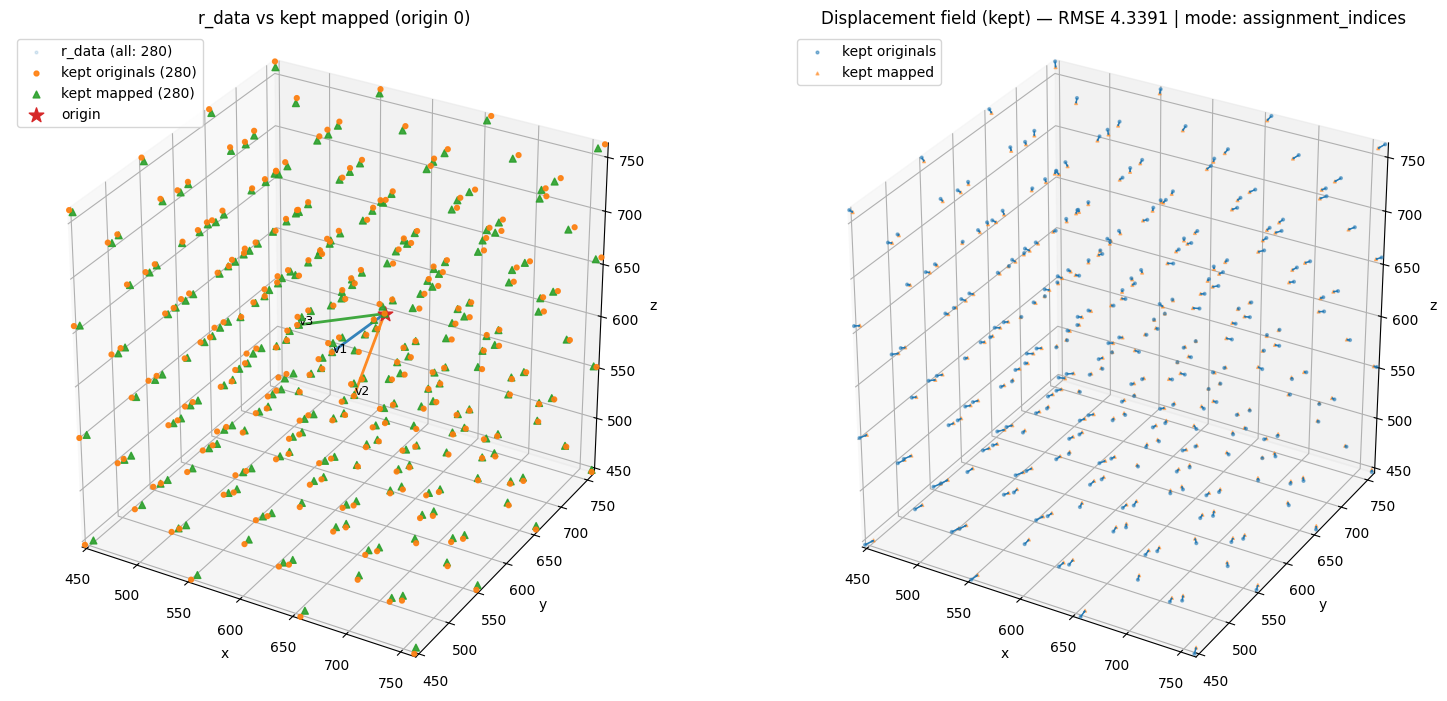

KEPT pairs: 280 | connections: 280 | mode=assignment_indices | mean=0.3555 median=0.3156 max=7.5375


In [31]:
# --- Side-by-side with SYNCHRONIZED camera + vector-field displacements (fast, auto-detect kept IDs) ---
# Expects: r_data, assignments_best, kept_particle_ids
# Optional (only if kept are r_data IDs): ids, matched_pts (or matched_points)
# Optional: fcc_vectors_best, BEST_ORIGIN_ID, o0 (origin)


# --------- inputs & quick prep ---------
if 'matched_pts' not in globals() and 'matched_points' in globals():
    matched_pts = matched_points  # fallback name for  per-id originals

r_data = np.asarray(r_data, float)
assignments = list(assignments_best)
K = len(assignments)

# Pre-extract arrays straight from assignments_best (fast and robust)
matched_points_all = np.array([rec.get("matched_point", rec.get("r_point", [np.nan,np.nan,np.nan]))
                               for rec in assignments], dtype=float)
lattice_points_all = np.array([extract_predicted_from_record(rec)
                               for rec in assignments], dtype=float)
r_ids_all = np.array([get_r_id_from_record(rec) for rec in assignments], dtype=float)

kept_raw = kept_particle_ids
if hasattr(kept_raw, "tolist"):
    kept_raw = kept_raw.tolist()
kept_ints = [int(x) for x in kept_raw]

# Detect: assignment indices vs r_data IDs
assign_idx_hits = sum(0 <= i < K for i in kept_ints)
r_id_set = set(int(x) for x in r_ids_all[np.isfinite(r_ids_all)])
rid_hits = sum((i in r_id_set) for i in kept_ints)

# --------- build P (originals) and Q (mapped) fast ---------
P = None; Q = None
mode = None

if assign_idx_hits >= rid_hits and assign_idx_hits > 0:
    # Route A: kept are assignment indices — fastest and requires no ids/matched_pts
    sel = np.array([i for i in kept_ints if 0 <= i < K], dtype=int)
    # Filter out any records that lack a prediction
    good = np.isfinite(lattice_points_all[sel]).all(axis=1) & np.isfinite(matched_points_all[sel]).all(axis=1)
    sel = sel[good]
    P = matched_points_all[sel]
    Q = lattice_points_all[sel]
    mode = "assignment_indices"
else:
    # Route B: kept are r_data IDs — use ids↔matched_pts
    if 'ids' not in globals() or ('matched_pts' not in globals() and 'matched_points' not in globals()):
        raise ValueError("kept_particle_ids look like r_data IDs but 'ids' and 'matched_pts' are not available.")
    ids_arr = np.asarray(ids)
    if 'matched_pts' not in globals():
        matched_pts = np.asarray(matched_points, float)
    else:
        matched_pts = np.asarray(matched_pts, float)
    id_to_idx = {int(pid): int(i) for i, pid in enumerate(ids_arr) if np.isfinite(pid)}

    P_list, Q_list = [], []
    kept_set = set(kept_ints)
    for rec in assignments:
        rid = get_r_id_from_record(rec)
        if rid is None or rid not in kept_set or rid not in id_to_idx:
            continue
        p_orig = matched_pts[id_to_idx[rid]]
        p_pred = extract_predicted_from_record(rec)
        if p_pred is None:
            continue
        if np.all(np.isfinite(p_orig)) and np.all(np.isfinite(p_pred)):
            P_list.append(p_orig)
            Q_list.append(p_pred)
    if not P_list:
        raise ValueError("No KEPT pairs found via r_data ID path (check ids↔matched_pts alignment).")
    P = np.vstack(P_list); Q = np.vstack(Q_list)
    mode = "r_data_ids"

if P is None or P.size == 0:
    raise ValueError("No KEPT pairs found after auto-detection. "
                     "If  kepts are assignment indices, ensure they’re within [0, len(assignments_best)).")

# --------- displacement + optional thinning ---------
disp_vecs = Q - P
disp_mag  = np.linalg.norm(disp_vecs, axis=1)

MAX_LINES = None  # e.g., 1500 to thin
if MAX_LINES is not None and len(P) > MAX_LINES:
    sel = np.linspace(0, len(P)-1, MAX_LINES, dtype=int)
    P_lines, Q_lines, V_lines = P[sel], Q[sel], disp_vecs[sel]
else:
    P_lines, Q_lines, V_lines = P, Q, disp_vecs
segments = np.stack([P_lines, Q_lines], axis=1)

# --------- basis/origin (optional) ---------
have_basis = 'fcc_vectors_best' in globals()
if have_basis:
    B = np.asarray(fcc_vectors_best, float)
origin = np.asarray(o0, float) if 'o0' in globals() else np.zeros(3)
origin_title = f" (origin {BEST_ORIGIN_ID})" if 'BEST_ORIGIN_ID' in globals() else ""

# --------- figure & plots (same visuals as  synced template) ---------
fig = plt.figure(figsize=(16, 7))
axL = fig.add_subplot(1, 2, 1, projection='3d')
axR = fig.add_subplot(1, 2, 2, projection='3d')

# LEFT: context (faint r_data + kept originals/mapped + origin/basis)
axL.scatter(*r_data.T, s=4, alpha=0.15, label=f"r_data (all: {len(r_data)})")
axL.scatter(*P.T,     s=12, alpha=0.9,  label=f"kept originals ({len(P)})")
axL.scatter(*Q.T,     s=24, alpha=0.9, marker="^", label=f"kept mapped ({len(Q)})")
axL.scatter(*origin, s=120, marker='*', zorder=6, label="origin")
if have_basis:
    for i, name in enumerate(["v1","v2","v3"]):
        p_end = origin + B[i]
        axL.plot([origin[0], p_end[0]], [origin[1], p_end[1]], [origin[2], p_end[2]], linewidth=2.0, alpha=0.9)
        axL.text(*p_end, name, fontsize=9)

# RIGHT: displacement field (quiver + thin lines)
axR.scatter(*P.T, s=4, alpha=0.5, label="kept originals")
axR.scatter(*Q.T, s=4, alpha=0.5, marker="^", label="kept mapped")

USE_QUIVER = True
if USE_QUIVER and len(P_lines) > 0:
    axR.quiver(P_lines[:,0], P_lines[:,1], P_lines[:,2],
               V_lines[:,0], V_lines[:,1], V_lines[:,2],
               length=1.0, normalize=False, linewidth=1, alpha=0.7)

lc = Line3DCollection(segments, linewidths=0.9, alpha=0.9)
axR.add_collection3d(lc)

# Equal aspect
all_pts = np.vstack([r_data, Q]) if Q.size else r_data
set_axes_equal(axL, all_pts)
set_axes_equal(axR, all_pts)

rmse = float(np.sqrt(np.mean(np.sum((Q - P)**2, axis=1))))
axL.set_title(f"r_data vs kept mapped{origin_title}")
axR.set_title(f"Displacement field (kept) — RMSE {rmse:.4f} | mode: {mode}")
for ax in (axL, axR):
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
    ax.legend(loc="upper left", bbox_to_anchor=(0,1))
    ax.set_box_aspect([1,1,1])

# --------- synced view ---------

copy_view(axL, axR)
fig.canvas.mpl_connect('motion_notify_event', on_mouse)
fig.canvas.mpl_connect('button_release_event', on_mouse)
fig.canvas.mpl_connect('draw_event', on_draw)

plt.tight_layout()
plt.show()

# quick summary
if disp_vecs.size:
    print(f"KEPT pairs: {len(P)} | connections: {len(segments)} | mode={mode} | "
          f"mean={disp_vecs.mean():.4f} median={np.median(disp_vecs):.4f} max={disp_vecs.max():.4f}")


In [32]:
ijk_indices, frac = recover_indices(lattice_points_all[sel],
                                    origin_best,
                                    fcc_vectors_best,
                                    lattice_spacing=1)

In [33]:
# --- Compare Top Origins with Continuity Trimming ---
# This runs the full "trimming" logic on the top N candidates to see which one
# actually yields the best/largest continuous cluster and if they agree.

def compare_refined_origins(r_data, df_ranked, origin_artifacts, top_k=5):
    print(f"--- Re-evaluating Top {top_k} Origins with Continuity Trimming ---")
    
    # 1. Identify Top Candidates
    if 'score' in df_ranked.columns:
        candidates = df_ranked.sort_values('score', ascending=False).head(top_k)
    else:
        candidates = df_ranked.sort_values(['matched_percent', 'rmse'], ascending=[False, True]).head(top_k)
    
    refined_results = []
    
    # Global params check
    nn_val = _NN if '_NN' in globals() else None
    tol_val = TOL_FRAC if 'TOL_FRAC' in globals() else 0.25
    
    # 2. Process each candidate
    for idx, row in candidates.iterrows():
        oid = int(row['origin_id'])
        if oid not in origin_artifacts:
            continue
            
        data = origin_artifacts[oid]
        
        # Run continuity analysis
        res = analyze_cluster_continuity(
            data['assignments'],
            origin=data['origin_point'],
            vectors=data['fcc_vectors'],
            neighbor_mode=6,
            nn_distance=nn_val,
            tol_frac=tol_val,
            return_tables=False
        )
        
        refined_results.append({
            'origin_id': oid,
            'kept_particles': len(res['ids_cont']),
            'rmse_kept': res['metrics']['rmse'],
            'assignments_cont': res['assignments_continuous'],
            'rank_score': row.get('score', np.nan)
        })

    # 3. Create Summary Table
    df_compare = pd.DataFrame(refined_results)
    # Sort by kept particles descending for the table
    df_compare = df_compare.sort_values('kept_particles', ascending=False)
    
    print("\n[Refined Comparison Table]")
    print(df_compare[['origin_id', 'kept_particles', 'rmse_kept', 'rank_score']].to_string(index=False))
    
    # --- VISUALIZATION START ---
    if not df_compare.empty:
        fig, ax1 = plt.subplots(figsize=(10, 5))
        
        # Sort by origin ID for cleaner plotting, or by rank if you prefer
        # Here we plot in the order of the table (best yield first)
        plot_df = df_compare.copy()
        x = np.arange(len(plot_df))
        width = 0.35
        
        # Primary Axis: Kept Particles (Bars)
        bars1 = ax1.bar(x - width/2, plot_df['kept_particles'], width, label='Kept Particles', color='skyblue', alpha=0.8)
        ax1.set_xlabel('Origin ID')
        ax1.set_ylabel('Count (Kept Particles)', color='tab:blue')
        ax1.tick_params(axis='y', labelcolor='tab:blue')
        ax1.set_xticks(x)
        ax1.set_xticklabels(plot_df['origin_id'].astype(str))
        
        # Secondary Axis: RMSE (Line/Markers)
        ax2 = ax1.twinx()
        bars2 = ax2.bar(x + width/2, plot_df['rmse_kept'], width, label='RMSE (Kept)', color='salmon', alpha=0.8)
        ax2.set_ylabel('RMSE (lower is better)', color='tab:red')
        ax2.tick_params(axis='y', labelcolor='tab:red')
        
        # Annotate "Best"
        best_idx = 0  # Since we sorted df_compare by kept_particles
        ax1.text(x[best_idx], plot_df.iloc[best_idx]['kept_particles'], ' Best Yield', 
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

        plt.title(f"Comparison of Top {top_k} Origins after Continuity Check")
        
        # Combined legend
        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines + lines2, labels + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
        
        plt.tight_layout()
        plt.show()
    # --- VISUALIZATION END ---

    # 4. Consistency Check (Frame Independence)
    if len(refined_results) > 1:
        best_run = refined_results[0]
        best_id = best_run['origin_id']
        
        print(f"\n[Field Consistency Check] Baseline: Origin {best_id}")
        
        def get_pred_map(assignments):
            mapping = {}
            for rec in assignments:
                rid = get_r_id_from_record(rec)
                pred = extract_predicted_from_record(rec)
                if rid is not None and pred is not None:
                    mapping[rid] = pred
            return mapping

        map_best = get_pred_map(best_run['assignments_cont'])
        
        for other_run in refined_results[1:]:
            other_id = other_run['origin_id']
            map_other = get_pred_map(other_run['assignments_cont'])
            common_ids = set(map_best.keys()) & set(map_other.keys())
            
            if not common_ids:
                print(f"  vs Origin {other_id}: No overlap.")
                continue
                
            diffs = [np.linalg.norm(map_best[rid] - map_other[rid]) for rid in common_ids]
            mean_slip = np.mean(diffs)
            print(f"  vs Origin {other_id}: Overlap={len(common_ids)} | Mean Slip={mean_slip:.4f} | Max Slip={np.max(diffs):.4f}")

    return df_compare


--- Re-evaluating Top 5 Origins with Continuity Trimming ---

[Refined Comparison Table]
 origin_id  kept_particles  rmse_kept  rank_score
         0             280   4.339099    1.000000
        10             280   4.943358    0.904081
        11             280   5.475393    0.819627
         9             280   6.258984    0.695242
         2             280   7.149304    0.553914


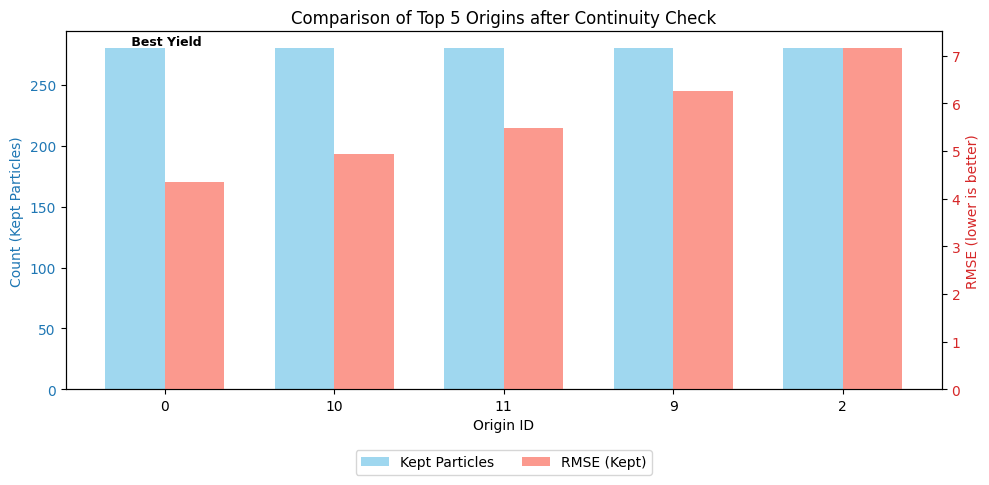


[Field Consistency Check] Baseline: Origin 0
  vs Origin 10: No overlap.
  vs Origin 11: No overlap.
  vs Origin 9: No overlap.
  vs Origin 2: No overlap.


In [34]:
%matplotlib inline
# --- Run it ---
comp_df = compare_refined_origins(r_data, df_ranked, origin_artifacts, top_k=5)

### Final results

In [35]:
print("NN spacing:", first_nn_peak_trim)
print("lattice spacing:", first_nn_peak_trim * np.sqrt(2))
print("origin:", np.asarray(origin_best)) # o0 is the last used verstion, but both should be the same
print("lattice_vectors:", np.asarray(fcc_vectors_best))
print("matched_points (r_data):", len(matched_points_all[sel])) # original points from r_data
print("lattice_points (predicted):", len(lattice_points_all[sel])) # mapped lattice points
print("ijk_indices (recovered):", len(ijk_indices)) # recovered integer indices

NN spacing: 44.5
lattice spacing: 62.93250352560273
origin: [629.85943552 630.03454134 630.19309473]
lattice_vectors: [[-50.81973899   1.06948322 -51.93146447]
 [  0.67903731 -51.35445189 -51.40939453]
 [-52.0814988  -50.67543213  -0.42979984]]
matched_points (r_data): 280
lattice_points (predicted): 280
ijk_indices (recovered): 280


### Save indices to local and global lists

In [36]:
# --- Local/Global index plumbing for origin clusters ---

# Optional: fast mapping via KDTree if SciPy is available; otherwise robust fallback
try:
    from scipy.spatial import cKDTree
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False

# Global registries (create once and reuse)
if 'GLOBAL_INDEX_REGISTRY' not in globals():
    # Maps global_id -> list of {'cluster_id','local_id','ijk'}
    GLOBAL_INDEX_REGISTRY = defaultdict(list)

if 'LOCAL_CLUSTERS' not in globals():
    # Maps cluster_id -> dict with metadata and the local indices dataframe
    LOCAL_CLUSTERS = {}

# Initialize the global mapper for filtered_dataset (call once)
if 'filtered_dataset' not in globals():
    raise NameError("filtered_dataset not found. This registry needs the full dataset array.")
GLOBAL_INDEX_LOOKUP, _mapper_meta = _build_global_index_mapper(filtered_dataset, dec=12, use_kdtree=True, kdtree_tol=1e-8)

# initialize list or table once
if 'CLUSTER_METADATA' not in globals():
    CLUSTER_METADATA = []


In [37]:
# --- Build and register the FIRST origin cluster ---

# Expected from  previous cell:
#   ids_cont: (m,) kept assignment indices (into assignments_best)
#   K_cont:   (m,3) ijk for the kept set
#   matched_cont: (m,3) coords for the kept set (you used matched-or-lattice fallback upstream)
#   origin_best, fcc_vectors_best: current origin/vectors

if 'ids_cont' not in globals() or 'K_cont' not in globals() or 'matched_cont' not in globals():
    raise NameError("Missing required variables (ids_cont, K_cont, matched_cont) from the previous step.")

cluster_id = 0  # This is  picked global origin cluster (canonical reference)
origin_vecs_meta = {
    'origin': np.asarray(origin_best, float),
    'vectors': np.asarray(fcc_vectors_best, float)
}

local_indices_df = add_origin_cluster(
    cluster_id=cluster_id,
    origin_vecs_meta=origin_vecs_meta,
    coords_local=matched_cont,   # or lattice_cont
    ijk_local=K_cont,
    assignment_ids=ids_cont
)

print(f"Local cluster {cluster_id}: {len(local_indices_df)} entries registered.")
display(local_indices_df.head(10))


Local cluster 0: 280 entries registered.


,cluster_id,local_id,global_id,x,y,z,i,j,k,assignment_id
0,0,0,227,629.859436,630.034541,630.193095,0,0,0,0
1,0,1,262,656.557915,656.340349,657.573160,0,0,0,172
2,0,2,303,683.304534,630.573604,683.669887,-1,0,0,21
3,0,3,235,630.262867,683.511172,682.821881,0,-1,0,40
4,0,4,292,682.822062,682.274468,630.314510,0,0,-1,45
5,0,5,170,576.634075,578.246128,629.753855,0,0,1,46
6,0,6,241,630.547090,578.028399,578.131312,0,1,0,51
7,0,7,200,578.721647,631.110718,577.936623,1,0,0,72
8,0,8,259,656.508982,604.055449,604.708538,0,1,0,108
9,0,9,316,708.762138,656.499629,709.874200,-1,0,0,139


In [38]:
# --- Global registry view and usage examples ---

# Exploded table: one row per (global particle, cluster membership)
global_indices_df = global_registry_as_dataframe()

print(f"Global registry has {len(GLOBAL_INDEX_REGISTRY)} particles with at least one local membership recorded.")
display(global_indices_df.head(5))

# Example: attach the registry back onto the filtered dataset coordinates (preview)
_preview_rows = []
for gid in range(len(filtered_dataset)):
    memberships = GLOBAL_INDEX_REGISTRY.get(gid, [])
    _preview_rows.append({
        'global_id': gid,
        'n_memberships': len(memberships),
        'memberships': memberships  # list of dicts: {'cluster_id','local_id','ijk'}
    })
GLOBAL_PARTICLE_TABLE = pd.DataFrame(_preview_rows, columns=['global_id','n_memberships','memberships'])
display(GLOBAL_PARTICLE_TABLE.head(5))

# ---- Adding another origin later ----
# Suppose you compute another cluster with outputs:
#   ids_cont_2, K_cont_2, matched_cont_2, origin_2, vectors_2
# You can register it like this (example code commented out):

# cluster_id_2 = 1
# origin_vecs_meta_2 = {'origin': np.asarray(origin_2, float), 'vectors': np.asarray(vectors_2, float)}
# local_indices_df_2 = add_origin_cluster(
#     cluster_id=cluster_id_2,
#     origin_vecs_meta=origin_vecs_meta_2,
#     coords_local=matched_cont_2,
#     ijk_local=K_cont_2,
#     assignment_ids=ids_cont_2
# )
# display(local_indices_df_2.head(10))

# After adding, GLOBAL_INDEX_REGISTRY will automatically let each particle hold multiple local indices,
# and global_registry_as_dataframe() will reflect both clusters side-by-side.


Global registry has 280 particles with at least one local membership recorded.


,global_id,cluster_id,local_id,i,j,k
0,227,0,0,0,0,0
1,262,0,1,0,0,0
2,303,0,2,-1,0,0
3,235,0,3,0,-1,0
4,292,0,4,0,0,-1


,global_id,n_memberships,memberships
0,0,0,[]
1,1,0,[]
2,2,0,[]
3,3,0,[]
4,4,0,[]


In [39]:
# --- Cluster metadata registry (origin, vectors, NN distance) ---


# --- Record the original (cluster 0) parameters immediately ---
cluster0_meta = add_cluster_metadata(
    cluster_id=0,
    origin=origin_best,
    vectors=fcc_vectors_best,
    nn_distance=first_nn_peak_trim if 'first_nn_peak_trim' in globals() else None,
    n_particles=len(local_indices_df) if 'local_indices_df' in globals() else None
)

display(cluster_metadata_as_dataframe())


Added cluster #0 metadata.


,cluster_id,nn_distance,n_particles,o0,o1,o2,v00,v01,v02,v10,v11,v12,v20,v21,v22
0,0,44.5,280,629.859436,630.034541,630.193095,-50.819739,1.069483,-51.931464,0.679037,-51.354452,-51.409395,-52.081499,-50.675432,-0.4298


## Shift origin and assign indices

In [40]:
def _ensure_array(x, shape=None, dtype=float):
    arr = np.asarray(x, dtype=dtype)
    if shape is not None:
        arr = arr.reshape(shape)
    return arr

def lattice_points_from_indices(origin, vectors, ijk):
    """
    Compute lattice points given origin (3,), vectors (3,3) with rows v1,v2,v3,
    and ijk integer indices (...,3). Returns (...,3) coordinates.
    """
    o = _ensure_array(origin, (3,))
    V = _ensure_array(vectors, (3,3))
    K = _ensure_array(ijk, (-1,3), dtype=int)
    return (o + K @ V).reshape(ijk.shape)

def assign_indices_for_origin(r_points, origin, vectors, nn_distance, tol_frac=0.20, max_k=16):
    """
    For a given origin+vectors, build a local integer grid (ijk) around the cloud
    and try to match each r_point to its nearest lattice site within tolerance.
    Returns a list of dicts: {'matched_point','lattice_point','ijk','origin','vectors','dist'}
    For points not matched, 'ijk' will be None.
    """
    R = _ensure_array(r_points, (-1,3))
    V = _ensure_array(vectors, (3,3))
    o = _ensure_array(origin, (3,))
    Vinv = np.linalg.inv(V)

    # Initial integer guesses via rounding of fractional coords
    frac = (R - o) @ Vinv.T    # (N,3)
    ijk_guess = np.rint(frac).astype(int)

    # Build candidate neighborhoods around each guess
    offsets = np.array([(i,j,k) for i in (-1,0,1) for j in (-1,0,1) for k in (-1,0,1)], int)
    candidates = (ijk_guess[:,None,:] + offsets[None,:,:]).reshape(-1,3)

    # Unique candidates → coordinates → KDTree for fast NN within tolerance
    uniqK, inv_idx = np.unique(candidates, axis=0, return_inverse=True)
    L = lattice_points_from_indices(o, V, uniqK)  # (M,3)
    tree = cKDTree(L)

    # Query each real point against lattice with radius = tol_frac * nn_distance
    radius = float(tol_frac) * float(nn_distance)
    dists, idxs = tree.query(R, k=min(max_k, max(1, L.shape[0])), distance_upper_bound=radius)

    # Build per-point best candidate (closest lattice site)
    matches = []
    if np.ndim(dists) == 1:
        for p, d, idx in zip(R, dists, idxs):
            if np.isfinite(d):
                Kbest = uniqK[idx]
                Lbest = L[idx]
                matches.append(dict(matched_point=p, lattice_point=Lbest, ijk=tuple(Kbest),
                                    origin=o, vectors=V, dist=float(d)))
            else:
                matches.append(dict(matched_point=p, lattice_point=None, ijk=None,
                                    origin=o, vectors=V, dist=np.inf))
    else:
        for p, di, ii in zip(R, dists, idxs):
            mask = np.isfinite(di)
            if np.any(mask):
                j = np.argmin(di[mask])
                jj = np.arange(len(ii))[mask][j]
                Lidx = ii[jj]
                Kbest = uniqK[Lidx]
                Lbest = L[Lidx]
                matches.append(dict(matched_point=p, lattice_point=Lbest, ijk=tuple(Kbest),
                                    origin=o, vectors=V, dist=float(di[mask][j])))
            else:
                matches.append(dict(matched_point=p, lattice_point=None, ijk=None,
                                    origin=o, vectors=V, dist=np.inf))
    return matches

def procedural_origin_shifts(base_origin, vectors, nn_distance, n_shells=2, step_factor=0.25):
    """
    Generate raw candidate origins by offsetting the base origin along primitive vectors.
    These are *pre-snap* candidates; snapping to the dataset happens in the loop cell.
    """
    V = _ensure_array(vectors, (3,3))
    steps = np.linspace(-n_shells, n_shells, 2*n_shells+1) * float(step_factor)
    shifts = []
    for a in steps:
        for b in steps:
            for c in steps:
                shifts.append(base_origin + a*V[0] + b*V[1] + c*V[2])
    return shifts

def _snap_origin_to_dataset(candidate_origin, dataset, nn_distance, max_frac=0.75):
    """
    Snap a candidate origin to the *nearest* point in the dataset.
    If the nearest point is farther than max_frac * nn_distance, return the original candidate.
    Returns: (snapped_origin, snap_dist, snap_index or None, did_snap: bool)
    """
    R = _ensure_array(dataset, (-1,3))
    tree = cKDTree(R)
    d, idx = tree.query(_ensure_array(candidate_origin, (3,)))
    if np.isfinite(d) and (d <= max_frac * float(nn_distance)):
        return R[idx], float(d), int(idx), True
    return np.asarray(candidate_origin, float).reshape(3), float(d), int(idx) if np.isfinite(d) else None, False


def _basis_close(o1, V1, o2, V2, tol_o=1e-6, tol_V=1e-6):
    try:
        o1 = np.asarray(o1, float).reshape(3); o2 = np.asarray(o2, float).reshape(3)
        V1 = np.asarray(V1, float).reshape(3,3); V2 = np.asarray(V2, float).reshape(3,3)
    except Exception:
        return False
    return (np.linalg.norm(o1 - o2) <= tol_o) and (np.linalg.norm((V1 - V2).ravel()) <= tol_V)

class ClusterSequence:
    """
    Maintains [(origin, V)] where index == cluster_id.
    cid=0 is the initial basis; new bases are appended when first seen.
    """
    def __init__(self, origin0, V0, tol_o=1e-6, tol_V=1e-6):
        self.tol_o = tol_o
        self.tol_V = tol_V
        self.seq = []
        if origin0 is not None and V0 is not None:
            o0 = np.asarray(origin0, float).reshape(3)
            V0 = np.asarray(V0, float).reshape(3,3)
            self.seq.append((o0, V0))

    def get_or_add(self, o, V):
        """Return cid for (o,V); append if new."""
        if o is None or V is None:
            return None
        o = np.asarray(o, float).reshape(3)
        V = np.asarray(V, float).reshape(3,3)
        for cid, (o0, V0) in enumerate(self.seq):
            if _basis_close(o, V, o0, V0, self.tol_o, self.tol_V):
                return cid
        self.seq.append((o, V))
        return len(self.seq) - 1

def loop_assign_until_complete(dataset,
                               initial_origin,
                               vectors,
                               nn_distance,
                               tol_frac=0.20,
                               n_shells=2,
                               max_rounds=12,
                               step_factor=0.25,
                               snap_frac=0.75,
                               dedupe_tol_frac=1e-3):
    """
    Procedurally shift the origin, *snapping each candidate origin to the nearest dataset point*
    before running the per-origin assignment.

    New behavior:
      - Each raw shifted origin is snapped to nearest data point within snap_frac * nn_distance.
      - Duplicated snapped origins (within dedupe_tol_frac * nn_distance) are skipped.

    Returns:
      best : list[dict]           → per-point *best* (closest) assignment across rounds
      assignment_history : list   → per-round matches
    """
    R = _ensure_array(dataset, (-1, 3))
    V0 = np.asarray(vectors, float).reshape(3, 3)
    o0 = np.asarray(initial_origin, float).reshape(3)

    cluster_seq = ClusterSequence(origin0=o0, V0=V0, tol_o=1e-6, tol_V=1e-6)

    best = [dict(matched_point=p,
                 lattice_point=None,
                 ijk=None,
                 dist=np.inf,
                 cluster_id=None,
                 origin_used=o0,
                 vectors_used=V0,
                 particle_id=i)
            for i, p in enumerate(R)]

    # Build ordered list of raw candidate origins (pre-snap)
    raw_origins = [o0] + procedural_origin_shifts(o0, V0, nn_distance,
                                                  n_shells=n_shells,
                                                  step_factor=step_factor)

    # Prepare sets to avoid re-running the same snapped origin
    seen_keys = set()
    def _key_for_origin(o):
        # Scale by nn_distance then round to dedupe_tol_frac
        scale = max(1e-12, float(nn_distance))
        q = np.round(np.asarray(o, float)/scale, int(np.ceil(-np.log10(max(1e-12, dedupe_tol_frac)))))
        return tuple(q.tolist())

    assignment_history = []
    rounds = 0

    for o_raw in raw_origins:
        # Snap to nearest dataset point (within radius); fall back to raw if too far
        o_snap, snap_dist, snap_idx, did_snap = _snap_origin_to_dataset(o_raw, R, nn_distance, max_frac=snap_frac)

        # Skip if we've effectively seen this snapped origin
        key = _key_for_origin(o_snap)
        if key in seen_keys:
            continue
        seen_keys.add(key)

        rounds += 1

        # Determine cluster id for the snapped origin
        cid = cluster_seq.get_or_add(o_snap, V0)

        # Assign with the snapped origin
        matches = assign_indices_for_origin(R, o_snap, V0, nn_distance, tol_frac=tol_frac)

        # Tag records (also log snap metadata)
        for i, m in enumerate(matches):
            m['cluster_id']    = cid
            m['origin_used']   = o_snap
            m['vectors_used']  = V0
            m['particle_id']   = i
            m['origin_snapped'] = did_snap
            m['origin_snap_dist'] = snap_dist
            m['origin_snap_index'] = snap_idx

        assignment_history.append(matches)

        # Keep the closest index assignment per point seen so far
        improved = 0
        for i, m in enumerate(matches):
            if m.get('ijk', None) is None:
                continue
            if m.get('dist', np.inf) < best[i].get('dist', np.inf):
                best[i] = m
                improved += 1

        # Early stops
        assigned_now = sum(1 for rec in best if rec.get('ijk', None) is not None)
        if assigned_now == len(R):
            break
        if rounds >= max_rounds:
            break

    return best, assignment_history

def build_index_choice_for_minimization(assignments_per_point):
    """
    For each point, return the ijk that is closest to the actual coordinate.
    Input is the 'best' list from loop_assign_until_complete.
    Output:
      ijk_array: (N,3) int with -1 where unassigned
      matched_points: (N,3)
      lattice_points: (N,3) or NaN
    """
    N = len(assignments_per_point)
    ijk = np.full((N,3), -1, dtype=int)
    P  = np.full((N,3), np.nan, dtype=float)
    Q  = np.full((N,3), np.nan, dtype=float)
    for i, rec in enumerate(assignments_per_point):
        p = np.asarray(rec['matched_point'], float)
        P[i] = p
        if rec['ijk'] is not None and np.isfinite(rec['dist']):
            ijk[i] = np.asarray(rec['ijk'], int)
            Q[i] = np.asarray(rec['lattice_point'], float)
    return ijk, P, Q

In [41]:
# --- Execute loop to cover all particles and prepare indices for 12-param minimization ---

origin_shift_factor = 0.5   # e.g., 0.1, 0.25, 0.5
_tol = 0.25 if "tol_frac" not in globals() else float(tol_frac)

best_assignments, assignment_history = loop_assign_until_complete(
    dataset=np.asarray(filtered_dataset, float),
    initial_origin=np.asarray(origin_best, float),
    vectors=np.asarray(fcc_vectors_best, float),
    nn_distance=MATCH_LEN if 'MATCH_LEN' in globals() else first_nn_peak_trim,
    tol_frac=_tol,
    n_shells=2,
    max_rounds=64,
    step_factor=float(origin_shift_factor),
    snap_frac=0.75,          # ← fraction of shell distance allowed for snapping
    dedupe_tol_frac=1e-3,    # ← consider snapped origins equal if within 0.1% of shell distance
)

ijk_chosen, matched_pts, lattice_pts = build_index_choice_for_minimization(best_assignments)

assignments_procedural_best = best_assignments
ijk_minimize = ijk_chosen
matched_points_minimize = matched_pts
lattice_points_minimize = lattice_pts

print(f"Assigned {np.sum(ijk_minimize[:,0] != -1)} / {ijk_minimize.shape[0]} points.")

Assigned 374 / 428 points.


### Final variables

In [42]:
def _arr3(x):
    if x is None: return None
    a = np.asarray(x, float).reshape(-1)
    return a[:3] if a.size >= 3 else None

def _arr33(x):
    if x is None: return None
    A = np.asarray(x, float).reshape(-1)
    if A.size >= 9:
        return np.asarray(x, float).reshape(3,3)
    return None

def _first_present(d, keys, default=None):
    for k in keys:
        if k in d:
            v = d[k]
            if v is not None:
                return v
    return default

def _resolve_origin_vectors(rec, cid, cluster_basis, default_o, default_V):
    o = _arr3(_first_present(rec, ('origin_used','origin','o','r0','r_0'), default=default_o))
    V = _arr33(_first_present(rec, ('vectors_used','basis','V','E','E_global'), default=default_V))
    if (o is None or V is None) and cluster_basis is not None and cid is not None:
        pair = cluster_basis.get(cid)
        if pair and isinstance(pair, (tuple, list)) and len(pair) == 2:
            o_cb, V_cb = pair
            if o is None: o = _arr3(o_cb)
            if V is None: V = _arr33(V_cb)
    return o, V

def _predict_from_ijk(origin, V, ijk):
    """
    Predict lattice point from origin + lattice vectors and integer index.
    Assumes V rows are t1,t2,t3 (common in  notebook); hence use V.T @ ijk.
    """
    o = np.asarray(origin, float).reshape(3)
    M = np.asarray(V, float).reshape(3,3)
    j = np.asarray(ijk, float).reshape(3)
    return o + M.T.dot(j)

def _dedup_key(ijk, origin, V, cluster_id, decimals=6):
    """Hashable key for de-duplication per particle, rounding floats to 'decimals'."""
    ijk_t = tuple(int(x) for x in np.asarray(ijk, int).reshape(3))
    o_t   = tuple(np.round(np.asarray(origin, float).reshape(3), decimals))
    V_t   = tuple(np.round(np.asarray(V, float).reshape(9), decimals))
    c_t   = None if cluster_id is None else int(cluster_id)
    return (ijk_t, o_t, V_t, c_t)

def _build_flat_records(block):
    """Normalize any assignment source to a list[dict] of records."""
    if block is None: 
        return []
    if isinstance(block, dict) and 'records' in block and isinstance(block['records'], list):
        return [r for r in block['records'] if isinstance(r, dict)]
    if isinstance(block, dict): 
        return [block]
    if isinstance(block, list):
        return [r for r in block if isinstance(r, dict)]
    return []


def build_particle_registry_dict(
    original_points,
    assignments_sources,
    cluster_basis=None,
    default_origin=None,
    default_vectors=None,
    match_tolerance=None,
    dedup_decimals=6,
    treat_neg1_cluster_as_unassigned=True,
    assignments_per_cluster=None,      # <-- NEW: pass the dict here
    infer_cluster_from_basis=True,     # <-- NEW: try to infer from (origin,V)
    basis_match_tol=(1e-6, 1e-6)       # <-- (origin_tol, vector_tol) in absolute units
):
    """
    Returns
    -------
    registry : dict[int, list[dict]]
        pid -> list of unique assignment entries:
        { 'cluster_id', 'ijk', 'origin', 'V', 'matched_point', 'predicted_point', 'residual' }
    ...
    """

    P = np.asarray(original_points, float).reshape(-1,3)
    N = P.shape[0]

    # --- prepare KDTree and tolerance (unchanged) ---
    try:
        from scipy.spatial import cKDTree as KDTree
    except Exception:
        from sklearn.neighbors import KDTree
    tree = KDTree(P)
    if match_tolerance is None:
        dists, _ = tree.query(P, k=2)
        nn = dists[:, 1]
        typical = np.median(nn) if np.isfinite(nn).any() else 1.0
        match_tolerance = max(1e-7, 1e-6 * typical)

    # --- flatten generic sources as before ---
    flat = []
    if not isinstance(assignments_sources, list):
        assignments_sources = [assignments_sources]
    for block in assignments_sources:
        flat.extend(_build_flat_records(block))

    # --- NEW: add records from assignments_per_cluster WITH their cluster id preserved ---
    if isinstance(assignments_per_cluster, dict):
        for cid, recs in assignments_per_cluster.items():
            for rec in _build_flat_records(recs):
                # attach the cluster id if the record doesn't already have one
                if 'cluster_id' not in rec or rec['cluster_id'] is None:
                    rec = dict(rec)           # shallow copy so we don't mutate upstream
                    rec['cluster_id'] = cid
                flat.append(rec)

    default_o = _arr3(default_origin)
    default_V = _arr33(default_vectors)

    # --- helper: infer cluster by comparing (origin,V) to cluster_basis ---
    def _infer_cluster_id_from_basis(o, V):
        if not infer_cluster_from_basis or not isinstance(cluster_basis, dict):
            return None
        if o is None or V is None:
            return None
        o_tol, V_tol = basis_match_tol
        o = np.asarray(o, float).reshape(3)
        V = np.asarray(V, float).reshape(3,3)
        best = None
        best_err = np.inf
        for cid, pair in cluster_basis.items():
            try:
                o_cb, V_cb = pair
                o_cb = np.asarray(o_cb, float).reshape(3)
                V_cb = np.asarray(V_cb, float).reshape(3,3)
            except Exception:
                continue
            # simple absolute-error checks; you can tighten/loosen as needed
            o_err = float(np.linalg.norm(o - o_cb))
            V_err = float(np.linalg.norm((V - V_cb).ravel()))
            if o_err <= o_tol and V_err <= V_tol:
                err = o_err + V_err
                if err < best_err:
                    best_err = err
                    best = cid
        return best

    registry = defaultdict(list)
    seen_keys_per_pid = defaultdict(set)

    for rec in flat:
        # --- resolve pid (unchanged) ---
        pid = _first_present(rec, ('particle_id','global_id','id','pid'))
        mp  = _arr3(_first_present(rec, ('matched_point','r_point','data_point','P')))
        if pid is None:
            if mp is None:
                continue
            d, idx = tree.query(np.asarray(mp, float).reshape(1,-1), k=1)
            d = float(np.ravel(d)[0]); idx = int(np.ravel(idx)[0])
            if d > match_tolerance:
                continue
            pid = idx
        else:
            pid = int(pid)

        # --- ijk (unchanged) ---
        ijk = _first_present(rec, ('ijk','ijk_indices','local_index','index','k'))
        if ijk is None:
            continue
        ijk = tuple(int(x) for x in np.asarray(ijk, int).reshape(-1)[:3])
        if len(ijk) != 3:
            continue

        # --- cluster (now with inference and per-cluster override) ---
        cid = _first_present(rec, ('cluster_id','cid','cluster','label'))
        if cid is not None:
            try: cid = int(cid)
            except Exception: cid = None

        # origin/vectors (same resolver)
        o, V = _resolve_origin_vectors(rec, cid, cluster_basis, default_o, default_V)
        # If cluster is still missing, try to infer from basis
        if cid is None:
            cid = _infer_cluster_id_from_basis(o, V)

        # If we still don't have O or V, skip (can relax if you want)
        if o is None or V is None:
            continue

        # matched point fallback
        if mp is None:
            mp = P[pid]

        # predicted & residual
        try:
            pred = _predict_from_ijk(o, V, ijk)
            resid = float(np.linalg.norm(np.asarray(mp) - np.asarray(pred)))
        except Exception:
            pred = None
            resid = np.nan

        # de-dup and store
        dkey = _dedup_key(ijk, o, V, cid, decimals=dedup_decimals)
        if dkey in seen_keys_per_pid[pid]:
            continue
        seen_keys_per_pid[pid].add(dkey)

        registry[pid].append({
            'cluster_id': cid,
            'ijk': ijk,
            'origin': np.asarray(o, float),
            'V': np.asarray(V, float),
            'matched_point': np.asarray(mp, float),
            'predicted_point': np.asarray(pred, float) if pred is not None else None,
            'residual': resid,
        })

    # --- remainder (unassigned sets, chosen entry) unchanged ---
    all_pids = set(range(N))
    pids_with_any = set(registry.keys())
    unassigned_particles = sorted(all_pids - pids_with_any)

    unassigned_to_cluster = {}
    for pid, entries in registry.items():
        bad = []
        for e in entries:
            if e['cluster_id'] is None:
                bad.append(e)
            elif treat_neg1_cluster_as_unassigned and int(e['cluster_id']) == -1:
                bad.append(e)
        if bad:
            unassigned_to_cluster[pid] = bad

    chosen_for_minimization = {}
    for pid, entries in registry.items():
        if not entries: 
            continue
        best = min(entries, key=lambda d: (np.nan_to_num(d['residual'], nan=np.inf)))
        chosen_for_minimization[pid] = best

    return dict(registry), unassigned_particles, unassigned_to_cluster, chosen_for_minimization


def build_minimization_arrays_from_choice(chosen, original_points):
    """
    Build ijk_minimize, matched_points_minimize, lattice_points_minimize from chosen entries.
    Unassigned rows get ijk = (-1,-1,-1) and NaNs for points.
    """
    P = np.asarray(original_points, float).reshape(-1,3)
    N = P.shape[0]
    ijk_min = np.full((N,3), -1, dtype=int)
    r_min   = np.full((N,3), np.nan, dtype=float)
    q_min   = np.full((N,3), np.nan, dtype=float)

    for pid, entry in chosen.items():
        ijk_min[pid] = np.asarray(entry['ijk'], int).reshape(3)
        r_min[pid]   = np.asarray(entry['matched_point'], float).reshape(3)
        if entry['predicted_point'] is not None:
            q_min[pid] = np.asarray(entry['predicted_point'], float).reshape(3)
        else:
            # compute if missing
            q_min[pid] = _predict_from_ijk(entry['origin'], entry['V'], entry['ijk'])

    return ijk_min, r_min, q_min

def _basis_close(o1, V1, o2, V2, tol_o=1e-6, tol_V=1e-6):
    try:
        o1 = np.asarray(o1, float).reshape(3); o2 = np.asarray(o2, float).reshape(3)
        V1 = np.asarray(V1, float).reshape(3,3); V2 = np.asarray(V2, float).reshape(3,3)
    except Exception:
        return False
    return (np.linalg.norm(o1 - o2) <= tol_o) and (np.linalg.norm((V1 - V2).ravel()) <= tol_V)

def build_cluster_sequence(initial_origin, initial_vectors, sources_in_order, tol_origin=1e-6, tol_vectors=1e-6):
    """
    Build the canonical cluster sequence:
      - cluster 0 = (initial_origin, initial_vectors)
      - cluster 1,2,... = each new (origin, V) in the order first seen in sources_in_order
    Non-invasive: just returns a list [(origin, V), ...]
    """
    seq = []
    if initial_origin is not None and initial_vectors is not None:
        seq.append((np.asarray(initial_origin, float).reshape(3),
                    np.asarray(initial_vectors, float).reshape(3,3)))
    # scan sources in order and append new bases
    for src in sources_in_order:
        for rec in _build_flat_records(src):
            o = _arr3(_first_present(rec, ('origin_used','origin','o','r0','r_0')))
            V = _arr33(_first_present(rec, ('vectors_used','basis','V','E','E_global')))
            if o is None or V is None:
                continue
            if not any(_basis_close(o, V, o0, V0, tol_origin, tol_vectors) for (o0, V0) in seq):
                seq.append((np.asarray(o, float).reshape(3), np.asarray(V, float).reshape(3,3)))
    return seq

def assign_cluster_ids_inplace(particle_registry_dict, cluster_sequence, tol_origin=1e-5, tol_vectors=1e-5, overwrite_existing=True):
    """
    In-place pass over particle_registry_dict to set e['cluster_id'] based on the cluster_sequence.
    - Does NOT filter or drop any entries (so  counts stay the same).
    - If overwrite_existing=False, only fills when cluster_id is None.
    """
    for pid, entries in particle_registry_dict.items():
        for e in entries:
            if (not overwrite_existing) and (e.get('cluster_id') is not None):
                continue
            o = e.get('origin', None); V = e.get('V', None)
            if o is None or V is None:
                continue
            cid = None
            for k, (o0, V0) in enumerate(cluster_sequence):
                if _basis_close(o, V, o0, V0, tol_origin, tol_vectors):
                    cid = k
                    break
            # set (or leave as-is if no match)
            e['cluster_id'] = cid


In [43]:
# 1) use the exact dataset used in the loop
_original_points = np.asarray(filtered_dataset, float)

# 2) collect sources (include the procedural loop results)
sources = []
for name in ("assignments_best", "assignments_per_cluster",
             "best_assignments", "assignments_procedural_best"):
    if name in globals() and globals()[name] is not None:
        obj = globals()[name]
        if name == "assignments_per_cluster" and isinstance(obj, dict):
            sources.extend(obj.values())
        else:
            sources.append(obj)

# 3) defaults & tolerance
_default_o = globals().get('origin_best', None)
_default_V = globals().get('fcc_vectors_best', globals().get('E_global', None))

_nn = None
for nm in ("first_nn_peak_trim_2","first_nn_peak_trim","nn_distance","first_nn_peak"):
    if nm in globals():
        _nn = float(globals()[nm]); break
if _nn is None: _nn = 1.0
_tol_snap = 0.05 * _nn   # 5% NN is a good, practical default

# 4) build dict registry (de-duplicated)
particle_registry_dict, particles_with_no_assignments, unassigned_to_cluster, chosen_per_particle = \
    build_particle_registry_dict(
        original_points=_original_points,
        assignments_sources=sources,
        cluster_basis=globals().get('cluster_basis', None),
        default_origin=_default_o,
        default_vectors=_default_V,
        match_tolerance=_tol_snap,
        dedup_decimals=6,
        treat_neg1_cluster_as_unassigned=True,
        assignments_per_cluster=globals().get('assignments_per_cluster', None),  # <-- pass the dict
        infer_cluster_from_basis=True,                                           # <-- enable inference
        basis_match_tol=(1e-4, 1e-3)                                             # <-- practical tolerances
    )


# Build the sequence from the loop's history (order matters!)
sources_in_order = []
if 'assignment_history' in globals() and assignment_history is not None:
    sources_in_order.append(assignment_history)
for name in ("best_assignments", "assignments_procedural_best",
             "assignments_best", "assignments_per_cluster"):
    if name in globals() and globals()[name] is not None:
        sources_in_order.append(globals()[name])

initial_o = globals().get('origin_best', None)
initial_V = globals().get('fcc_vectors_best', globals().get('E_global', None))

cluster_sequence = build_cluster_sequence(
    initial_origin=initial_o,
    initial_vectors=initial_V,
    sources_in_order=sources_in_order,
    tol_origin=1e-6, tol_vectors=1e-6
)

# Apply cluster ids in-place (no filtering, preserves coverage)
assign_cluster_ids_inplace(
    particle_registry_dict,
    cluster_sequence,
    tol_origin=1e-5, tol_vectors=1e-5,
    overwrite_existing=True
)

# Optional: quick stats
total_entries = sum(len(v) for v in particle_registry_dict.values())
with_cluster  = sum(sum(1 for e in v if e.get('cluster_id') is not None) for v in particle_registry_dict.values())
print(f"[cluster pass] sequence length: {len(cluster_sequence)} (cid 0..{len(cluster_sequence)-1})")
print(f"[cluster pass] entries with cluster_id set: {with_cluster} / {total_entries}")


print(f"[registry] particles with ≥1 assignment: {len(particle_registry_dict)} / {_original_points.shape[0]}")
print(f"[registry] particles with NO assignments: {len(particles_with_no_assignments)}")
print(f"[registry] particles with assignments but UNASSIGNED cluster: {len(unassigned_to_cluster)}")

# (Optional) peek at one particle's entries with potential duplicates removed
# Example: show first pid that has >1 entry
for _pid, entries in particle_registry_dict.items():
    if len(entries) > 1:
        print(f"Example pid {_pid}: {len(entries)} unique entries (after de-dup)")
        break

# 5) hook into  12-parameter minimization: pick best ijk per particle
ijk_minimize, matched_points_minimize, lattice_points_minimize = \
    build_minimization_arrays_from_choice(chosen_per_particle, _original_points)

# 6) warn about remaining unassigned (ijk = -1)
n_unassigned = int(np.sum(ijk_minimize[:,0] == -1))
if n_unassigned > 0:
    print(f"Warning: {n_unassigned} points remain unassigned (ijk=-1). They will be skipped in the fit.")


[cluster pass] sequence length: 3 (cid 0..2)
[cluster pass] entries with cluster_id set: 708 / 708
[registry] particles with ≥1 assignment: 428 / 428
[registry] particles with NO assignments: 0
[registry] particles with assignments but UNASSIGNED cluster: 280
Example pid 227: 2 unique entries (after de-dup)


In [44]:
# --- Compare unassigned counts & explain differences ---

# Locate the two ijk arrays robustly
ijk_other = None  # from  earlier/“other” version
for nm in ("ijk_subset", "ijk_chosen", "ijk_minimize_other"):
    if nm in globals():
        ijk_other = np.asarray(globals()[nm], int)
        break

ijk_new = None  # from the dict-based registry path
for nm in ("ijk_minimize",):
    if nm in globals():
        ijk_new = np.asarray(globals()[nm], int)
        break

if ijk_other is None or ijk_new is None:
    raise RuntimeError("Need both ijk arrays available: ijk_other (old) and ijk_new (dict-based).")

if ijk_other.shape != ijk_new.shape:
    raise ValueError(f"Shape mismatch: old {ijk_other.shape} vs new {ijk_new.shape}")

N = ijk_other.shape[0]
un_other = set(np.where(ijk_other[:,0] == -1)[0].tolist())
un_new   = set(np.where(ijk_new[:,0]   == -1)[0].tolist())

print(f"Unassigned (other): {len(un_other)} / {N}")
print(f"Unassigned (new)  : {len(un_new)} / {N}")

# Who moved categories?
gained_assign = sorted(un_other - un_new)   # assigned now, unassigned before
lost_assign   = sorted(un_new - un_other)   # unassigned now, assigned before

print(f"Gained assignments in new path: {len(gained_assign)}")
print(f"Lost assignments in new path  : {len(lost_assign)}")

# Helper to summarize a chosen entry (from dict-based registry)
def _summ(pid):
    d = globals().get("chosen_per_particle", {})
    e = d.get(pid)
    if not e: 
        return {"has_entry": False}
    out = {
        "has_entry": True,
        "cluster_id": e.get("cluster_id"),
        "ijk": tuple(map(int, e.get("ijk"))) if e.get("ijk") is not None else None,
        "residual": float(e.get("residual")) if e.get("residual") is not None else None
    }
    return out

# Peek at differences (first few)
print("\nExamples that became ASSIGNED in the new path:")
for pid in gained_assign[:12]:
    print(f" pid={pid} → new ijk={tuple(ijk_new[pid])}, summary={_summ(pid)}")

print("\nExamples that became UNASSIGNED in the new path:")
for pid in lost_assign[:12]:
    print(f" pid={pid} → old ijk={tuple(ijk_other[pid])}, new summary={_summ(pid)}")

# Categorize the reasons for 'lost' by checking if the old assignment was reconstructable
why_lost = {"missing_origin_V": 0, "non_integer_or_bad_ijk": 0, "snap_failed": 0, "other": 0}
for pid in lost_assign:
    # If we have a chosen entry, it's not actually lost; skip
    if pid in globals().get("chosen_per_particle", {}):
        continue
    # If the old ijk wasn't valid
    old_ijk = ijk_other[pid]
    if old_ijk.shape != (3,) or np.any(old_ijk == -1):
        why_lost["non_integer_or_bad_ijk"] += 1
        continue
    # If there was no record with origin/V for this pid+ijk in sources, it became unassignable
    why_lost["missing_origin_V"] += 1  # coarse bucket; refine below if needed

print("\nRough reasons for 'lost' (coarse classification):", why_lost)


Unassigned (other): 54 / 428
Unassigned (new)  : 54 / 428
Gained assignments in new path: 0
Lost assignments in new path  : 0

Examples that became ASSIGNED in the new path:

Examples that became UNASSIGNED in the new path:

Rough reasons for 'lost' (coarse classification): {'missing_origin_V': 0, 'non_integer_or_bad_ijk': 0, 'snap_failed': 0, 'other': 0}


## Final final all particles with all indices

In [45]:
# Cleanup + global index unification for particle_registry_dict

# 1) Deduplicate registry: drop entries that are identical in (cluster_id, ijk, origin, V)
def deduplicate_particle_registry_dict(reg, atol=1e-8, rtol=0.0):
    new_reg = {}
    removed = 0
    for pid, entries in reg.items():
        uniq = []
        for e in entries:
            cid = int(e["cluster_id"])
            ijk = tuple(np.asarray(e["ijk"], int).tolist())
            o   = np.asarray(e["origin"], float).reshape(3)
            V   = np.asarray(e["V"], float).reshape(3,3)
            is_dup = False
            for u in uniq:
                if cid != u["cluster_id"]:          continue
                if ijk != u["ijk"]:                  continue
                if not np.allclose(o, u["origin"], rtol=rtol, atol=atol): continue
                if not np.allclose(V, u["V"], rtol=rtol, atol=atol):      continue
                is_dup = True
                break
            if not is_dup:
                uniq.append({"cluster_id": cid, "ijk": ijk, "origin": o, "V": V,
                             "matched_point": e.get("matched_point", None),
                             "predicted_point": e.get("predicted_point", None),
                             "residual": e.get("residual", None)})
            else:
                removed += 1
        new_reg[int(pid)] = uniq
    return new_reg, removed

# 2) Build a simple cluster basis directly from the registry (first seen per cluster)
def build_cluster_basis(reg):
    basis = {}
    for entries in reg.values():
        for e in entries:
            cid = int(e["cluster_id"])
            if cid not in basis:
                basis[cid] = {
                    "origin": np.asarray(e["origin"], float).reshape(3),
                    "V":      np.asarray(e["V"], float).reshape(3,3)
                }
    return basis

# 3) Unify indices into global frame of cluster 0
def unify_global_indices_simple(reg, reference_cid=0, orientation="rows", tol_index=0.25, compute_dist=True):
    """
    orientation: 'rows' means V rows are t1,t2,t3 and r = ijk @ V
                 'cols' means V columns are t1,t2,t3 and r = V @ ijk
    """
    basis = build_cluster_basis(reg)
    if reference_cid not in basis:
        raise KeyError(f"Cluster {reference_cid} not found in registry; cannot set global frame.")

    o0 = basis[reference_cid]["origin"]
    V0 = basis[reference_cid]["V"]
    M0 = V0.T if orientation == "rows" else V0
    M0_inv = np.linalg.inv(M0)

    all_cids = sorted(basis.keys())

    def to_real(o, V, k):
        k = np.asarray(k, float).reshape(3)
        if orientation == "rows":
            return o + (k @ V)
        else:
            return o + (V @ k)

    def round_with_tol(x, tol):
        xr = np.rint(x).astype(int)
        ok = np.abs(x - xr) <= tol
        return xr, ok

    rows, conflicts = [], []
    for pid, entries in reg.items():
        per_cluster = {}
        for e in entries:
            cid = int(e["cluster_id"])
            ijk = np.asarray(e["ijk"], float).reshape(3)
            o   = np.asarray(e["origin"], float).reshape(3)
            V   = np.asarray(e["V"], float).reshape(3,3)

            r_loc = to_real(o, V, ijk)
            kglob_cont = M0_inv @ (r_loc - o0)
            kglob_round, ok_mask = round_with_tol(kglob_cont, tol_index)
            r_recon = o0 + (M0 @ kglob_round)

            per_cluster[cid] = {
                "ijk_global": tuple(kglob_round.tolist()),
                "ok_axis": ok_mask,
                "r_global_recon": r_recon
            }

        # compare across clusters for this particle
        cids_here = sorted(per_cluster.keys())
        vals = [per_cluster[c]["ijk_global"] for c in cids_here]
        all_equal = len(set(vals)) <= 1

        max_pairwise = None
        if compute_dist and len(cids_here) >= 2:
            R = np.vstack([per_cluster[c]["r_global_recon"] for c in cids_here])
            dmax = 0.0
            for i in range(len(R)):
                for j in range(i+1, len(R)):
                    d = float(np.linalg.norm(R[i]-R[j]))
                    if d > dmax: dmax = d
            max_pairwise = dmax

        if not all_equal:
            conflicts.append(int(pid))

        row = {"particle_id": int(pid), "indices_match": bool(all_equal), "max_pairwise_dist_globalRS": max_pairwise}
        for c in all_cids:
            row[f"ijk_global_from_c{c}"] = per_cluster[c]["ijk_global"] if c in per_cluster else None
        for c in cids_here:
            row[f"c{c}_round_ok"] = bool(np.all(per_cluster[c]["ok_axis"]))
        rows.append(row)

    df = pd.DataFrame(rows).sort_values(["indices_match","particle_id"], ascending=[True, True]).reset_index(drop=True)
    return df, conflicts


In [46]:
particle_registry_dict, n_removed = deduplicate_particle_registry_dict(particle_registry_dict)
print(f"Deduplicated {n_removed} duplicate entries.")

df_global_unified, conflict_list = unify_global_indices_simple(
    particle_registry_dict,
    reference_cid=0,       # global frame = cluster 0
    orientation="rows",    # set to "cols" if  V uses columns as basis vectors
    tol_index=0.2,
    compute_dist=True
)

print(f"Total particles unified: {len(df_global_unified)} | Conflicts: {len(conflict_list)}")

Deduplicated 99 duplicate entries.
Total particles unified: 428 | Conflicts: 172


In [47]:
particle_registry_dict

{227: [{'cluster_id': 0,
   'ijk': (0, 0, 0),
   'origin': array([629.85943552, 630.03454134, 630.19309473]),
   'V': array([[-50.81973899,   1.06948322, -51.93146447],
          [  0.67903731, -51.35445189, -51.40939453],
          [-52.0814988 , -50.67543213,  -0.42979984]]),
   'matched_point': array([629.85943552, 630.03454134, 630.19309473]),
   'predicted_point': array([629.85943552, 630.03454134, 630.19309473]),
   'residual': 0.0}],
 355: [{'cluster_id': 0,
   'ijk': (-3, 1, 1),
   'origin': array([629.85943552, 630.03454134, 630.19309473]),
   'V': array([[-50.81973899,   1.06948322, -51.93146447],
          [  0.67903731, -51.35445189, -51.40939453],
          [-52.0814988 , -50.67543213,  -0.42979984]]),
   'matched_point': array([735.8054177 , 525.2055059 , 736.01448386]),
   'predicted_point': array([730.91619099, 524.79620766, 734.14829376]),
   'residual': 5.249259793332899}],
 305: [{'cluster_id': 0,
   'ijk': (-3, 1, 2),
   'origin': array([629.85943552, 630.03454134, 

## Shift the clusters and check global indices

In [48]:
def _as_array(a, shape=None, dtype=float):
    if a is None:
        return None
    arr = np.asarray(a, dtype=dtype)
    if shape is not None:
        arr = np.asarray(arr, dtype=dtype).reshape(shape)
    return arr

def dedupe_particle_entries(particle_registry_dict):
    """
    Remove exact-duplicate records per particle (same cluster_id, ijk, origin, V).
    Keeps first occurrence ordering.
    """
    cleaned = {}
    for pid, recs in particle_registry_dict.items():
        seen = set()
        unique = []
        for r in recs:
            key = (
                int(r.get("cluster_id", -1)),
                tuple(np.asarray(r.get("ijk", (None, None, None))).tolist()),
                tuple(np.asarray(r.get("origin", [np.nan, np.nan, np.nan]), float).round(12).tolist()),
                tuple(np.asarray(r.get("V", np.full((3,3), np.nan)), float).round(12).ravel().tolist()),
            )
            if key not in seen:
                seen.add(key)
                unique.append(r)
        cleaned[pid] = unique
    return cleaned

def infer_T_from_records(V, origin, records, use_matched_point=True, max_samples=20):
    """
    Decide if lattice vectors in V are stored as rows or columns.

    We test two hypotheses:
      Hcols: r ≈ o + V @ ijk
      Hrows: r ≈ o + V.T @ ijk

    We compare median residual to either the matched point (if available) or
    to ideal lattice points from the given record (falling back gracefully).
    """
    V = _as_array(V, (3,3), float)
    o = _as_array(origin, (3,), float)

    # sample a handful of records from the same cluster
    samples = records[:max_samples] if len(records) > max_samples else records
    res_cols, res_rows = [], []

    for r in samples:
        k = _as_array(r.get("ijk", None), (3,), float)
        if k is None:
            continue

        # Try to use the matched real-space point when available (closer to observation)
        r_match = _as_array(r.get("matched_point", None), (3,), float) if use_matched_point else None

        # Predicted points under both orientations, compared to matched or each other
        p_cols = o + V @ k
        p_rows = o + V.T @ k

        if r_match is not None and np.all(np.isfinite(r_match)):
            res_cols.append(np.linalg.norm(p_cols - r_match))
            res_rows.append(np.linalg.norm(p_rows - r_match))
        else:
            # fall back: compare which orientation best matches the other record’s own ijk→real mapping
            # (this is weaker but still often discriminative)
            res_cols.append(np.linalg.norm(p_cols - p_rows))     # arbitrary tie-breaker
            res_rows.append(np.linalg.norm(p_rows - p_cols))

    # If we had no usable samples, default to rows (common in  notebook)
    if len(res_cols) == 0:
        return V.T, "rows(default)"

    med_cols = np.median(res_cols)
    med_rows = np.median(res_rows)
    if med_cols <= med_rows:
        return V, "columns"
    else:
        return V.T, "rows"

def build_cluster_basis(particle_registry_dict):
    """
    Return:
      cluster_records: {cid: [records from that cluster]}
      cluster_basis:   {cid: {'origin': o, 'V': V_raw, 'T': T, 'orientation': 'rows|columns'}}
    """
    # Collect records per cluster
    cluster_records = defaultdict(list)
    for pid, recs in particle_registry_dict.items():
        for r in recs:
            cid = int(r.get("cluster_id", -1))
            if cid >= 0:
                cluster_records[cid].append(r)

    # For each cluster, pick a representative origin and V (assumed consistent in that cluster)
    cluster_basis = {}
    for cid, recs in cluster_records.items():
        # first record that actually has origin and V
        o, V = None, None
        for r in recs:
            o = r.get("origin", None)
            V = r.get("V", None)
            if o is not None and V is not None:
                break
        if o is None or V is None:
            continue
        o = _as_array(o, (3,), float)
        V = _as_array(V, (3,3), float)

        # infer orientation for this cluster using its own records
        T, orient = infer_T_from_records(V, o, recs, use_matched_point=True)
        cluster_basis[cid] = dict(origin=o, V=V, T=T, orientation=orient)

    return dict(cluster_records), cluster_basis

def globalize_indices_for_record(rec, T0, o0, Tc, oc):
    """
    Convert a single local (cluster) record into the global ijk coordinates
    of cluster 0:  r = oc + Tc @ k_local  = o0 + T0 @ k_global  =>  k_global = T0^{-1} (r - o0)
    Returns a dict with floats and rounded ints plus residuals.
    """
    k_local = _as_array(rec.get("ijk", None), (3,), float)
    if k_local is None:
        return None

    # ideal lattice point from local model (avoid measurement noise)
    r_est = oc + Tc @ k_local

    # global fractional indices
    k_glob_float = np.linalg.solve(T0, (r_est - o0))
    k_glob_round = np.rint(k_glob_float).astype(int)
    k_glob_resid = k_glob_float - k_glob_round

    # real-space displacement of the residual (good for a distance-based tolerance)
    # This expresses how far (in real space) the fractional residual is from the nearest lattice site.
    realspace_resid = T0 @ k_glob_resid
    resid_norm_real = float(np.linalg.norm(realspace_resid))
    resid_norm_index = float(np.linalg.norm(k_glob_resid))

    return {
        "k_global_float": k_glob_float,
        "k_global_round": k_glob_round,
        "k_global_resid": k_glob_resid,
        "realspace_resid_norm": resid_norm_real,
        "index_resid_norm": resid_norm_index,
        "r_global_recon": (o0 + T0 @ k_glob_round)
    }


In [49]:
def _as_list(x):
    """Return Python lists (not numpy arrays) for JSON/CSV friendliness."""
    if x is None:
        return None
    arr = np.asarray(x)
    return arr.tolist()

def _dedup_preserve_order(seq):
    """Deduplicate while preserving order and ignoring None."""
    seen = set()
    out = []
    for item in seq:
        if item is None:
            continue
        # Convert nested list to a hashable tuple-of-tuples form for dedup
        key = tuple(tuple(row) if isinstance(row, list) else row
                    for row in (item if isinstance(item, list) and item and isinstance(item[0], list) else [item]))
        if key not in seen:
            seen.add(key)
            out.append(item)
    return out

def _collect_for_pid(entries):
    """Collect clusters, origins, vectors, matched and predicted for a given particle ID."""
    clusters, origins, vectors, matched_all, predicted_all = [], [], [], [], []

    for rec in entries:
        clusters.append(rec.get("cluster_id"))
        origins.append(_as_list(rec.get("origin")))
        vectors.append(_as_list(rec.get("V")))
        matched_all.append(_as_list(rec.get("matched_point", rec.get("r_point", None))))
        predicted_all.append(_as_list(rec.get("predicted_point", rec.get("lattice_point", None))))

    return {
        "clusters_present": clusters,
        "cluster_origins_all": _dedup_preserve_order(origins),
        "cluster_vectors_all": _dedup_preserve_order(vectors),
        "matched_points_all": _dedup_preserve_order(matched_all),
        "predicted_points_all": _dedup_preserve_order(predicted_all),
    }

def _cluster_basis_map(pid, registry):
    """Return compact {cluster_id: (origin, V)} map for a given pid."""
    if pid not in registry:
        return None
    basis = {}
    for rec in registry[pid]:
        cid = rec.get("cluster_id")
        if cid not in basis:
            basis[cid] = (_as_list(rec.get("origin")), _as_list(rec.get("V")))
    return basis

def enrich_summary_with_registry(df_summary, particle_registry_dict, id_column=None):
    """
    Enrich df_summary with per-particle cluster information from particle_registry_dict.
    Adds:
      clusters_present, cluster_origins_all, cluster_vectors_all,
      matched_points_all, predicted_points_all, cluster_basis_per_particle
    """
    # Determine ID column (or use index)
    _id_candidates = ("particle_id", "global_id", "pid", "id")
    if id_column is None:
        id_column = next((c for c in _id_candidates if c in df_summary.columns), None)

    use_index_as_id = id_column is None

    # Build aggregated info per particle
    agg = {}
    for pid, entries in particle_registry_dict.items():
        if isinstance(entries, (list, tuple)) and entries:
            agg[pid] = _collect_for_pid(entries)

    # Helper to map columns
    def _map_col(key):
        if use_index_as_id:
            return df_summary.index.map(lambda pid: agg.get(pid, {}).get(key, None))
        return df_summary[id_column].map(lambda pid: agg.get(pid, {}).get(key, None))

    # Assign enriched columns
    df_out = df_summary.assign(
        clusters_present=_map_col("clusters_present"),
        cluster_origins_all=_map_col("cluster_origins_all"),
        cluster_vectors_all=_map_col("cluster_vectors_all"),
        matched_points_all=_map_col("matched_points_all"),
        predicted_points_all=_map_col("predicted_points_all"),
    )

    # Add compact cluster basis map
    if use_index_as_id:
        df_out["cluster_basis_per_particle"] = df_out.index.map(lambda pid: _cluster_basis_map(pid, particle_registry_dict))
    else:
        df_out["cluster_basis_per_particle"] = df_out[id_column].map(lambda pid: _cluster_basis_map(pid, particle_registry_dict))

    return df_out


In [50]:
# 0) de-duplicate per-particle entries
particle_registry_clean = dedupe_particle_entries(particle_registry_dict)

# 1) Build per-cluster bases and orientation-aware T matrices
cluster_records, cluster_basis = build_cluster_basis(particle_registry_clean)

if 0 not in cluster_basis:
    raise ValueError("Cluster 0 basis not found. Ensure cluster_id=0 exists with 'origin' and 'V'.")

o0 = cluster_basis[0]["origin"]
T0 = cluster_basis[0]["T"]

# 2) Globalize all records; aggregate per particle
per_particle = {}           # pid -> list of per-cluster results
rows_for_df  = []           # flat list for an expanded DataFrame

for pid, recs in particle_registry_clean.items():
    agg = []
    for r in recs:
        cid = int(r.get("cluster_id", -1))
        if cid < 0 or cid not in cluster_basis:
            continue
        oc = cluster_basis[cid]["origin"]
        Tc = cluster_basis[cid]["T"]

        g = globalize_indices_for_record(r, T0, o0, Tc, oc)
        if g is None:
            continue

        entry = dict(
            particle_id=int(pid),
            cluster_id=cid,
            # NEW: store both unrounded and rounded indices
            k_global_float=tuple(np.round(g["k_global_float"], 4).tolist()),
            k_global_round=tuple(g["k_global_round"].tolist()),
            index_resid_norm=g["index_resid_norm"],
            realspace_resid_norm=g["realspace_resid_norm"],
        )
        agg.append(entry)
        rows_for_df.append(entry)

    per_particle[pid] = agg

# 3) Per-particle consistency check and distance diagnostics
summary_rows = []
tol_index_equal = 0.001

for pid, lst in per_particle.items():
    if not lst:
        continue

    ks_float = [np.asarray(x["k_global_float"], float) for x in lst]
    ks_round = [np.asarray(x["k_global_round"], int) for x in lst]
    cids = [x["cluster_id"] for x in lst]

    same = True
    if len(ks_round) > 1:
        k0 = ks_round[0]
        for k in ks_round[1:]:
            if np.linalg.norm(k - k0) > tol_index_equal:
                same = False
                break

    r_list = [o0 + T0 @ k for k in ks_round]
    max_pairwise_real_dist = 0.0
    if len(r_list) > 1:
        for a, b in combinations(r_list, 2):
            d = float(np.linalg.norm(a - b))
            if d > max_pairwise_real_dist:
                max_pairwise_real_dist = d

    summary_rows.append({
        "particle_id": int(pid),
        "clusters_seen": tuple(sorted(set(cids))),
        "n_clusters": len(set(cids)),
        # NEW: include both rounded and float global indices
        "global_ijks_float": tuple(map(tuple, ks_float)),
        "global_ijks_rounded": tuple(map(tuple, ks_round)),
        "all_match": bool(same),
        "max_realspace_delta": max_pairwise_real_dist,
    })

# 4) DataFrames
df_expanded = pd.DataFrame(rows_for_df)
df_summary  = pd.DataFrame(summary_rows)

df_conflicts = df_summary.loc[~df_summary["all_match"]].sort_values("max_realspace_delta", ascending=False)
df_ok        = df_summary.loc[df_summary["all_match"]]

print(f"Total particles with any cluster assignments: {len(df_summary)}")
print(f"Particles consistent across clusters:        {len(df_ok)}")
print(f"Particles with conflicts:                    {len(df_conflicts)}")

display(df_summary.head(10))
display(df_conflicts.head(10))


Total particles with any cluster assignments: 428
Particles consistent across clusters:        256
Particles with conflicts:                    172


,particle_id,clusters_seen,n_clusters,global_ijks_float,global_ijks_rounded,all_match,max_realspace_delta
0,227,"(0,)",1,"((-0.0, -0.0, -0.0),)","((0, 0, 0),)",True,0.0
1,355,"(0,)",1,"((-3.0, 1.0, 1.0),)","((-3, 1, 1),)",True,0.0
2,305,"(0,)",1,"((-3.0, 1.0, 2.0),)","((-3, 1, 2),)",True,0.0
3,352,"(0,)",1,"((-3.0, 2.0, 1.0),)","((-3, 2, 1),)",True,0.0
4,359,"(0, 2)",2,"((-2.0, -0.0, 0.0), (-2.0113, -0.0286, -0.0542))","((-2, 0, 0), (-2, 0, 0))",True,0.0
5,288,"(0,)",1,"((-2.0, 0.0, 1.0),)","((-2, 0, 1),)",True,0.0
6,254,"(0,)",1,"((-2.0, -0.0, 2.0),)","((-2, 0, 2),)",True,0.0
7,179,"(0,)",1,"((-2.0, -0.0, 3.0),)","((-2, 0, 3),)",True,0.0
8,368,"(0,)",1,"((-2.0, 1.0, -0.0),)","((-2, 1, 0),)",True,0.0
9,284,"(0,)",1,"((-2.0, 1.0, 1.0),)","((-2, 1, 1),)",True,0.0


,particle_id,clusters_seen,n_clusters,global_ijks_float,global_ijks_rounded,all_match,max_realspace_delta
138,388,"(0, 1)",2,"((-1.0, -1.0, -1.0), (-1.273, -0.2654, -1.2973))","((-1, -1, -1), (-1, 0, -1))",False,72.155547
146,272,"(0, 1)",2,"((-1.0, -0.0, 1.0), (-1.2451, 0.7206, 0.6885))","((-1, 0, 1), (-1, 1, 1))",False,72.155547
171,336,"(0, 1)",2,"((-0.0, -1.0, -1.0), (-0.2707, -0.2707, -1.2996))","((0, -1, -1), (0, 0, -1))",False,72.155547
179,208,"(0, 1)",2,"((0.0, -0.0, 1.0), (-0.2429, 0.7153, 0.6862))","((0, 0, 1), (0, 1, 1))",False,72.155547
216,156,"(0, 1)",2,"((1.0, -0.0, 1.0), (0.7594, 0.7101, 0.6838))","((1, 0, 1), (1, 1, 1))",False,72.155547
207,277,"(0, 1)",2,"((1.0, -1.0, -1.0), (0.7316, -0.2759, -1.3019))","((1, -1, -1), (1, 0, -1))",False,72.155547
272,56,"(0, 1)",2,"((3.0, -0.0, 1.0), (2.7639, 0.6996, 0.6792))","((3, 0, 1), (3, 1, 1))",False,72.155547
249,99,"(0, 1)",2,"((2.0, -0.0, 1.0), (1.7616, 0.7048, 0.6815))","((2, 0, 1), (2, 1, 1))",False,72.155547
148,154,"(0, 1)",2,"((-1.0, -0.0, 3.0), (-1.2283, 0.7033, 2.6774))","((-1, 0, 3), (-1, 1, 3))",False,72.155547
136,94,"(0, 1)",2,"((-1.0, -2.0, 4.0), (-1.2417, -1.3118, 3.6781))","((-1, -2, 4), (-1, -1, 4))",False,72.155547


In [51]:
# Tighten/loosen tolerances or persist results here

# Example: declare a particle 'consistent' only if the real-space spread is under a threshold (e.g., 0.15 of NN distance)
# If you have the global nearest-neighbor spacing 'a_nn' or lattice parameter 'a', set it here:
a_nn = None  # e.g., a_nn = 2.50
realspace_consistency_tol = 0.01 * a_nn if a_nn is not None else None

if realspace_consistency_tol is not None:
    df_summary["all_match"] = (df_summary["all_match"] & (df_summary["max_realspace_delta"] <= realspace_consistency_tol))
    df_conflicts = df_summary.loc[~df_summary["all_match"]].sort_values("max_realspace_delta", ascending=False)

# --- Enrich df_summary with cluster origins, vectors, and matched/predicted points ---
df_summary_enriched = enrich_summary_with_registry(df_summary, particle_registry_dict)

# Optional: apply tolerance filtering as before
if realspace_consistency_tol is not None:
    df_summary_enriched["all_match"] = (
        df_summary_enriched["all_match"] & (df_summary_enriched["max_realspace_delta"] <= realspace_consistency_tol)
    )
    df_conflicts = df_summary_enriched.loc[~df_summary_enriched["all_match"]].sort_values("max_realspace_delta", ascending=False)

# Display
display(df_summary_enriched)



,particle_id,clusters_seen,n_clusters,global_ijks_float,global_ijks_rounded,all_match,max_realspace_delta,clusters_present,cluster_origins_all,cluster_vectors_all,matched_points_all,predicted_points_all,cluster_basis_per_particle
0,227,"(0,)",1,"((-0.0, -0.0, -0.0),)","((0, 0, 0),)",True,0.0,[0],"[[629.859435521409, 630.0345413412534, 630.193...","[[[-50.81973898665901, 1.0694832209894773, -51...","[[629.859435521409, 630.0345413412534, 630.193...","[[629.859435521409, 630.0345413412534, 630.193...","{0: ([629.859435521409, 630.0345413412534, 630..."
1,355,"(0,)",1,"((-3.0, 1.0, 1.0),)","((-3, 1, 1),)",True,0.0,[0],"[[629.859435521409, 630.0345413412534, 630.193...","[[[-50.81973898665901, 1.0694832209894773, -51...","[[735.805417702033, 525.2055058982575, 736.014...","[[730.9161909905026, 524.7962076594006, 734.14...","{0: ([629.859435521409, 630.0345413412534, 630..."
2,305,"(0,)",1,"((-3.0, 1.0, 2.0),)","((-3, 1, 2),)",True,0.0,[0],"[[629.859435521409, 630.0345413412534, 630.193...","[[[-50.81973898665901, 1.0694832209894773, -51...","[[683.4099051244447, 471.9674254059117, 735.59...","[[678.8346921914116, 474.1207755290029, 733.71...","{0: ([629.859435521409, 630.0345413412534, 630..."
3,352,"(0,)",1,"((-3.0, 2.0, 1.0),)","((-3, 2, 1),)",True,0.0,[0],"[[629.859435521409, 630.0345413412534, 630.193...","[[[-50.81973898665901, 1.0694832209894773, -51...","[[735.6543078516642, 472.9982640282169, 682.91...","[[731.5952282987103, 473.4417557709139, 682.73...","{0: ([629.859435521409, 630.0345413412534, 630..."
4,359,"(0, 2)",2,"((-2.0, -0.0, 0.0), (-2.0113, -0.0286, -0.0542))","((-2, 0, 0), (-2, 0, 0))",True,0.0,"[0, 2]","[[629.859435521409, 630.0345413412534, 630.193...","[[[-50.81973898665901, 1.0694832209894773, -51...","[[735.8515906271867, 630.227529102003, 735.760...","[[731.4989134947269, 627.8955748992745, 734.05...","{0: ([629.859435521409, 630.0345413412534, 630..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
423,423,"(0,)",1,"((-2.0, 5.0, -1.0),)","((-2, 5, -1),)",True,0.0,[0],"[[629.859435521409, 630.0345413412534, 630.193...","[[[-50.81973898665901, 1.0694832209894773, -51...","[[788.8996801804502, 420.3809183979968, 472.74...","[[786.9755988348561, 421.7987475872388, 477.43...","{0: ([629.859435521409, 630.0345413412534, 630..."
424,424,"(2,)",1,"((-1.0113, -1.0286, -2.0542),)","((-1, -1, -2),)",True,0.0,[2],"[[734.901889960101, 736.3702421839464, 735.442...","[[[-50.81973898665901, 1.0694832209894773, -51...","[[788.9736505926213, 786.9421401605762, 735.46...","[[786.983388759192, 787.0456743143441, 735.871...","{2: ([734.901889960101, 736.3702421839464, 735..."
425,425,"(0,)",1,"((0.0, 4.0, -3.0),)","((0, 4, -3),)",True,0.0,[0],"[[629.859435521409, 630.0345413412534, 630.193...","[[[-50.81973898665901, 1.0694832209894773, -51...","[[789.0483981369503, 579.384619100006, 420.161...","[[788.8200811515126, 576.6430301784999, 425.84...","{0: ([629.859435521409, 630.0345413412534, 630..."
426,426,"(2,)",1,"((-5.0113, 1.9714, 1.9458),)","((-5, 2, 2),)",True,0.0,[2],"[[734.901889960101, 736.3702421839464, 735.442...","[[[-50.81973898665901, 1.0694832209894773, -51...","[[789.1314584534863, 420.44221539966304, 788.2...","[[783.9734614340869, 426.0026572433353, 787.65...","{2: ([734.901889960101, 736.3702421839464, 735..."


In [ ]:
# Define the output folder and ensure it exists
output_folder = 'Outputs_v8'
os.makedirs(output_folder, exist_ok=True)

output_file_pid = df_summary_enriched["particle_id"].iloc[0]

# Export the dataframe to a CSV file
df_summary_enriched_filename = f'pid{output_file_pid}_cluster_summary_enriched'
save_file_path = os.path.join(output_folder, f"{df_summary_enriched_filename}.csv")

# Export to csv
df_summary_enriched.to_csv(save_file_path, index=False)

print(f"Successfully exported df_summary_enriched to {save_file_path}")

Successfully exported df_summary_enriched to Outputs\pid227_cluster_summary_enriched.csv


In [53]:
fcc_vectors_best

array([[-50.81973899,   1.06948322, -51.93146447],
       [  0.67903731, -51.35445189, -51.40939453],
       [-52.0814988 , -50.67543213,  -0.42979984]])

### Plot all points and displacements

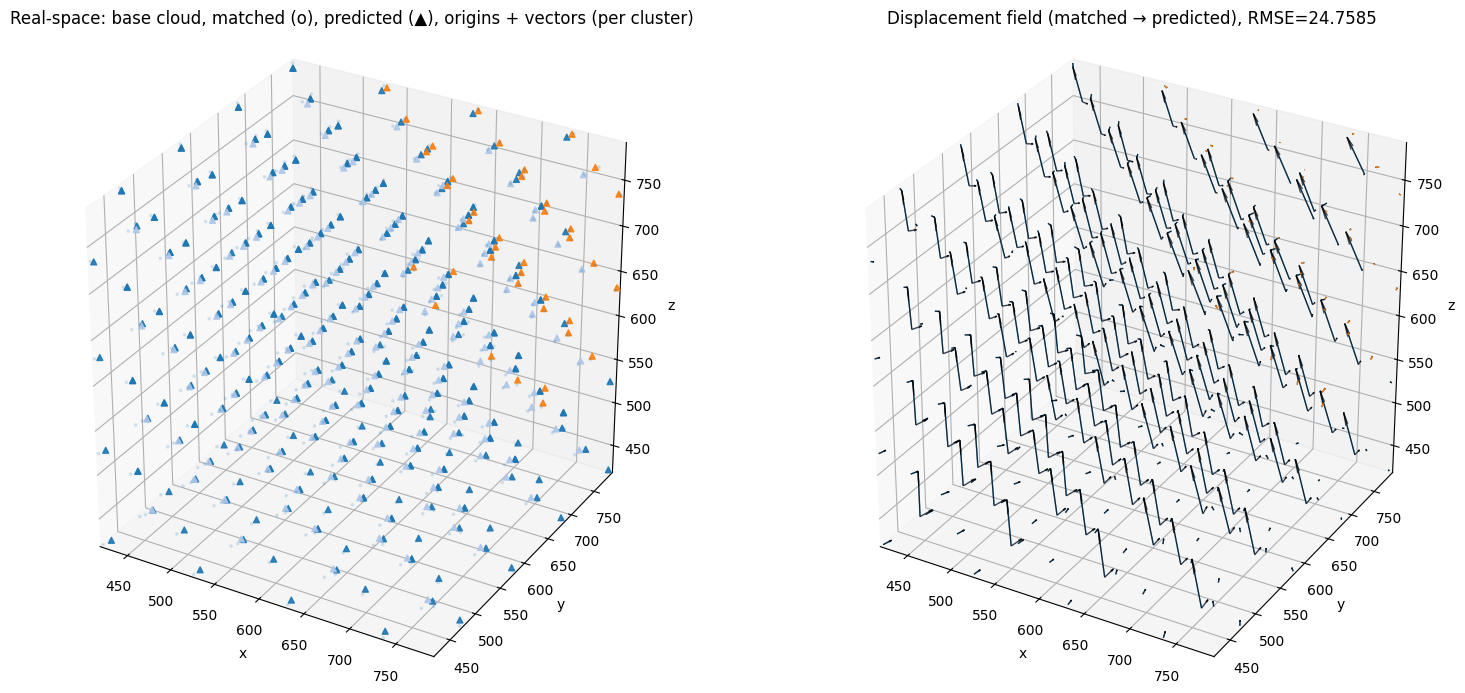

Pairs: 609 | mean disp: 16.9099 | median: 6.6501 | max: 48.9320


In [54]:
# %matplotlib widget

# ---------- pick base cloud (background) ----------
if 'filtered_dataset' in globals():
    _cloud = np.asarray(filtered_dataset, float)
elif 'r_data' in globals():
    _cloud = np.asarray(r_data, float)
else:
    _cloud = None

# ---------- detect particle id column (or use index) ----------
_id_candidates = ("particle_id", "global_id", "pid", "id")
_id_col = next((c for c in _id_candidates if c in df_summary_enriched.columns), None)
_use_index = _id_col is None

# Which particle ids are in scope for this plot?
if _use_index:
    particle_ids = list(df_summary_enriched.index)
else:
    particle_ids = df_summary_enriched[_id_col].tolist()

# ---------- collect per-cluster aggregates: matched, predicted, basis ----------
# We gather per-entry pairs from particle_registry_dict so we know each pair's cluster.
cluster_data = {}  # cid -> dict(matched=[...], predicted=[...], origins=[...], vectors=[...])
def _as_array(x):
    if x is None:
        return None
    a = np.asarray(x, float)
    return a

for pid in particle_ids:
    if pid not in particle_registry_dict:
        continue
    for rec in particle_registry_dict[pid]:
        cid = rec.get("cluster_id")
        if cid is None:
            continue
        mp = rec.get("matched_point", rec.get("r_point", None))
        pp = rec.get("predicted_point", rec.get("lattice_point", None))
        o  = rec.get("origin", None)
        V  = rec.get("V", None)

        if cid not in cluster_data:
            cluster_data[cid] = {"matched": [], "predicted": [], "origins": [], "vectors": []}

        # Only add finite pairs
        if mp is not None and pp is not None:
            mp_a = _as_array(mp)
            pp_a = _as_array(pp)
            if mp_a is not None and pp_a is not None and np.all(np.isfinite(mp_a)) and np.all(np.isfinite(pp_a)):
                cluster_data[cid]["matched"].append(mp_a)
                cluster_data[cid]["predicted"].append(pp_a)

        # Keep one (or dedup) origin/vector per cluster
        if o is not None:
            o_a = _as_array(o)
            if o_a is not None and np.all(np.isfinite(o_a)):
                cluster_data[cid]["origins"].append(o_a)
        if V is not None:
            V_a = _as_array(V)
            if V_a is not None and np.all(np.isfinite(V_a)):
                cluster_data[cid]["vectors"].append(V_a)

# Deduplicate origins/vectors per cluster (preserve first)
for cid, d in cluster_data.items():
    if d["origins"]:
        # unique by tuple
        seen = set()
        uniq = []
        for o in d["origins"]:
            key = tuple(np.round(o, 12))
            if key not in seen:
                seen.add(key)
                uniq.append(o)
        d["origins"] = uniq
    if d["vectors"]:
        seen = set()
        uniq = []
        for V in d["vectors"]:
            key = tuple(np.round(V.reshape(-1), 12))
            if key not in seen:
                seen.add(key)
                uniq.append(V)
        d["vectors"] = uniq

# ---------- build big arrays for displacement field ----------
P_all = []  # matched
Q_all = []  # predicted
C_all = []  # cluster id per pair (for color)
for cid, d in cluster_data.items():
    mL = d["matched"]
    pL = d["predicted"]
    # pair by index (already per-entry); protect against length mismatch
    n = min(len(mL), len(pL))
    if n == 0:
        continue
    P_c = np.vstack(mL[:n]) if n > 0 else np.empty((0,3))
    Q_c = np.vstack(pL[:n]) if n > 0 else np.empty((0,3))
    P_all.append(P_c)
    Q_all.append(Q_c)
    C_all.append(np.full(n, cid, dtype=int))

if P_all:
    P = np.vstack(P_all)
    Q = np.vstack(Q_all)
    C = np.concatenate(C_all)
else:
    P = np.empty((0,3)); Q = np.empty((0,3)); C = np.empty((0,), dtype=int)

V_all = Q - P  # displacement vectors

# ---------- colormap per cluster ----------
cluster_ids = sorted(cluster_data.keys())
cmap = matplotlib.colormaps.get_cmap('tab20')
cid_to_color = {cid: cmap(i % cmap.N) for i, cid in enumerate(cluster_ids)}

# ---------- figure ----------
fig = plt.figure(figsize=(16, 7))
axL = fig.add_subplot(1, 2, 1, projection='3d')
axR = fig.add_subplot(1, 2, 2, projection='3d')

# LEFT: base cloud + per-cluster matched/predicted + cluster origins & vectors
if _cloud is not None and _cloud.size:
    axL.scatter(_cloud[:,0], _cloud[:,1], _cloud[:,2], s=3, alpha=0.12)

for cid in cluster_ids:
    d = cluster_data[cid]
    color = cid_to_color[cid]

    # # matched/predicted
    # if d["matched"]:
    #     Ms = np.vstack(d["matched"])
    #     axL.scatter(Ms[:,0], Ms[:,1], Ms[:,2], s=10, alpha=0.9, marker='o', c=[color])
    if d["predicted"]:
        Ps = np.vstack(d["predicted"])
        axL.scatter(Ps[:,0], Ps[:,1], Ps[:,2], s=18, alpha=0.9, marker='^', c=[color])

    # # origin + primitive vectors (plot the first unique basis we saw for this cluster)
    # if d["origins"]:
    #     o = d["origins"][0]
    #     axL.scatter(o[0], o[1], o[2], s=120, marker='*', zorder=6, c=[color])
    #     # pick a V if present
    #     if d["vectors"]:
    #         V = d["vectors"][0]
    #         V = np.asarray(V, float).reshape(3,3)
    #         for i in range(3):
    #             p_end = o + V[i]
    #             axL.plot([o[0], p_end[0]], [o[1], p_end[1]], [o[2], p_end[2]], linewidth=2.0, alpha=0.95, c=color)

# RIGHT: displacement field (per-cluster color)
if P.size and Q.size:
    # quiver (can be heavy on huge sets; comment out if needed)
    axR.quiver(P[:,0], P[:,1], P[:,2],
               V_all[:,0], V_all[:,1], V_all[:,2],
               length=1.0, normalize=False, linewidth=0.9, alpha=0.7, color='k')  # neutral shafts

    # lines colored by cluster
    segs = np.stack([P, Q], axis=1)
    # split segments by cluster for colored Line3DCollections
    for cid in cluster_ids:
        mask = (C == cid)
        if not np.any(mask):
            continue
        Lc = Line3DCollection(segs[mask], linewidths=1.0, alpha=0.9, colors=[cid_to_color[cid]])
        axR.add_collection3d(Lc)

# ---------- axes, titles, equal aspect, NO legend ----------
for ax in (axL, axR):
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
    ax.set_box_aspect([1,1,1])

# Equal aspect based on everything we plotted
_pts_for_bounds = []
if _cloud is not None and _cloud.size:
    _pts_for_bounds.append(_cloud)
if P.size:
    _pts_for_bounds.append(P)
if Q.size:
    _pts_for_bounds.append(Q)
if _pts_for_bounds:
    bounds = np.vstack(_pts_for_bounds)
else:
    bounds = None

try:
    if bounds is not None:
        set_axes_equal(axL, bounds)
        set_axes_equal(axR, bounds)
except Exception:
    # fallback manual bounds
    if bounds is not None:
        mins = bounds.min(axis=0); maxs = bounds.max(axis=0)
        for ax in (axL, axR):
            ax.set_xlim(mins[0], maxs[0])
            ax.set_ylim(mins[1], maxs[1])
            ax.set_zlim(mins[2], maxs[2])

rmse = float(np.sqrt(np.mean(np.sum((Q - P)**2, axis=1)))) if P.size else np.nan
axL.set_title("Real-space: base cloud, matched (o), predicted (▲), origins + vectors (per cluster)")
axR.set_title(f"Displacement field (matched → predicted), RMSE={rmse:.4f}" if np.isfinite(rmse) else "Displacement field")

# ---------- synchronize views ----------
try:
    copy_view(axL, axR)
    fig.canvas.mpl_connect('motion_notify_event', on_mouse)
    fig.canvas.mpl_connect('button_release_event', on_mouse)
    fig.canvas.mpl_connect('draw_event', on_draw)
except Exception:
    pass

plt.tight_layout()
plt.show()

# quick numeric summary
if P.size:
    mags = np.linalg.norm(V_all, axis=1)
    print(f"Pairs: {len(P)} | mean disp: {mags.mean():.4f} | median: {np.median(mags):.4f} | max: {mags.max():.4f}")
else:
    print("No matched→predicted pairs found for the selected particles.")


### Plot the deviant points

In [55]:
def _as_array(a, shape=None, dtype=float):
    if a is None:
        return None
    arr = np.asarray(a, dtype=dtype)
    if shape is not None:
        arr = np.asarray(arr, dtype=dtype).reshape(shape)
    return arr

def _set_axes_equal_3d(ax):
    # Make 3D plot have equal aspect ratio
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()
    x_range = abs(x_limits[1] - x_limits[0])
    y_range = abs(y_limits[1] - y_limits[0])
    z_range = abs(z_limits[1] - z_limits[0])
    max_range = max([x_range, y_range, z_range])
    x_middle = np.mean(x_limits)
    y_middle = np.mean(y_limits)
    z_middle = np.mean(z_limits)
    ax.set_xlim3d([x_middle - max_range/2, x_middle + max_range/2])
    ax.set_ylim3d([y_middle - max_range/2, y_middle + max_range/2])
    ax.set_zlim3d([z_middle - max_range/2, z_middle + max_range/2])

def _ensure_cluster_basis(particle_registry_dict, cluster_basis=None, build_fn=None):
    if cluster_basis is not None:
        return cluster_basis
    if build_fn is None:
        raise ValueError("cluster_basis is None and build_fn not provided. "
                         "Pass build_cluster_basis or precompute cluster_basis.")
    cluster_records, cluster_basis = build_fn(particle_registry_dict)
    return cluster_basis

def plot_particle_across_clusters(
    particle_id,
    particle_registry_dict,
    cluster_basis=None,
    build_fn=None,              # pass build_cluster_basis if cluster_basis is None
    show_global_rounded=True,
    annotate=True
):
    """
    Visualize where a particle lands according to each cluster:
      • local reconstructed real-space point r_local = oc + Tc @ k_local
      • (optional) global rounded reconstruction r_global = o0 + T0 @ round(T0^{-1}(r_local - o0))
      • cluster origins and their 3 basis vectors
      • matched_point if present
    """
    cb = _ensure_cluster_basis(particle_registry_dict, cluster_basis, build_fn)
    if 0 not in cb:
        raise ValueError("Cluster 0 basis not found — needed as the global frame.")

    o0 = _as_array(cb[0]["origin"], (3,), float)
    T0 = _as_array(cb[0]["T"], (3,3), float)

    recs = particle_registry_dict.get(particle_id, None)
    if recs is None or len(recs) == 0:
        raise ValueError(f"No records found for particle_id {particle_id}")

    # Collect plot items
    local_points = []       # (pos, cid)
    global_points = []      # (pos, cid)
    matched_points = []     # real matched_point if present
    origins = {}            # cid -> origin
    basis_segments = []     # list of line segments for basis vectors [(p0,p1),...]
    labels_local = []
    labels_global = []

    shown_clusters = set()

    for r in recs:
        cid = int(r.get("cluster_id", -1))
        if cid < 0 or cid not in cb:
            continue

        oc = _as_array(cb[cid]["origin"], (3,), float)
        Tc = _as_array(cb[cid]["T"], (3,3), float)
        k_local = _as_array(r.get("ijk", None), (3,), float)
        if k_local is None:
            continue

        # Local reconstructed real-space point from this cluster
        r_local = oc + Tc @ k_local
        local_points.append((r_local, cid))
        labels_local.append(f"c{cid} local (ijk={tuple(map(int, np.rint(k_local)))})")

        # matched_point if available
        mp = _as_array(r.get("matched_point", None), (3,), float)
        if mp is not None and np.all(np.isfinite(mp)):
            matched_points.append(mp)

        # Once per cluster: origins + basis vectors
        if cid not in shown_clusters:
            origins[cid] = oc
            # Columns of Tc are the basis vectors in our mapping r = o + T @ k
            for i in range(3):
                v = Tc[:, i]
                basis_segments.append((oc, oc + v))
            shown_clusters.add(cid)

        # Global rounded reconstruction (optional)
        if show_global_rounded:
            k_glob_float = np.linalg.solve(T0, (r_local - o0))
            k_glob_round = np.rint(k_glob_float).astype(int)
            r_global = o0 + T0 @ k_glob_round
            global_points.append((r_global, cid))
            labels_global.append(f"c{cid} → global rounded {tuple(k_glob_round.tolist())}")

    if not local_points:
        raise ValueError(f"Particle {particle_id}: no usable local points.")

    # ---- Plot ----
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Plot cluster origins
    for cid, oc in origins.items():
        ax.scatter([oc[0]], [oc[1]], [oc[2]], s=40, marker='s', label=f"origin c{cid}")

    # Plot basis vectors as short line segments
    if basis_segments:
        segs = np.array(basis_segments, dtype=float)
        # prepare segments for Line3DCollection: shape (n, 2, 3)
        lc = Line3DCollection(segs, linewidths=1.5, alpha=0.8)
        ax.add_collection3d(lc)

    # Local reconstructed points (one per cluster for this particle)
    for (p, cid), lab in zip(local_points, labels_local):
        ax.scatter([p[0]], [p[1]], [p[2]], s=60, marker='o', label=lab)

    # Global rounded reconstructions in cluster-0 frame
    if show_global_rounded and global_points:
        for (p, cid), lab in zip(global_points, labels_global):
            ax.scatter([p[0]], [p[1]], [p[2]], s=70, marker='x', label=lab)

    # Matched point (measurement), if any
    for mp in matched_points:
        ax.scatter([mp[0]], [mp[1]], [mp[2]], s=90, marker='*', label='matched_point')

    # Also draw global origin & basis from cluster 0 for reference
    ax.scatter([o0[0]], [o0[1]], [o0[2]], s=60, marker='D', label="origin c0 (global)")
    for i in range(3):
        v = T0[:, i]
        ax.plot([o0[0], o0[0] + v[0]],
                [o0[1], o0[1] + v[1]],
                [o0[2], o0[2] + v[2]], linewidth=2.0)

    ax.set_title(f"Particle {particle_id}: per-cluster real-space reconstructions")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    # Fit limits to all points and origins
    all_pts = []
    for p,_ in local_points:
        all_pts.append(p)
    for p,_ in global_points:
        all_pts.append(p)
    for oc in origins.values():
        all_pts.append(oc)
    all_pts.append(o0)

    P = np.vstack(all_pts)
    mins = P.min(axis=0); maxs = P.max(axis=0)
    pad = 0.1 * np.linalg.norm(maxs - mins)
    ax.set_xlim(mins[0]-pad, maxs[0]+pad)
    ax.set_ylim(mins[1]-pad, maxs[1]+pad)
    ax.set_zlim(mins[2]-pad, maxs[2]+pad)
    _set_axes_equal_3d(ax)

    if annotate:
        # annotate cluster IDs near the5ir local points
        for (p,cid) in local_points:
            ax.text(p[0], p[1], p[2], f"c{cid}", fontsize=8)

    ax.legend(loc="best")
    plt.show()


In [56]:
# plot_particle_across_clusters(
#     particle_id=65,
#     particle_registry_dict=particle_registry_clean,   # or particle_registry_dict
#     cluster_basis=cluster_basis,                      # if already built
#     build_fn=build_cluster_basis                      # only needed if cluster_basis is None
# )


## Deduplicate and plot

In [ ]:
# Cell 1: Imports & small helpers

# Small numeric helpers
def as_np(x):
    """Best-effort convert a value/list/tuple to a 1D/2D numpy array of floats."""
    if x is None:
        return None
    if isinstance(x, (list, tuple)):
        x = np.array(x, dtype=float)
    elif not isinstance(x, np.ndarray):
        x = np.array(x, dtype=float)
    return x

def to3(v):
    """Ensure a 3-vector."""
    v = np.array(v, dtype=float).ravel()
    assert v.size == 3, f"Expected 3-vector, got shape {v.shape}"
    return v

def l2(a, b):
    """Euclidean distance between two 3-vectors."""
    a = to3(a); b = to3(b)
    return float(np.linalg.norm(a - b))

def safe_list(x):
    """Ensure list semantics for columns that may contain scalars or lists."""
    if isinstance(x, (list, tuple, np.ndarray)):
        return list(x)
    return [x]

# Output folder for any saved arrays/figs
OUT = Path("local_bonds_v8_outputs")
OUT.mkdir(exist_ok=True)
print("Will save to:", OUT.resolve())


Will save to: C:\Users\erics\Desktop\Lab\Projects\1. Lattice_mapping\Lattice_map\local_bonds_v6_outputs


In [58]:
# Cell 2 : choose by closest float-to-int; predicted_from_int anchored at matched

# Requires:
# - df_summary_enriched with columns:
#   particle_id, matched_points_all, predicted_points_all,
#   global_ijks_float, global_ijks_rounded
# - fcc_vectors_best (3x3) : columns are primitive FCC vectors (real-space)
# - helpers from Cell 1: as_np, to3, safe_list

required = [
    "particle_id",
    "matched_points_all",
    "predicted_points_all",
    "global_ijks_float",
    "global_ijks_rounded",
]
missing = [c for c in required if c not in df_summary_enriched.columns]
if missing:
    raise KeyError(f"df_summary_enriched is missing required columns: {missing}")

B = np.asarray(fcc_vectors_best, dtype=float)  # 3x3, columns are primitive FCC vectors
assert B.shape == (3,3), "fcc_vectors_best must be 3x3 (columns = primitive vectors)"

def index_round_error(ijf, ijr):
    ijf = np.asarray(ijf, float).ravel()
    ijr = np.round(np.asarray(ijr, float).ravel())
    return float(np.linalg.norm(ijf - ijr))

records = []
n_multi = 0

for _, row in df_summary_enriched.iterrows():
    pid   = int(row["particle_id"])
    m_all = [as_np(x) for x in safe_list(row["matched_points_all"])]
    p_all = [as_np(x) for x in safe_list(row["predicted_points_all"])]
    ijf_all = [as_np(x) for x in safe_list(row["global_ijks_float"])]
    ijr_all = [as_np(x) for x in safe_list(row["global_ijks_rounded"])]

    clusters_all = safe_list(row["clusters_present"]) if "clusters_present" in df_summary_enriched.columns else [None]*len(m_all)

    n = min(len(m_all), len(p_all), len(ijf_all), len(ijr_all), len(clusters_all))
    if n == 0:
        continue

    # Select candidate with minimal ||float - rounded_int||
    errs = [index_round_error(ijf_all[i], ijr_all[i]) for i in range(n)]
    j = int(np.argmin(errs))
    if n > 1:
        n_multi += 1

    matched_point       = to3(m_all[j])
    predicted_point     = to3(p_all[j])
    global_ijk_float    = to3(ijf_all[j])
    global_ijk_round    = np.round(to3(ijr_all[j])).astype(int)
    cluster_chosen      = clusters_all[j]
    idx_round_err       = float(errs[j])
    geom_mismatch       = float(np.linalg.norm(matched_point - predicted_point))


    # x(i) = matched_point + B @ (i - global_ijk_round)
    # For the row's own integer index, predicted_from_int == matched_point (by construction).
    predicted_from_int = matched_point + (B @ (global_ijk_round.astype(float) - global_ijk_round.astype(float)))
    # The above simplifies to matched_point, but we keep the formula in comments for clarity.
    # If later you want to map any other index i using this row's origin:
    #   x(i) = matched_point + B @ (i - global_ijk_round)

    records.append({
        "particle_id": pid,
        "matched_point": matched_point,
        "predicted_point": predicted_point,
        "global_ijk_float": global_ijk_float,
        "global_ijk_round": global_ijk_round,
        "index_round_error": idx_round_err,
        "match_error": geom_mismatch,
        "predicted_from_int": predicted_from_int,
        "cluster_chosen": cluster_chosen,
    })

best_assignments = pd.DataFrame.from_records(records)

print(f"Built best_assignments for {len(best_assignments)} particles "
      f"(resolved {n_multi} multi-cluster rows by min index_round_error).")


best_assignments


Built best_assignments for 428 particles (resolved 0 multi-cluster rows by min index_round_error).


,particle_id,matched_point,predicted_point,global_ijk_float,global_ijk_round,index_round_error,match_error,predicted_from_int,cluster_chosen
0,227,"[629.859435521409, 630.0345413412534, 630.1930...","[629.859435521409, 630.0345413412534, 630.1930...","[-0.0, -0.0, -0.0]","[0, 0, 0]",0.000000,0.000000,"[629.859435521409, 630.0345413412534, 630.1930...",0
1,355,"[735.805417702033, 525.2055058982575, 736.0144...","[730.9161909905026, 524.7962076594006, 734.148...","[-3.0, 1.0, 1.0]","[-3, 1, 1]",0.000000,5.249260,"[735.805417702033, 525.2055058982575, 736.0144...",0
2,305,"[683.4099051244447, 471.9674254059117, 735.593...","[678.8346921914116, 474.1207755290029, 733.718...","[-3.0, 1.0, 2.0]","[-3, 1, 2]",0.000000,5.393154,"[683.4099051244447, 471.9674254059117, 735.593...",0
3,352,"[735.6543078516642, 472.9982640282169, 682.919...","[731.5952282987103, 473.4417557709139, 682.738...","[-3.0, 2.0, 1.0]","[-3, 2, 1]",0.000000,4.087246,"[735.6543078516642, 472.9982640282169, 682.919...",0
4,359,"[735.8515906271867, 630.227529102003, 735.7604...","[731.4989134947269, 627.8955748992745, 734.056...","[-2.0, -0.0, 0.0]","[-2, 0, 0]",0.000000,5.223889,"[735.8515906271867, 630.227529102003, 735.7604...",0
...,...,...,...,...,...,...,...,...,...
423,423,"[788.8996801804502, 420.3809183979968, 472.747...","[786.9755988348561, 421.7987475872388, 477.438...","[-2.0, 5.0, -1.0]","[-2, 5, -1]",0.000000,5.265073,"[788.8996801804502, 420.3809183979968, 472.747...",0
424,424,"[788.9736505926213, 786.9421401605762, 735.460...","[786.983388759192, 787.0456743143441, 735.8718...","[-1.0113, -1.0286, -2.0542]","[-1, -1, -2]",0.062316,2.034937,"[788.9736505926213, 786.9421401605762, 735.460...",2
425,425,"[789.0483981369503, 579.384619100006, 420.1617...","[788.8200811515126, 576.6430301784999, 425.844...","[0.0, 4.0, -3.0]","[0, 4, -3]",0.000000,6.314002,"[789.0483981369503, 579.384619100006, 420.1617...",0
426,426,"[789.1314584534863, 420.44221539966304, 788.27...","[783.9734614340869, 426.0026572433353, 787.650...","[-5.0113, 1.9714, 1.9458]","[-5, 2, 2]",0.062316,7.610034,"[789.1314584534863, 420.44221539966304, 788.27...",2


In [59]:
# Cell 3A: Consolidate duplicates by integer index using index_round_error
"""
Multiple particles may map to the same rounded global index.
Keep the one with smallest `index_round_error` (tie-break on `match_error`).
IMPORTANT: keep track of the original row ids  kept so 3B can find removed rows.
"""


need_cols = ["global_ijk_round","index_round_error","match_error","matched_point","predicted_point"]
missing = [c for c in need_cols if c not in best_assignments.columns]
if missing:
    raise KeyError(f"best_assignments is missing required columns: {missing}")

# Build ijk_key and remember original row id
best_assignments = best_assignments.copy()
best_assignments["ijk_key"] = best_assignments["global_ijk_round"].apply(
    lambda v: tuple(np.asarray(v, int))
)
best_assignments["row_id"] = np.arange(len(best_assignments))  # <-- track identity

# Sort by ijk_key, then desired priorities
sorted_for_pick = best_assignments.sort_values(
    by=["ijk_key","index_round_error","match_error"],
    ascending=[True, True, True],
    kind="mergesort"
)

# Pick first per group and *keep the original row ids*
kept = (
    sorted_for_pick
    .drop_duplicates(subset=["ijk_key"], keep="first")
)

kept_row_ids = kept["row_id"].to_numpy()  # <-- we’ll use this in 3B

# Build base clouds from the kept rows
dedup = kept.reset_index(drop=True)

print("Unique ijk indices after dedup (by index_round_error):", len(dedup))

matched_pts_base   = np.vstack(dedup["matched_point"].values)
predicted_pts_base = np.vstack(dedup["predicted_point"].values)
ijk_base           = np.vstack(dedup["global_ijk_round"].values).astype(int)

np.save(OUT/"matched_pts_base.npy", matched_pts_base)
np.save(OUT/"predicted_pts_base.npy", predicted_pts_base)
np.save(OUT/"ijk_base.npy", ijk_base)
print("Saved base arrays ->", OUT)


Unique ijk indices after dedup (by index_round_error): 256
Saved base arrays -> local_bonds_v6_outputs


In [60]:
BEST_ORIGIN_ID

0

In [61]:
df_ranked

,origin_id,particle_id,origin_idx,origin_x,origin_y,origin_z,v11,v12,v13,v21,v22,v23,v31,v32,v33,matched_particles,total_particles,matched_fraction,matched_percent,matched_sublat_A,matched_sublat_B,mse,rmse,d_min,d_med,d_max,match_tol,sublat_A_stats,sublat_B_stats,quarter_shift,origin_A,origin_B,rmse_norm,match_norm,score
0,0,227,152,629.859436,630.034541,630.193095,-50.819739,1.069483,-51.931464,0.679037,-51.354452,-51.409395,-52.081499,-50.675432,-0.429800,280,280,280 / 280,100.000000,108,172,18.827782,4.339099,0.0,4.100894,8.216913,14.533639,"{'matched_particles': 108, 'total_particles': ...","{'matched_particles': 172, 'total_particles': ...","[-25.555550119385604, -25.24010019947373, -25....","[629.859435521409, 630.0345413412534, 630.1930...","[656.5089820643889, 604.0554485384728, 604.708...",0.000000,1.000000,1.000000
1,10,38,6,446.264858,605.369954,604.565264,51.746331,51.014444,-0.714460,-0.163155,51.439349,51.328680,51.187306,-0.832511,51.573572,280,280,280 / 280,100.000000,172,108,24.436792,4.943358,0.0,4.431848,10.111520,14.533639,"{'matched_particles': 172, 'total_particles': ...","{'matched_particles': 108, 'total_particles': ...","[25.692620616960305, 25.4053203997937, 25.5469...","[446.2648575291807, 605.3699535302035, 604.565...","[472.9302327441599, 629.6715398241749, 577.649...",0.137027,1.000000,0.904081
2,11,215,141,604.336199,446.623324,604.471935,51.764447,51.000887,0.135070,0.295066,51.247628,51.519513,51.210539,-0.429078,51.555439,280,280,280 / 280,100.000000,172,108,29.979931,5.475393,0.0,4.930883,9.770967,14.533639,"{'matched_particles': 172, 'total_particles': ...","{'matched_particles': 108, 'total_particles': ...","[25.81751276869418, 25.454859419092145, 25.802...","[604.3361985495949, 446.62332373135337, 604.47...","[578.4087315845994, 472.958633290727, 630.4424...",0.257676,1.000000,0.819627
3,9,223,149,604.679853,604.271786,446.365663,-52.257164,50.493003,0.558682,-0.217522,50.902893,51.860532,51.237160,0.080551,-51.530706,280,280,280 / 280,100.000000,172,108,39.174878,6.258984,0.0,5.972236,12.846823,14.533639,"{'matched_particles': 172, 'total_particles': ...","{'matched_particles': 108, 'total_particles': ...","[-0.3093815680320944, 25.369111931154517, 0.22...","[604.6798525094974, 604.2717856284319, 446.365...","[630.6221914945291, 577.6796426234746, 471.760...",0.435369,1.000000,0.695242
4,2,380,264,761.670345,446.365413,446.384574,-51.227439,0.817913,51.533942,-50.969625,51.784938,1.041230,-0.132726,-51.741691,-51.023979,280,280,280 / 280,100.000000,172,108,51.112543,7.149304,0.0,6.943417,11.537339,14.533639,"{'matched_particles': 172, 'total_particles': ...","{'matched_particles': 108, 'total_particles': ...","[-25.582447616982485, 0.21528988989814657, 0.3...","[761.6703448893082, 446.36541272528194, 446.38...","[735.5126499015103, 472.7546441976173, 473.052...",0.637265,1.000000,0.553914
5,3,46,14,446.783134,445.964815,762.376354,50.930575,51.832965,-0.294806,50.976791,0.511731,-51.785824,-0.214416,50.834936,-51.927160,280,280,280 / 280,100.000000,172,108,54.205475,7.362437,0.0,7.130934,12.463848,14.533639,"{'matched_particles': 172, 'total_particles': ...","{'matched_particles': 108, 'total_particles': ...","[25.42323753730795, 25.794908062595816, -26.00...","[446.78313426860126, 445.9648148871932, 762.37...","[473.62607399814704, 472.82014275313554, 735.3...",0.685597,1.000000,0.520082
6,8,378,262,761.514136,762.058238,761.931259,-51.751651,-51.012102,-0.445866,0.603903,-51.448630,-51.316084,50.696048,0.691667,52.058611,280,280,280 / 280,100.000000,172,108,54.380327,7.374302,0.0,7.282761,11.573001,14.533639,"{'matched_particles': 172, 'total_particles': ...","{'matched_particles': 108, 'total_particles': ...","[-0.11292489354838509, -25.442266034271473, 0....","[761.5141358352755, 762.0582377873689, 761.931...","[734.901889960101, 736.3702421839464, 735.4420...",0.688288,1.000000,0.518198
7,4,45,13,446.719556,762.107767,447.695405,51.998025,-0.133609,50.762724,-0.200467,-52.203377,50.

In [62]:
file_oid = df_ranked.loc[0]['origin_id']
file_pid = df_ranked.loc[0]['particle_id']

In [63]:
# Cell 3B: removed vs kept based on original row ids
"""
Store duplicates removed during deduplication using row identity, not key presence.
"""
# Rows not in kept_row_ids are the removed duplicates
mask_removed = ~best_assignments["row_id"].isin(kept_row_ids)
removed_duplicates = best_assignments.loc[mask_removed].copy()
kept_assignments   = dedup.copy()



print(f"Removed {len(removed_duplicates)} duplicate assignments "
      f"(kept {len(kept_assignments)} unique indices).")

# Optional: report how many ijk_keys had >1 candidates
dupe_counts = best_assignments["ijk_key"].value_counts()
multi_dupes = dupe_counts[dupe_counts > 1]
print(f"Indices with multiple candidate assignments: {len(multi_dupes)}")

# Save
kept_assignments.to_csv(OUT / f"pid{file_pid}_oid{file_oid}_kept_assignments.csv", index=False)
removed_duplicates.to_csv(OUT / f"pid{file_pid}_oid{file_oid}_removed_duplicates.csv", index=False)
print(f"Saved pid{file_pid}_oid{file_oid}_kept_assignments.csv and pid{file_pid}_oid{file_oid}_removed_duplicates.csv to:", OUT)

kept_assignments
# removed_duplicates


Removed 172 duplicate assignments (kept 256 unique indices).
Indices with multiple candidate assignments: 172
Saved pid227_oid0_kept_assignments.csv and pid227_oid0_removed_duplicates.csv to: local_bonds_v6_outputs


,particle_id,matched_point,predicted_point,global_ijk_float,global_ijk_round,index_round_error,match_error,predicted_from_int,cluster_chosen,ijk_key,row_id
0,426,"[789.1314584534863, 420.44221539966304, 788.27...","[783.9734614340869, 426.0026572433353, 787.650...","[-5.0113, 1.9714, 1.9458]","[-5, 2, 2]",0.062316,7.610034,"[789.1314584534863, 420.44221539966304, 788.27...",2,"(-5, 2, 2)",426
1,413,"[788.1454107289887, 525.0488958843931, 787.984...","[784.5561839383113, 529.1020244832092, 787.558...","[-4.0113, 0.9714, 0.9458]","[-4, 1, 1]",0.062316,5.430654,"[788.1454107289887, 525.0488958843931, 787.984...",2,"(-4, 1, 1)",413
2,392,"[762.3464036706685, 446.3586583660454, 761.841...","[729.6544311780706, 473.05129230801344, 785.64...","[-4.0, 1.0, 2.0]","[-4, 1, 2]",0.000000,48.457134,"[762.3464036706685, 446.3586583660454, 761.841...",0,"(-4, 1, 2)",109
3,291,"[682.8146940655173, 420.5173622900251, 787.917...","[677.5729323789795, 422.3758601776157, 785.220...","[-4.0, 1.0, 3.0]","[-4, 1, 3]",0.000000,6.180941,"[682.8146940655173, 420.5173622900251, 787.917...",0,"(-4, 1, 3)",371
4,396,"[787.170629552471, 473.0159009748581, 735.3325...","[782.4149672853692, 472.37227254992445, 734.67...","[-4.0, 2.0, 1.0]","[-4, 2, 1]",0.000000,4.844493,"[787.170629552471, 473.0159009748581, 735.3325...",0,"(-4, 2, 1)",396
...,...,...,...,...,...,...,...,...,...,...,...
251,81,"[473.2342771753679, 682.981302740643, 420.1727...","[478.6619783738639, 684.9879063556091, 422.897...","[4.0, -0.0, -1.0]","[4, 0, -1]",0.000000,6.395945,"[473.2342771753679, 682.981302740643, 420.1727...",0,"(4, 0, -1)",324
252,14,"[420.4582469345536, 630.2434068790233, 420.870...","[426.5804795747729, 634.3124742252113, 422.467...","[4.0, -0.0, 0.0]","[4, 0, 0]",0.000000,7.522439,"[420.4582469345536, 630.2434068790233, 420.870...",0,"(4, 0, 0)",294
253,11,"[420.33031401836206, 788.5060790899395, 473.50...","[426.4841647707897, 788.7662933535719, 473.784...","[5.0, -2.0, -1.0]","[5, -2, -1]",0.000000,6.165723,"[420.33031401836206, 788.5060790899395, 473.50...",0,"(5, -2, -1)",291
254,88,"[473.6825961423686, 787.8004351459584, 420.960...","[479.24470087808834, 788.0872735954829, 422.80...","[5.0, -1.0, -2.0]","[5, -1, -2]",0.000000,5.867006,"[473.6825961423686, 787.8004351459584, 420.960...",0,"(5, -1, -2)",325


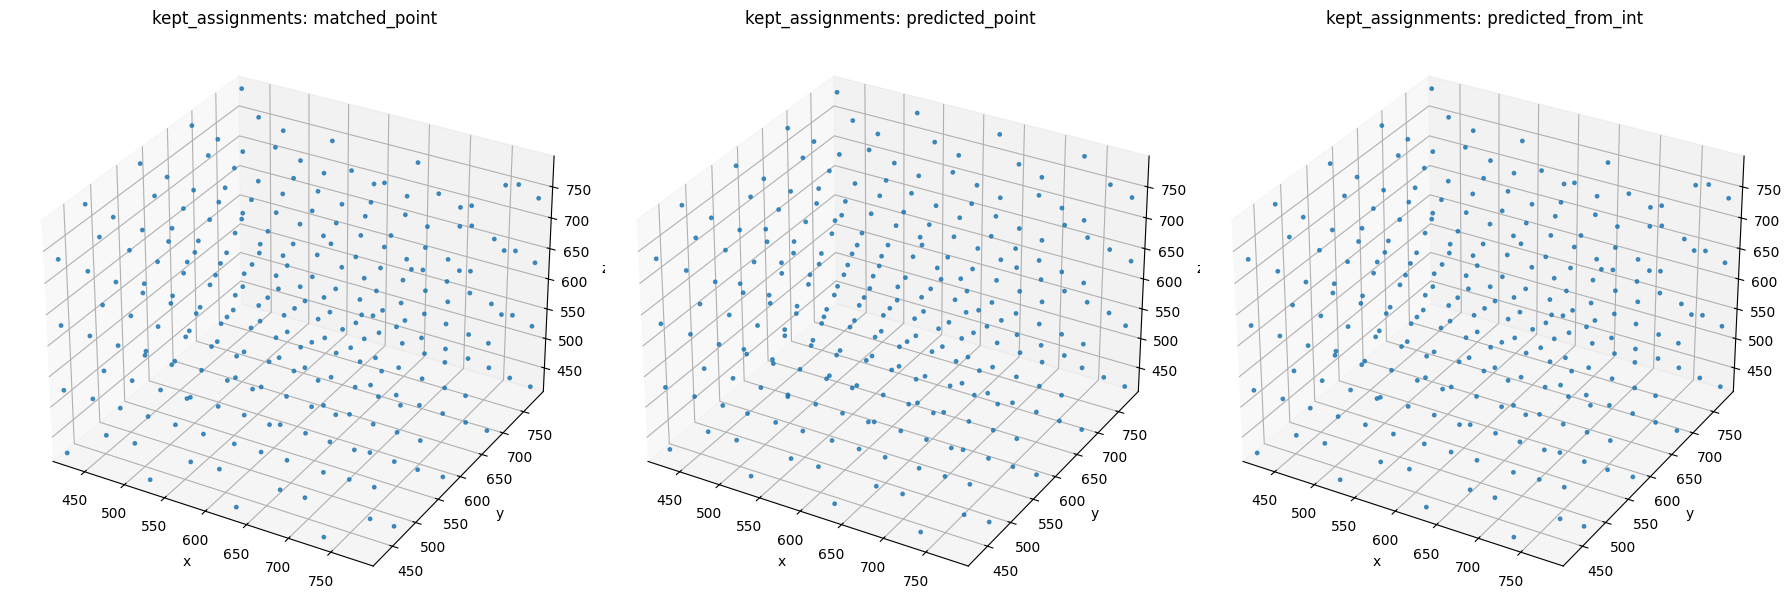

In [64]:
# Cell 4: side-by-side 3D view of kept_assignments clouds
"""
Visualize the kept assignments in three synchronized 3D panels:

LEFT:   matched_point
CENTER: predicted_point
RIGHT:  predicted_from_int

- Uses global equal bounds so all panels share the same scale.
- Camera/view is synchronized across all three axes:
  rotating in one panel updates the others.
Requires:
  - kept_assignments from Cell 3B
  - compute_equal_bounds, apply_bounds, _sync_from_to from helper cell (Cell 2)
"""


if "kept_assignments" not in globals():
    raise RuntimeError("kept_assignments is not defined. Run Cells 2, 3A, and 3B first.")

# ---- Extract point clouds as (N, 3) arrays ----
def _stack_column_points(df, colname):
    if colname not in df.columns:
        raise KeyError(f"Column '{colname}' not found in kept_assignments.")
    vals = df[colname].values
    if len(vals) == 0:
        return np.empty((0, 3), dtype=float)
    return np.vstack(vals).astype(float)

pts_matched = _stack_column_points(kept_assignments, "matched_point")
pts_pred    = _stack_column_points(kept_assignments, "predicted_point")
pts_int     = _stack_column_points(kept_assignments, "predicted_from_int")

# ---- Global equal bounds across all three clouds ----
all_pts = np.concatenate(
    [a for a in (pts_matched, pts_pred, pts_int) if a.size],
    axis=0
) if any(a.size for a in (pts_matched, pts_pred, pts_int)) else np.empty((0, 3))

global_bounds = compute_equal_bounds(all_pts, pad=0.05)

# ---- Figure and axes ----
fig = plt.figure(figsize=(18, 6))
ax1 = fig.add_subplot(1, 3, 1, projection="3d")
ax2 = fig.add_subplot(1, 3, 2, projection="3d")
ax3 = fig.add_subplot(1, 3, 3, projection="3d")

axes = [ax1, ax2, ax3]

# ---- Helper for plotting one cloud ----
def _plot_cloud(ax, pts, title, marker="o"):
    ax.set_title(title)
    if pts.size:
        ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2],
                   s=6, alpha=0.8, marker=marker)
    else:
        ax.text2D(0.5, 0.5, "no points", transform=ax.transAxes,
                  ha="center", va="center")
    apply_bounds(ax, global_bounds)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

# ---- Plot the three clouds ----
_plot_cloud(ax1, pts_matched, "kept_assignments: matched_point")
_plot_cloud(ax2, pts_pred,    "kept_assignments: predicted_point")
_plot_cloud(ax3, pts_int,     "kept_assignments: predicted_from_int")

# ---- Synchronize camera between the three panels ----
def _on_any_three(event):
    if event.inaxes not in axes:
        return
    src = event.inaxes
    for ax in axes:
        if ax is src:
            continue
        _sync_from_to(src, ax)

# Connect once per figure
cid = fig.canvas.mpl_connect("button_release_event", _on_any_three)

plt.tight_layout()
plt.show()


In [ ]:
# Combine sublattices into unified cd_lattice for FCC code compatibility
# This uses the existing assign_ijk_two_sublattices and select_best_origin_by_score_two_sublattices functions

def extract_cd_lattice_from_two_sublattice_assignments(df_matches):
    """
    Extract cd_lattice DataFrame from two-sublattice assignment results.
    
    Parameters
    ----------
    df_matches : pd.DataFrame
        DataFrame from assign_ijk_two_sublattices with sublattice column
        
    Returns
    -------
    pd.DataFrame
        cd_lattice DataFrame with columns:
        - x, y, z: coordinates (from r_data)
        - lattice_id: 0 for sublat_A, 1 for sublat_B
        - ijk_i, ijk_j, ijk_k: lattice indices
        - lattice_x, lattice_y, lattice_z: predicted lattice positions
        - distance: matching distance
    """
    # Filter to only matched points (finite distance)
    df_matched = df_matches[df_matches['distance'].notna()].copy()
    
    # Rename columns to match FCC code format
    df_cd = df_matched.rename(columns={
        'r_x': 'x',
        'r_y': 'y', 
        'r_z': 'z',
        'sublattice': 'lattice_id'
    })
    
    # Select relevant columns
    cols_to_keep = ['x', 'y', 'z', 'lattice_id', 'ijk_i', 'ijk_j', 'ijk_k', 
                    'lattice_x', 'lattice_y', 'lattice_z', 'distance']
    df_cd = df_cd[cols_to_keep].copy()
    
    # Sort by lattice_id then by position for consistency
    df_cd = df_cd.sort_values(['lattice_id', 'x', 'y', 'z']).reset_index(drop=True)
    
    return df_cd


def combine_sublattices_using_existing_functions(points, nn_distance, output_csv=None, **kwargs):
    """
    Combine sublattices using the existing two-sublattice functions.
    
    Parameters
    ----------
    points : (N,3) array-like
        Point coordinates
    nn_distance : float
        Nearest-neighbor distance
    output_csv : str, optional
        If provided, save the combined lattice to this CSV file
    **kwargs
        Additional arguments passed to select_best_origin_by_score_two_sublattices
        
    Returns
    -------
    tuple
        (df_cd, best_row, df_ranked, origin_artifacts)
        df_cd: Combined cd_lattice DataFrame
        best_row: Best origin information
        df_ranked: Ranked origins DataFrame
        origin_artifacts: Dict with all origin artifacts
    """
    # Use the existing two-sublattice function to get best assignments
    best_row, df_summary, df_ranked, origin_artifacts = select_best_origin_by_score_two_sublattices(
        points,
        nn_distance,
        store_best_assignments=False,  # Don't store in global variable
        store_best_origin=False,       # Don't store in global variable
        **kwargs
    )
    
    # Get the best origin ID
    best_id = int(best_row['origin_id'])
    
    # Extract the assignments and df_matches for the best origin
    best_artifact = origin_artifacts[best_id]
    assignments = best_artifact['assignments']
    df_matches = best_artifact['df_matches']
    
    # Extract cd_lattice from the results
    df_cd = extract_cd_lattice_from_two_sublattice_assignments(df_matches)
    
    # Save if requested
    if output_csv:
        output_path = Path(output_csv)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        df_cd.to_csv(output_path, index=False)
        print(f"Saved combined cd_lattice to {output_path}")
    
    # Print summary
    print(f"Combined cd_lattice: {len(df_cd)} total points")
    print(f"  Lattice 0 (sublat_A): {len(df_cd[df_cd['lattice_id'] == 0])} points")
    print(f"  Lattice 1 (sublat_B): {len(df_cd[df_cd['lattice_id'] == 1])} points")
    print(f"  Best origin ID: {best_id}")
    print(f"  Matched percent: {best_row['matched_percent']:.2f}%")
    print(f"  RMSE: {best_row['rmse']:.4f}")
    
    return df_cd, best_row, df_ranked, origin_artifacts


# Example usage: combine sublattices from the best origin
# This uses the existing two-sublattice assignment functions
# Adjust parameters as needed for your data

if 'kept_assignments' in globals():
    # Extract points from kept_assignments
    points = np.vstack(kept_assignments['matched_point'].values)
    
    # Use the NN distance from your analysis
    nn_distance = 45.5  # Adjust based on your data
    
    cd_lattice, best_origin_info, df_ranked, origin_artifacts = combine_sublattices_using_existing_functions(
        points,
        nn_distance,
        output_csv=f"Outputs_v8/cd_lattice_combined.csv",
        n_origins=12,
        tol_frac=0.20,
        crystal_type='CD'
    )
    
    # Display the combined lattice
    display(cd_lattice.head(10))
else:
    print("kept_assignments not found. Run the assignment cells first.")

Saved combined cd_lattice to Outputs\cd_lattice_combined.csv
Combined cd_lattice: 241 total points
  Lattice 0 (sublat_A): 241 points
  Lattice 1 (sublat_B): 0 points
  Best origin ID: 7
  Matched percent: 94.14%
  RMSE: 1.5787


,x,y,z,lattice_id,ijk_i,ijk_j,ijk_k,lattice_x,lattice_y,lattice_z,distance
0,419.307178,788.411304,578.350010,0,5,2,2,418.973021,788.753985,577.625608,0.868245
1,419.336622,525.559141,734.922849,0,4,-2,-2,419.796817,524.181823,736.592920,2.213125
2,419.509614,577.566303,578.090479,0,3,0,0,419.834667,577.726109,578.235774,0.390267
3,419.567202,631.514447,734.593933,0,5,-1,-1,419.365994,629.695761,736.287837,2.493474
4,419.645142,577.908002,472.867439,0,2,1,1,420.003507,578.250987,472.766038,0.506307
5,419.799916,525.612449,525.280357,0,2,0,0,420.134498,525.231579,525.653447,0.629447
6,419.978895,472.610108,577.437141,0,2,-1,-1,420.265489,472.212171,578.540857,1.207758
7,419.987801,788.036280,788.000094,0,7,0,0,418.635339,787.704229,788.565081,1.502872
8,420.099840,525.233908,630.701934,0,3,-1,-1,419.965658,524.706701,631.123184,0.688043
9,420.201076,630.374432,629.840113,0,4,0,0,419.534835,630.220639,630.818101,1.193310
